In [ ]:
# Check GPU
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


In [ ]:
#IMPORT LIBRARIES
import os
import cv2
import numpy as np
from tqdm import tqdm

In [ ]:
#Mount the drive
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))


['Classroom', 'paper (1).docx', 'infosys certificate - Copy.pdf', 'thaya Infosys certificate.pdf', 'Shruthi_dsa_certificate.pdf.pdf', 'DOC-20250907-WA0010..pdf', 'DOC-20250907-WA0012..pdf', 'DOC-20250907-WA0013..pdf', 'DOC-20250907-WA0016. (1).pdf', 'DOC-20250907-WA0016..pdf', 'DOC-20250907-WA0018..pdf', 'DOC-20250907-WA0019..pdf', 'DOC-20250907-WA0020..pdf', 'DOC-20250907-WA0021..pdf', 'DOC-20250907-WA0022..pdf', 'DOC-20250907-WA0023..pdf', 'DOC-20250907-WA0024..pdf', 'fee receipt sem 4.pdf', 'raw_event_data.gsheet', 'Library file data.gsheet', 'Data Analysis Report – Library Borrowing Dataset.gdoc', 'Colab Notebooks', 'Library Data.gsheet', 'Student_academic_feedback.csv.gsheet', 'student_emotion_feedback.csv.gsheet', 'CISCO CERTIFICATE.pdf', 'Aadhaar card proof_compressed.pdf', 'ChatGPT Image Jun 18, 2026, 11_15_28 AM.jpeg', 'Prevention of Sexual harassment training.pdf', 'Information Security and Data Privacy training .pdf', 'Prevention of Insider Trading Training .pdf', 'Enterpris

In [ ]:
#Set Dataset Path
DATASET_PATH = "/content/drive/MyDrive/LIACi_dataset_pretty"

print("Dataset path:", DATASET_PATH)
print("Exists:", os.path.exists(DATASET_PATH))

Dataset path: /content/drive/MyDrive/LIACi_dataset_pretty
Exists: False


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Classroom', 'paper (1).docx', 'infosys certificate - Copy.pdf', 'thaya Infosys certificate.pdf', 'Shruthi_dsa_certificate.pdf.pdf', 'DOC-20250907-WA0010..pdf', 'DOC-20250907-WA0012..pdf', 'DOC-20250907-WA0013..pdf', 'DOC-20250907-WA0016. (1).pdf', 'DOC-20250907-WA0016..pdf', 'DOC-20250907-WA0018..pdf', 'DOC-20250907-WA0019..pdf', 'DOC-20250907-WA0020..pdf', 'DOC-20250907-WA0021..pdf', 'DOC-20250907-WA0022..pdf', 'DOC-20250907-WA0023..pdf', 'DOC-20250907-WA0024..pdf', 'fee receipt sem 4.pdf', 'raw_event_data.gsheet', 'Library file data.gsheet', 'Data Analysis Report – Library Borrowing Dataset.gdoc', 'Colab Notebooks', 'Library Data.gsheet', 'Student_academic_feedback.csv.gsheet', 'student_emotion_feedback.csv.gsheet', 'CISCO CERTIFICATE.pdf', 'Aadhaar card proof_compressed.pdf', 'ChatGPT Image Jun 18, 2026, 11_15_28 AM.jpeg', 'Prevention of Sexual harassment training.pdf', 'Information Security and Data Privacy training .pdf', 'Prevention of Insider Trading Training .pdf', 'Enterpris

In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/LIACI FINAL"))

['PEP_SEG_DATA']


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA"))

['LIACi_dataset_pretty', 'LIACi_checkpoints']


In [ ]:
import os

RGB_DIR = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_dataset_pretty/image_thumbs"
MASK_DIR = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_dataset_pretty/masks/segmentation"

OUTPUT_DIR = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_processed"

print("Images:", os.path.exists(RGB_DIR))
print("Masks:", os.path.exists(MASK_DIR))

Images: True
Masks: True


In [ ]:
#Preprocessing
import cv2
import numpy as np
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split


def create_color_to_label_mapping():

    colors = [
        (0, 0, 0),         # 0 - Void
        (0, 0, 255),       # 1 - Ship hull
        (0, 128, 0),       # 2 - Marine growth
        (0, 255, 255),     # 3 - Anode
        (64, 224, 208),    # 4 - Overboard valve
        (128, 0, 128),     # 5 - Propeller
        (255, 0, 0),       # 6 - Paint peel
        (255, 165, 0),     # 7 - Bilge keel
        (255, 192, 203),   # 8 - Defect
        (255, 255, 0),     # 9 - Corrosion
        (255, 255, 255),   # 10 - Sea chest grating
    ]

    color_to_label = np.zeros((256, 256, 256), dtype=np.uint8)

    for label_id, color in enumerate(colors):
        color_to_label[color[0], color[1], color[2]] = label_id

    return color_to_label



def process_dataset(
    rgb_dir,
    colored_mask_dir,
    output_dir,
    split_ratios=[0.9, 0.07, 0.03],
    target_size=(512, 512)
):


    if not os.path.exists(rgb_dir):
        raise ValueError(f"RGB directory does not exist: {rgb_dir}")

    if not os.path.exists(colored_mask_dir):
        raise ValueError(
            f"Mask directory does not exist: {colored_mask_dir}"
        )


    for split in ['train', 'val', 'test']:

        os.makedirs(
            os.path.join(output_dir, 'leftImg8bit', split),
            exist_ok=True
        )

        os.makedirs(
            os.path.join(output_dir, 'gtFine', split),
            exist_ok=True
        )


    color_to_label = create_color_to_label_mapping()


    image_files = sorted([
        f for f in os.listdir(rgb_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    all_mask_files = sorted([
        f for f in os.listdir(colored_mask_dir)
        if f.lower().endswith(
            ('.png', '.bmp', '.jpg', '.jpeg')
        )
    ])

    print("Images found:", len(image_files))
    print("Masks found:", len(all_mask_files))


    mask_dict = {
        os.path.splitext(f)[0]: f
        for f in all_mask_files
    }

    matched_pairs = []

    for img_file in image_files:

        image_id = os.path.splitext(img_file)[0]

        if image_id in mask_dict:
            matched_pairs.append(
                (img_file, mask_dict[image_id])
            )

    print("Matched image-mask pairs:", len(matched_pairs))

    if len(matched_pairs) == 0:
        raise ValueError(
            "No matching image-mask pairs were found."
        )

    print(
        f"\nProcessing {len(matched_pairs)} "
        f"matched image-mask pairs."
    )


    train_ratio, val_ratio, test_ratio = split_ratios

    train_pairs, temp_pairs = train_test_split(
        matched_pairs,
        train_size=train_ratio,
        random_state=42
    )

    val_ratio_adjusted = (
        val_ratio / (val_ratio + test_ratio)
    )

    val_pairs, test_pairs = train_test_split(
        temp_pairs,
        train_size=val_ratio_adjusted,
        random_state=42
    )

    split_mapping = {
        'train': train_pairs,
        'val': val_pairs,
        'test': test_pairs
    }

    print("\nDataset split:")
    print("Train:", len(train_pairs))
    print("Validation:", len(val_pairs))
    print("Test:", len(test_pairs))


    successful = 0
    failed = 0

    for split, file_pairs in split_mapping.items():

        print(
            f"\nProcessing {split} split "
            f"({len(file_pairs)} images)..."
        )

        for img_file, mask_file in tqdm(
            file_pairs,
            desc=split
        ):

            try:


                rgb_path = os.path.join(
                    rgb_dir,
                    img_file
                )

                rgb_img = cv2.imread(rgb_path)

                if rgb_img is None:
                    print(
                        f"\nCould not read image: {rgb_path}"
                    )
                    failed += 1
                    continue


                rgb_img = cv2.resize(
                    rgb_img,
                    (target_size[1], target_size[0]),
                    interpolation=cv2.INTER_LINEAR
                )


                mask_path = os.path.join(
                    colored_mask_dir,
                    mask_file
                )

                colored_mask = cv2.imread(mask_path)

                if colored_mask is None:
                    print(
                        f"\nCould not read mask: {mask_path}"
                    )
                    failed += 1
                    continue


                colored_mask = cv2.resize(
                    colored_mask,
                    (target_size[1], target_size[0]),
                    interpolation=cv2.INTER_NEAREST
                )


                colored_mask = cv2.cvtColor(
                    colored_mask,
                    cv2.COLOR_BGR2RGB
                )


                label_mask = color_to_label[
                    colored_mask[:, :, 0],
                    colored_mask[:, :, 1],
                    colored_mask[:, :, 2]
                ]


                rgb_save_name = (
                    os.path.splitext(img_file)[0] + '.png'
                )

                cv2.imwrite(
                    os.path.join(
                        output_dir,
                        'leftImg8bit',
                        split,
                        rgb_save_name
                    ),
                    rgb_img
                )


                # Save label mask

                label_save_name = (
                    f"{os.path.splitext(img_file)[0]}"
                    f"_gtFine_labelTrainIds.png"
                )

                cv2.imwrite(
                    os.path.join(
                        output_dir,
                        'gtFine',
                        split,
                        label_save_name
                    ),
                    label_mask
                )

                successful += 1

            except Exception as e:

                print(
                    f"\nError processing "
                    f"{img_file} with mask {mask_file}: {str(e)}"
                )

                failed += 1
                continue

    # PROCESSING SUMMARY



    print("PROCESSING COMPLETE")


    print("Successfully processed:", successful)
    print("Failed:", failed)


    # VERIFY OUTPUT


    print("\nOutput verification:")

    for split in ['train', 'val', 'test']:

        image_output_dir = os.path.join(
            output_dir,
            'leftImg8bit',
            split
        )

        label_output_dir = os.path.join(
            output_dir,
            'gtFine',
            split
        )

        n_images = len(
            os.listdir(image_output_dir)
        )

        n_labels = len(
            os.listdir(label_output_dir)
        )

        print(f"\n{split}:")
        print("Images:", n_images)
        print("Labels:", n_labels)



RGB_DIR = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_dataset_pretty/image_thumbs"

MASK_DIR = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_dataset_pretty/masks/segmentation"

OUTPUT_DIR = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_processed"


process_dataset(
    RGB_DIR,
    MASK_DIR,
    OUTPUT_DIR,
    split_ratios=[0.9, 0.07, 0.03],
    target_size=(512, 512)
)


Images found: 1893
Masks found: 1893
Matched image-mask pairs: 1893

Processing 1893 matched image-mask pairs.

Dataset split:
Train: 1703
Validation: 133
Test: 57

Processing train split (1703 images)...


train: 100%|██████████| 1703/1703 [10:56<00:00,  2.59it/s]



Processing val split (133 images)...


val: 100%|██████████| 133/133 [00:48<00:00,  2.75it/s]



Processing test split (57 images)...


test: 100%|██████████| 57/57 [00:21<00:00,  2.61it/s]

PROCESSING COMPLETE
Successfully processed: 1893
Failed: 0

Output verification:

train:
Images: 1703
Labels: 1703

val:
Images: 133
Labels: 133

test:
Images: 57
Labels: 57


In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

PROCESSED_DIR = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_processed"


class LIACiDataset(Dataset):

    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask


train_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/train",
    PROCESSED_DIR + "/gtFine/train"
)

val_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/val",
    PROCESSED_DIR + "/gtFine/val"
)

test_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/test",
    PROCESSED_DIR + "/gtFine/test"
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 1703
Validation: 133
Test: 57


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 213
Validation batches: 17
Test batches: 8


In [ ]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.8 MB/s eta 0:00:00


In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="mobilenet_v2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=11
)

print("U-Net + MobileNetV2 ready!")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.2MB            

model.safetensors: downloading bytes:           |  0.00B            

U-Net + MobileNetV2 ready!


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

loss_fn = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Device:", device)
print("Loss: CrossEntropyLoss")
print("Optimizer: Adam")

Device: cuda
Loss: CrossEntropyLoss
Optimizer: Adam


In [ ]:
import os
import torch

checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/unet_mobilenetv2_best.pth"

os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

epochs = 30
best_val_loss = float("inf")

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = loss_fn(outputs, masks)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            checkpoint_path
        )

        print("Best model saved!")

Epoch [1/30] Train Loss: 1.6111 Val Loss: 1.0842
Best model saved!
Epoch [2/30] Train Loss: 1.0954 Val Loss: 0.8683
Best model saved!
Epoch [3/30] Train Loss: 0.9374 Val Loss: 0.7638
Best model saved!
Epoch [4/30] Train Loss: 0.8429 Val Loss: 0.7390
Best model saved!
Epoch [5/30] Train Loss: 0.7787 Val Loss: 0.6725
Best model saved!
Epoch [6/30] Train Loss: 0.7213 Val Loss: 0.6395
Best model saved!
Epoch [7/30] Train Loss: 0.6704 Val Loss: 0.6242
Best model saved!
Epoch [8/30] Train Loss: 0.6168 Val Loss: 0.6180
Best model saved!
Epoch [9/30] Train Loss: 0.5695 Val Loss: 0.6205
Epoch [10/30] Train Loss: 0.5356 Val Loss: 0.6132
Best model saved!
Epoch [11/30] Train Loss: 0.4928 Val Loss: 0.5932
Best model saved!
Epoch [12/30] Train Loss: 0.4499 Val Loss: 0.5983
Epoch [13/30] Train Loss: 0.4327 Val Loss: 0.5758
Best model saved!
Epoch [14/30] Train Loss: 0.3996 Val Loss: 0.5973
Epoch [15/30] Train Loss: 0.3694 Val Loss: 0.5870
Epoch [16/30] Train Loss: 0.3442 Val Loss: 0.6067
Epoch [17/3

In [ ]:
import torch

# Load the best model from the first 30 epochs
model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

# Lower learning rate for fine-tuning
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.00001
)

# Best validation loss so far
best_val_loss = 0.5758

start_epoch = 30
total_epochs = 100

for epoch in range(start_epoch, total_epochs):

    model.train()
    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, masks)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = loss_fn(outputs, masks)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)

    print(
        f"Epoch [{epoch+1}/{total_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            checkpoint_path
        )

        print("Best model saved!")

Epoch [31/100] Train Loss: 0.3515 Val Loss: 0.5582
Best model saved!
Epoch [32/100] Train Loss: 0.3323 Val Loss: 0.5677
Epoch [33/100] Train Loss: 0.3243 Val Loss: 0.5544
Best model saved!
Epoch [34/100] Train Loss: 0.3099 Val Loss: 0.5652
Epoch [35/100] Train Loss: 0.3097 Val Loss: 0.5602
Epoch [36/100] Train Loss: 0.3006 Val Loss: 0.5629
Epoch [37/100] Train Loss: 0.2867 Val Loss: 0.5773
Epoch [38/100] Train Loss: 0.2840 Val Loss: 0.5759
Epoch [39/100] Train Loss: 0.2830 Val Loss: 0.5816
Epoch [40/100] Train Loss: 0.2727 Val Loss: 0.5873
Epoch [41/100] Train Loss: 0.2765 Val Loss: 0.5717
Epoch [42/100] Train Loss: 0.2753 Val Loss: 0.5851
Epoch [43/100] Train Loss: 0.2619 Val Loss: 0.5824
Epoch [44/100] Train Loss: 0.2575 Val Loss: 0.5869
Epoch [45/100] Train Loss: 0.2580 Val Loss: 0.5930
Epoch [46/100] Train Loss: 0.2552 Val Loss: 0.5922
Epoch [47/100] Train Loss: 0.2473 Val Loss: 0.5862
Epoch [48/100] Train Loss: 0.2428 Val Loss: 0.6049
Epoch [49/100] Train Loss: 0.2431 Val Loss: 0.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.1 MB/s eta 0:00:00


In [ ]:
import torch
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="mobilenet_v2",
    encoder_weights=None,
    in_channels=3,
    classes=11
)

checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/unet_mobilenetv2_best.pth"

model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

model = model.to(device)
model.eval()

print("Best U-Net + MobileNetV2 model loaded!")
print("Device:", device)

Best U-Net + MobileNetV2 model loaded!
Device: cuda


In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

PROCESSED_DIR = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_processed"

class LIACiDataset(Dataset):

    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask


test_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/test",
    PROCESSED_DIR + "/gtFine/test"
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print("Test images:", len(test_dataset))
print("Test batches:", len(test_loader))

Test images: 57
Test batches: 8


In [ ]:
import torch

loss_fn = torch.nn.CrossEntropyLoss()

print("Loss function ready!")

Loss function ready!


In [ ]:
model.eval()

test_loss = 0
correct = 0
total = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = loss_fn(outputs, masks)
        test_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == masks).sum().item()
        total += masks.numel()

test_loss = test_loss / len(test_loader)
pixel_accuracy = correct / total

print("Test Loss:", round(test_loss, 4))
print("Pixel Accuracy:", round(pixel_accuracy * 100, 2), "%")

Test Loss: 0.4961
Pixel Accuracy: 83.19 %


In [ ]:
import numpy as np

num_classes = 11

intersection = np.zeros(num_classes)
union = np.zeros(num_classes)
dice_sum = np.zeros(num_classes)

model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        for class_id in range(num_classes):

            pred_class = predictions == class_id
            true_class = masks == class_id

            inter = (pred_class & true_class).sum().item()
            total = (pred_class | true_class).sum().item()

            intersection[class_id] += inter
            union[class_id] += total

            dice_sum[class_id] += 2 * inter / (
                pred_class.sum().item() + true_class.sum().item() + 1e-8
            )

iou = intersection / (union + 1e-8)

mean_iou = iou.mean()
dice = dice_sum / len(test_loader)

class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]

print("Mean IoU:", round(mean_iou * 100, 2), "%")
print("Mean Dice:", round(dice.mean() * 100, 2), "%")
print()

for i in range(num_classes):
    print(class_names[i], "IoU:", round(iou[i] * 100, 2), "%")

Mean IoU: 40.15 %
Mean Dice: 35.77 %

Void IoU: 76.73 %
Ship Hull IoU: 79.29 %
Marine Growth IoU: 53.66 %
Anode IoU: 0.09 %
Overboard Valve IoU: 37.6 %
Propeller IoU: 69.88 %
Paint Peel IoU: 18.15 %
Bilge Keel IoU: 35.17 %
Defect IoU: 0.0 %
Corrosion IoU: 0.0 %
Sea Chest Grating IoU: 71.08 %


In [ ]:
import os
import cv2
import torch
import numpy as np
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# Paths and settings
# -----------------------------

PROCESSED_DIR = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_processed"

checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/unet_mobilenetv2_improved_best.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 8
epochs = 50
learning_rate = 0.0001
num_classes = 11


# -----------------------------
# Dataset
# -----------------------------

class LIACiDataset(Dataset):

    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1) / 255.0

        mask = torch.tensor(
            mask,
            dtype=torch.long
        )

        return image, mask


train_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/train",
    PROCESSED_DIR + "/gtFine/train"
)

val_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/val",
    PROCESSED_DIR + "/gtFine/val"
)

test_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/test",
    PROCESSED_DIR + "/gtFine/test"
)


train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


# -----------------------------
# Model
# -----------------------------

model = smp.Unet(
    encoder_name="mobilenet_v2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=num_classes
)

model = model.to(device)


# -----------------------------
# Focal + Weighted Dice Loss
# -----------------------------

class FocalLoss(torch.nn.Module):

    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma

    def forward(self, outputs, targets):

        ce_loss = torch.nn.functional.cross_entropy(
            outputs,
            targets,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)

        loss = ((1 - pt) ** self.gamma) * ce_loss

        return loss.mean()


class WeightedDiceLoss(torch.nn.Module):

    def __init__(self, weights):
        super().__init__()
        self.weights = weights

    def forward(self, outputs, targets):

        probabilities = torch.softmax(outputs, dim=1)

        total_loss = 0

        for class_id in range(num_classes):

            prediction = probabilities[:, class_id]
            target = (targets == class_id).float()

            intersection = (prediction * target).sum()
            denominator = prediction.sum() + target.sum()

            dice = (2 * intersection + 1e-6) / (denominator + 1e-6)

            total_loss += self.weights[class_id] * (1 - dice)

        return total_loss / self.weights.sum()


class CombinedLoss(torch.nn.Module):

    def __init__(self, weights):
        super().__init__()

        self.focal = FocalLoss()
        self.dice = WeightedDiceLoss(weights)

    def forward(self, outputs, targets):

        focal_loss = self.focal(outputs, targets)
        dice_loss = self.dice(outputs, targets)

        return focal_loss + dice_loss


class_weights = torch.tensor([
    0.5,
    1.0,
    1.5,
    3.0,
    2.0,
    1.5,
    2.5,
    2.0,
    3.0,
    3.0,
    1.5
], dtype=torch.float32).to(device)

loss_fn = CombinedLoss(class_weights)


# -----------------------------
# Optimizer
# -----------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)


# -----------------------------
# Training
# -----------------------------

best_val_loss = float("inf")

for epoch in range(epochs):

    model.train()

    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, masks)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)


    model.eval()

    val_loss = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = loss_fn(outputs, masks)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            checkpoint_path
        )

        print("Best improved model saved!")


# -----------------------------
# Load best model
# -----------------------------

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

model.eval()


# -----------------------------
# Test model
# -----------------------------

correct = 0
total = 0

intersection = np.zeros(num_classes)
union = np.zeros(num_classes)
dice_intersection = np.zeros(num_classes)
dice_total = np.zeros(num_classes)

test_loss = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = loss_fn(outputs, masks)

        test_loss += loss.item()

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == masks
        ).sum().item()

        total += masks.numel()

        for class_id in range(num_classes):

            pred_class = predictions == class_id
            true_class = masks == class_id

            inter = (
                pred_class & true_class
            ).sum().item()

            union_value = (
                pred_class | true_class
            ).sum().item()

            intersection[class_id] += inter
            union[class_id] += union_value

            dice_intersection[class_id] += 2 * inter
            dice_total[class_id] += (
                pred_class.sum().item()
                + true_class.sum().item()
            )


test_loss = test_loss / len(test_loader)

pixel_accuracy = correct / total

iou = intersection / (union + 1e-8)

dice = dice_intersection / (
    dice_total + 1e-8
)

mean_iou = iou.mean()
mean_dice = dice.mean()


# -----------------------------
# Results
# -----------------------------

class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]

print("\n-----------------------------")
print("IMPROVED MODEL RESULTS")
print("-----------------------------")

print("Test Loss:", round(test_loss, 4))
print("Pixel Accuracy:", round(pixel_accuracy * 100, 2), "%")
print("Mean IoU:", round(mean_iou * 100, 2), "%")
print("Mean Dice:", round(mean_dice * 100, 2), "%")

print("\nPer-class results:")

for i in range(num_classes):

    print(
        class_names[i],
        "- IoU:",
        round(iou[i] * 100, 2),
        "%",
        "| Dice:",
        round(dice[i] * 100, 2),
        "%"
    )

Train: 1703
Validation: 133
Test: 57


KeyboardInterrupt: 

In [ ]:
import os

print(os.path.exists(
    "/root/.cache/huggingface/hub"
))

True


In [ ]:
import os

cache_path = "/root/.cache/huggingface/hub"

for root, dirs, files in os.walk(cache_path):
    for file in files:
        if "safetensors" in file:
            print(os.path.join(root, file))

/root/.cache/huggingface/hub/models--smp-hub--mobilenet_v2.imagenet/snapshots/e67aa804e17f7b404b629127eabbd224c4e0690b/model.safetensors


In [ ]:
from safetensors.torch import load_file

weights = load_file(weights_path)

print("Cached MobileNetV2 weights loaded!")
print("Number of weights:", len(weights))

Cached MobileNetV2 weights loaded!
Number of weights: 314


In [ ]:
import torch
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.Unet(
    encoder_name="mobilenet_v2",
    encoder_weights=None,
    in_channels=3,
    classes=11
)

model.encoder.load_state_dict(weights, strict=False)

model = model.to(device)

print("Improved U-Net + MobileNetV2 model ready!")
print("Device:", device)


Improved U-Net + MobileNetV2 model ready!
Device: cuda


In [ ]:
import os

checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/unet_mobilenetv2_improved_best.pth"

os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

print("Training setup ready!")
print("Checkpoint:", checkpoint_path)

Training setup ready!
Checkpoint: /content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/unet_mobilenetv2_improved_best.pth


In [ ]:
import torch

epochs = 50
learning_rate = 0.0001

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

best_val_loss = float("inf")

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, masks)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = loss_fn(outputs, masks)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            checkpoint_path
        )

        print("Best improved model saved!")

Epoch [1/50] Train Loss: 1.9972 Val Loss: 1.5131
Best improved model saved!
Epoch [2/50] Train Loss: 1.5395 Val Loss: 1.3832
Best improved model saved!
Epoch [3/50] Train Loss: 1.4223 Val Loss: 1.3148
Best improved model saved!
Epoch [4/50] Train Loss: 1.3473 Val Loss: 1.2717
Best improved model saved!
Epoch [5/50] Train Loss: 1.2729 Val Loss: 1.2196
Best improved model saved!
Epoch [6/50] Train Loss: 1.1879 Val Loss: 1.1722
Best improved model saved!
Epoch [7/50] Train Loss: 1.1159 Val Loss: 1.1508
Best improved model saved!
Epoch [8/50] Train Loss: 1.0681 Val Loss: 1.1446
Best improved model saved!
Epoch [9/50] Train Loss: 1.0077 Val Loss: 1.1175
Best improved model saved!
Epoch [10/50] Train Loss: 0.9617 Val Loss: 1.1032
Best improved model saved!
Epoch [11/50] Train Loss: 0.9339 Val Loss: 1.0842
Best improved model saved!
Epoch [12/50] Train Loss: 0.9023 Val Loss: 1.0946
Epoch [13/50] Train Loss: 0.8640 Val Loss: 1.1174
Epoch [14/50] Train Loss: 0.8421 Val Loss: 1.0559
Best improve

In [ ]:
import torch
import numpy as np

# Load best improved model
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

num_classes = 11

class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]

intersection = np.zeros(num_classes)
union = np.zeros(num_classes)
correct_pixels = 0
total_pixels = 0
test_loss = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        loss = loss_fn(outputs, masks)
        test_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        correct_pixels += (predictions == masks).sum().item()
        total_pixels += masks.numel()

        for class_id in range(num_classes):

            pred_class = predictions == class_id
            true_class = masks == class_id

            intersection[class_id] += (pred_class & true_class).sum().item()
            union[class_id] += (pred_class | true_class).sum().item()

test_loss = test_loss / len(test_loader)
pixel_accuracy = correct_pixels / total_pixels

iou = intersection / (union + 1e-8)
mean_iou = np.mean(iou)

dice = (2 * intersection) / (2 * intersection + union - intersection + 1e-8)
mean_dice = np.mean(dice)

print("Improved Model Results")
print("----------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Pixel Accuracy: {pixel_accuracy * 100:.2f}%")
print(f"Mean IoU: {mean_iou * 100:.2f}%")
print(f"Mean Dice: {mean_dice * 100:.2f}%")

print("\nPer-Class Results")
print("-----------------")

for i in range(num_classes):
    print(
        f"{class_names[i]:20s} "
        f"IoU: {iou[i] * 100:.2f}%   "
        f"Dice: {dice[i] * 100:.2f}%"
    )

Improved Model Results
----------------------
Test Loss: 1.0182
Pixel Accuracy: 82.41%
Mean IoU: 46.29%
Mean Dice: 57.51%

Per-Class Results
-----------------
Void                 IoU: 76.24%   Dice: 86.52%
Ship Hull            IoU: 77.15%   Dice: 87.10%
Marine Growth        IoU: 50.13%   Dice: 66.78%
Anode                IoU: 55.37%   Dice: 71.28%
Overboard Valve      IoU: 56.59%   Dice: 72.28%
Propeller            IoU: 73.91%   Dice: 85.00%
Paint Peel           IoU: 23.89%   Dice: 38.57%
Bilge Keel           IoU: 27.77%   Dice: 43.47%
Defect               IoU: 0.00%   Dice: 0.00%
Corrosion            IoU: 0.40%   Dice: 0.80%
Sea Chest Grating    IoU: 67.78%   Dice: 80.79%


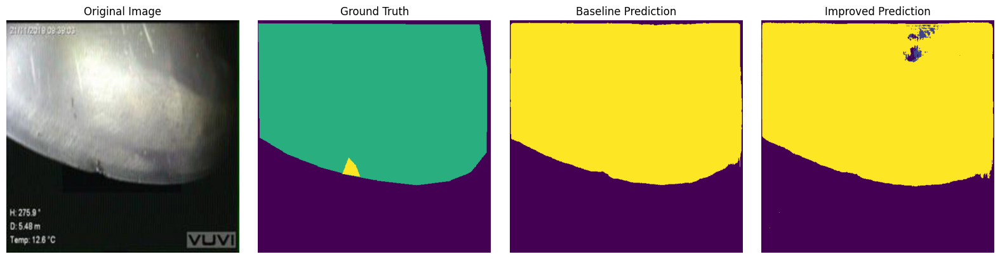

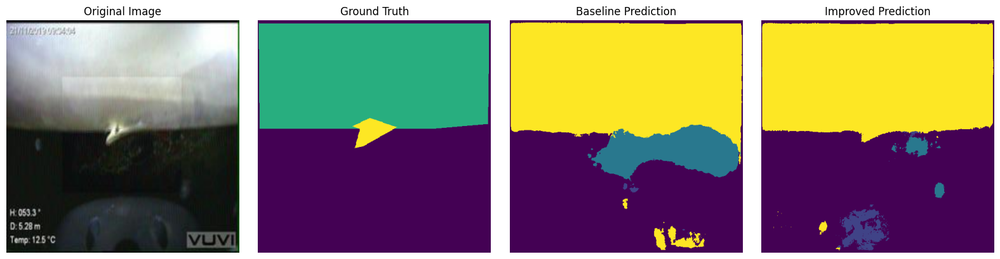

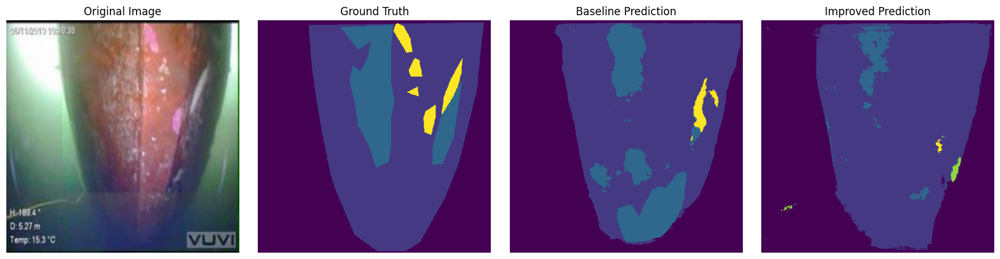

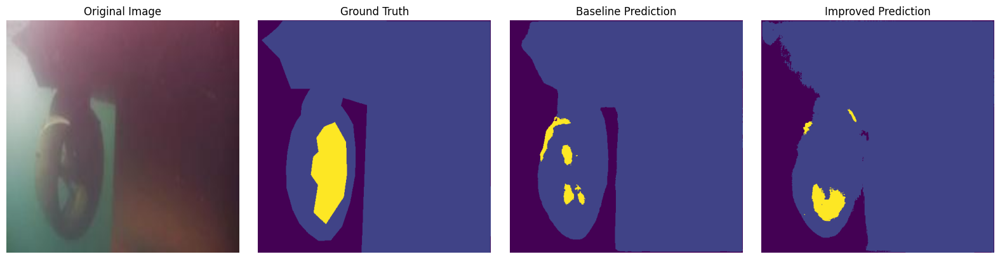

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Load baseline model
baseline_model = smp.Unet(
    encoder_name="mobilenet_v2",
    encoder_weights=None,
    in_channels=3,
    classes=11
)

baseline_model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/unet_mobilenetv2_best.pth",
        map_location=device
    )
)

baseline_model = baseline_model.to(device)
baseline_model.eval()

# Load improved model
improved_model = smp.Unet(
    encoder_name="mobilenet_v2",
    encoder_weights=None,
    in_channels=3,
    classes=11
)

improved_model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

improved_model = improved_model.to(device)
improved_model.eval()

# Take one batch from test set
images, masks = next(iter(test_loader))

images_gpu = images.to(device)

with torch.no_grad():
    baseline_output = baseline_model(images_gpu)
    improved_output = improved_model(images_gpu)

baseline_pred = torch.argmax(baseline_output, dim=1).cpu().numpy()
improved_pred = torch.argmax(improved_output, dim=1).cpu().numpy()

images = images.numpy()
masks = masks.numpy()

# Show 4 test images
for i in range(4):

    image = images[i].transpose(1, 2, 0)

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(masks[i])
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(baseline_pred[i])
    plt.title("Baseline Prediction")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(improved_pred[i])
    plt.title("Improved Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


In [ ]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.6 MB/s eta 0:00:00


In [ ]:
import segmentation_models_pytorch as smp

print("SMP ready!")

SMP ready!


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

PROCESSED_DIR = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_processed"

class LIACiDataset(Dataset):

    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1) / 255.0

        mask = torch.tensor(
            mask,
            dtype=torch.long
        )

        return image, mask


train_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/train",
    PROCESSED_DIR + "/gtFine/train"
)

val_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/val",
    PROCESSED_DIR + "/gtFine/val"
)

test_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/test",
    PROCESSED_DIR + "/gtFine/test"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 1703
Validation: 133
Test: 57


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights


class PyramidPooling(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.pool1 = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool2 = nn.Sequential(
            nn.AdaptiveAvgPool2d(2),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool3 = nn.Sequential(
            nn.AdaptiveAvgPool2d(3),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool6 = nn.Sequential(
            nn.AdaptiveAvgPool2d(6),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels + 4 * out_channels,
                out_channels,
                1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )

    def forward(self, x):

        h, w = x.shape[2], x.shape[3]

        p1 = F.interpolate(
            self.pool1(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p2 = F.interpolate(
            self.pool2(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p3 = F.interpolate(
            self.pool3(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p6 = F.interpolate(
            self.pool6(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat(
            [x, p1, p2, p3, p6],
            dim=1
        )

        return self.conv(x)


class PSPNetResNet50(nn.Module):

    def __init__(self, num_classes=11):
        super().__init__()

        # ResNet50 with dilated convolutions
        backbone = resnet50(
            weights=ResNet50_Weights.DEFAULT,
            replace_stride_with_dilation=[
                False,
                True,
                True
            ]
        )

        self.layer0 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool
        )

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        # Pyramid Pooling Module
        self.psp = PyramidPooling(
            in_channels=2048,
            out_channels=512
        )

        # Main segmentation decoder
        self.decoder = nn.Sequential(
            nn.Conv2d(
                512,
                256,
                3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Dropout2d(0.1),

            nn.Conv2d(
                256,
                256,
                3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Dropout2d(0.1),

            nn.Conv2d(
                256,
                num_classes,
                1
            )
        )

        # Auxiliary segmentation head
        self.auxiliary = nn.Sequential(
            nn.Conv2d(
                1024,
                256,
                3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Dropout2d(0.1),

            nn.Conv2d(
                256,
                num_classes,
                1
            )
        )

    def forward(self, x):

        input_h, input_w = x.shape[2], x.shape[3]

        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)

        # Intermediate feature for auxiliary supervision
        x_aux = self.layer3(x)

        # Main PSPNet pathway
        x = self.layer4(x_aux)

        x = self.psp(x)

        x = self.decoder(x)

        x = F.interpolate(
            x,
            size=(input_h, input_w),
            mode="bilinear",
            align_corners=False
        )

        # Auxiliary output
        aux = self.auxiliary(x_aux)

        aux = F.interpolate(
            aux,
            size=(input_h, input_w),
            mode="bilinear",
            align_corners=False
        )

        return x, aux


# Create model
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_pspnet = PSPNetResNet50(
    num_classes=11
).to(device)


# Quick verification
model_pspnet.eval()

dummy_input = torch.randn(
    1,
    3,
    512,
    512
).to(device)

with torch.no_grad():
    output, auxiliary_output = model_pspnet(dummy_input)

print("Input shape:", dummy_input.shape)
print("Main output shape:", output.shape)
print("Auxiliary output shape:", auxiliary_output.shape)

Input shape: torch.Size([1, 3, 512, 512])
Main output shape: torch.Size([1, 11, 512, 512])
Auxiliary output shape: torch.Size([1, 11, 512, 512])


In [ ]:
import os
import cv2
import numpy as np

mask_dir = PROCESSED_DIR + "/gtFine/train"

class_counts = np.zeros(11, dtype=np.int64)

mask_files = os.listdir(mask_dir)

for file in mask_files:

    mask = cv2.imread(
        os.path.join(mask_dir, file),
        cv2.IMREAD_GRAYSCALE
    )

    counts = np.bincount(
        mask.flatten(),
        minlength=11
    )

    class_counts += counts


class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]

print("Class pixel counts:")

for i in range(11):
    print(
        i,
        class_names[i],
        ":",
        class_counts[i]
    )

Class pixel counts:
0 Void : 96465270
1 Ship Hull : 210079612
2 Marine Growth : 41366149
3 Anode : 1921164
4 Overboard Valve : 1979715
5 Propeller : 32696148
6 Paint Peel : 11818551
7 Bilge Keel : 8084007
8 Defect : 539640
9 Corrosion : 2681371
10 Sea Chest Grating : 38799605


In [ ]:
class_freq = class_counts / class_counts.sum()

class_weights = 1.0 / np.sqrt(class_freq)

class_weights = class_weights / class_weights.mean()

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class weights:")

for i in range(11):
    print(
        i,
        class_names[i],
        ":",
        round(class_weights[i].item(), 3)
    )

Class weights:
0 Void : 0.238
1 Ship Hull : 0.161
2 Marine Growth : 0.363
3 Anode : 1.686
4 Overboard Valve : 1.66
5 Propeller : 0.409
6 Paint Peel : 0.68
7 Bilge Keel : 0.822
8 Defect : 3.18
9 Corrosion : 1.427
10 Sea Chest Grating : 0.375


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os

# -----------------------------
# Settings
# -----------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

num_epochs = 50
batch_size = 4
learning_rate = 0.0001

checkpoint_path = (
    "/content/drive/MyDrive/LIACI FINAL/"
    "PEP_SEG_DATA/LIACi_checkpoints/"
    "pspnet_resnet50_best.pth"
)


# -----------------------------
# Data loaders
# -----------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# -----------------------------
# Model
# -----------------------------

model_pspnet = PSPNetResNet50(
    num_classes=11
).to(device)


# -----------------------------
# Loss functions
# -----------------------------

ce_loss = nn.CrossEntropyLoss(
    weight=class_weights
)


def dice_loss(pred, target):

    pred = F.softmax(pred, dim=1)

    target_one_hot = F.one_hot(
        target,
        num_classes=11
    ).permute(0, 3, 1, 2).float()

    intersection = (
        pred * target_one_hot
    ).sum(dim=(0, 2, 3))

    union = (
        pred + target_one_hot
    ).sum(dim=(0, 2, 3))

    dice = (
        2 * intersection + 1e-6
    ) / (
        union + 1e-6
    )

    return 1 - dice.mean()


# -----------------------------
# Optimizer and scheduler
# -----------------------------

optimizer = torch.optim.AdamW(
    model_pspnet.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=num_epochs
)


# -----------------------------
# Mixed precision
# -----------------------------

scaler = torch.amp.GradScaler("cuda")


# -----------------------------
# Training
# -----------------------------

best_val_loss = float("inf")
patience = 12
patience_count = 0

for epoch in range(num_epochs):

    model_pspnet.train()

    train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):

            main_output, aux_output = model_pspnet(
                images
            )

            main_ce = ce_loss(
                main_output,
                masks
            )

            main_dice = dice_loss(
                main_output,
                masks
            )

            aux_ce = ce_loss(
                aux_output,
                masks
            )

            aux_dice = dice_loss(
                aux_output,
                masks
            )

            main_loss = (
                0.6 * main_ce +
                0.4 * main_dice
            )

            aux_loss = (
                0.6 * aux_ce +
                0.4 * aux_dice
            )

            loss = (
                main_loss +
                0.4 * aux_loss
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # -------------------------
    # Validation
    # -------------------------

    model_pspnet.eval()

    val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast("cuda"):

                main_output, aux_output = model_pspnet(
                    images
                )

                main_ce = ce_loss(
                    main_output,
                    masks
                )

                main_dice = dice_loss(
                    main_output,
                    masks
                )

                loss = (
                    0.6 * main_ce +
                    0.4 * main_dice
                )

            val_loss += loss.item()

    val_loss /= len(val_loader)

    scheduler.step()


    # -------------------------
    # Save best model
    # -------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_count = 0

        torch.save(
            model_pspnet.state_dict(),
            checkpoint_path
        )

        print(
            f"Epoch {epoch + 1}/{num_epochs} "
            f"- Train Loss: {train_loss:.4f} "
            f"- Val Loss: {val_loss:.4f} "
            f"- BEST"
        )

    else:

        patience_count += 1

        print(
            f"Epoch {epoch + 1}/{num_epochs} "
            f"- Train Loss: {train_loss:.4f} "
            f"- Val Loss: {val_loss:.4f}"
        )


    # -------------------------
    # Early stopping
    # -------------------------

    if patience_count >= patience:

        print("Early stopping triggered.")
        break


print("\nTraining complete!")
print("Best validation loss:", best_val_loss)
print("Best model saved to:", checkpoint_path)

Epoch 1/50 - Train Loss: 1.6544 - Val Loss: 0.9970 - BEST
Epoch 2/50 - Train Loss: 1.3310 - Val Loss: 0.8620 - BEST
Epoch 3/50 - Train Loss: 1.1745 - Val Loss: 0.7413 - BEST
Epoch 4/50 - Train Loss: 1.0687 - Val Loss: 0.7458
Epoch 5/50 - Train Loss: 0.9864 - Val Loss: 0.7595
Epoch 6/50 - Train Loss: 0.9074 - Val Loss: 0.9057
Epoch 7/50 - Train Loss: 0.8418 - Val Loss: 0.7133 - BEST
Epoch 8/50 - Train Loss: 0.7923 - Val Loss: 0.7584
Epoch 9/50 - Train Loss: 0.7404 - Val Loss: 0.7005 - BEST
Epoch 10/50 - Train Loss: 0.7145 - Val Loss: 0.9082
Epoch 11/50 - Train Loss: 0.6553 - Val Loss: 0.7182
Epoch 12/50 - Train Loss: 0.6460 - Val Loss: 0.7046
Epoch 13/50 - Train Loss: 0.6082 - Val Loss: 0.7167
Epoch 14/50 - Train Loss: 0.5734 - Val Loss: 0.7372
Epoch 15/50 - Train Loss: 0.5542 - Val Loss: 0.7166
Epoch 16/50 - Train Loss: 0.5368 - Val Loss: 0.7012
Epoch 17/50 - Train Loss: 0.5181 - Val Loss: 0.7399
Epoch 18/50 - Train Loss: 0.4989 - Val Loss: 0.8037
Epoch 19/50 - Train Loss: 0.5000 - Val

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

PROCESSED_DIR = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_processed"

class LIACiDataset(Dataset):

    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = torch.tensor(
            image, dtype=torch.float32
        ).permute(2, 0, 1) / 255.0

        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask


test_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/test",
    PROCESSED_DIR + "/gtFine/test"
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

print("Test images:", len(test_dataset))

Test images: 57


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights


class PyramidPooling(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.pool1 = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool2 = nn.Sequential(
            nn.AdaptiveAvgPool2d(2),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool3 = nn.Sequential(
            nn.AdaptiveAvgPool2d(3),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool6 = nn.Sequential(
            nn.AdaptiveAvgPool2d(6),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels + 4 * out_channels,
                out_channels,
                1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )

    def forward(self, x):

        h, w = x.shape[2], x.shape[3]

        p1 = F.interpolate(
            self.pool1(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p2 = F.interpolate(
            self.pool2(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p3 = F.interpolate(
            self.pool3(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p6 = F.interpolate(
            self.pool6(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat(
            [x, p1, p2, p3, p6],
            dim=1
        )

        return self.conv(x)


class PSPNetResNet50(nn.Module):

    def __init__(self, num_classes=11):
        super().__init__()

        backbone = resnet50(
            weights=ResNet50_Weights.DEFAULT,
            replace_stride_with_dilation=[
                False,
                True,
                True
            ]
        )

        self.layer0 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool
        )

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.psp = PyramidPooling(
            in_channels=2048,
            out_channels=512
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            nn.Conv2d(256, num_classes, 1)
        )

        self.auxiliary = nn.Sequential(
            nn.Conv2d(1024, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, x):

        input_h, input_w = x.shape[2], x.shape[3]

        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)

        x_aux = self.layer3(x)
        x = self.layer4(x)

        x = self.psp(x)
        x = self.decoder(x)

        x = F.interpolate(
            x,
            size=(input_h, input_w),
            mode="bilinear",
            align_corners=False
        )

        aux = self.auxiliary(x_aux)

        aux = F.interpolate(
            aux,
            size=(input_h, input_w),
            mode="bilinear",
            align_corners=False
        )

        return x, aux


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_model = PSPNetResNet50(num_classes=11).to(device)

checkpoint_path = (
    "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/"
    "LIACi_checkpoints/pspnet_resnet50_best.pth"
)

best_model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

best_model.eval()

print("PSPNet checkpoint loaded successfully!")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 180MB/s]


PSPNet checkpoint loaded successfully!


In [ ]:
class_weights = torch.tensor([
    0.238,
    0.161,
    0.363,
    1.686,
    1.660,
    0.409,
    0.680,
    0.822,
    3.180,
    1.427,
    0.375
], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Test setup ready!")

Test setup ready!


In [ ]:
class PSPNetResNet50(nn.Module):

    def __init__(self, num_classes=11):
        super().__init__()

        backbone = resnet50(
            weights=None,
            replace_stride_with_dilation=[False, True, True]
        )

        self.layer0 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool
        )

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.psp = PyramidPooling(
            in_channels=2048,
            out_channels=512
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            nn.Conv2d(256, num_classes, 1)
        )

        self.auxiliary = nn.Sequential(
            nn.Conv2d(1024, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, x):

        input_h, input_w = x.shape[2], x.shape[3]

        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)

        x_aux = self.layer3(x)

        x = self.layer4(x)

        x = self.psp(x)
        x = self.decoder(x)

        x = F.interpolate(
            x,
            size=(input_h, input_w),
            mode="bilinear",
            align_corners=False
        )

        aux = self.auxiliary(x_aux)

        aux = F.interpolate(
            aux,
            size=(input_h, input_w),
            mode="bilinear",
            align_corners=False
        )

        return x, aux


best_model = PSPNetResNet50(num_classes=11).to(device)

best_model.load_state_dict(
    checkpoint
)

best_model.eval()

print("Exact checkpoint architecture loaded!")

Exact checkpoint architecture loaded!


In [ ]:
print("Layer 2 output channels:",
      best_model.layer2[-1].conv3.out_channels)

print("Layer 3 output channels:",
      best_model.layer3[-1].conv3.out_channels)

print("Layer 4 input channels:",
      best_model.layer4[0].conv1.in_channels)

Layer 2 output channels: 512
Layer 3 output channels: 1024
Layer 4 input channels: 1024


In [ ]:
best_model.eval()

with torch.no_grad():

    x0 = best_model.layer0(images)
    print("layer0:", x0.shape)

    x1 = best_model.layer1(x0)
    print("layer1:", x1.shape)

    x2 = best_model.layer2(x1)
    print("layer2:", x2.shape)

    x3 = best_model.layer3(x2)
    print("layer3:", x3.shape)

    x4 = best_model.layer4(x3)
    print("layer4:", x4.shape)

    psp_out = best_model.psp(x4)
    print("PSP:", psp_out.shape)

    decoder_out = best_model.decoder(psp_out)
    print("Decoder:", decoder_out.shape)

layer0: torch.Size([4, 64, 128, 128])
layer1: torch.Size([4, 256, 128, 128])
layer2: torch.Size([4, 512, 64, 64])
layer3: torch.Size([4, 1024, 64, 64])
layer4: torch.Size([4, 2048, 64, 64])
PSP: torch.Size([4, 512, 64, 64])
Decoder: torch.Size([4, 11, 64, 64])


In [ ]:
images, masks = next(iter(test_loader))
images = images.to(device)

best_model.eval()

with torch.no_grad():

    x = best_model.layer0(images)
    x = best_model.layer1(x)
    x = best_model.layer2(x)

    print("Before layer3:", x.shape)

    x_aux = best_model.layer3(x)

    print("After layer3:", x_aux.shape)
    print("Layer3 final channels:",
          best_model.layer3[-1].conv3.out_channels)

Before layer3: torch.Size([4, 512, 64, 64])
After layer3: torch.Size([4, 1024, 64, 64])
Layer3 final channels: 1024


In [ ]:
eval_model = PSPNetResNet50(num_classes=11).to(device)

eval_model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

eval_model.eval()

print("Fresh evaluation model loaded!")

Fresh evaluation model loaded!


In [ ]:
images, masks = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():

    x = eval_model.layer0(images)
    x = eval_model.layer1(x)
    x = eval_model.layer2(x)

    x_aux = eval_model.layer3(x)
    x = eval_model.layer4(x_aux)

    x = eval_model.psp(x)
    x = eval_model.decoder(x)

    x = F.interpolate(
        x,
        size=masks.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

print("Prediction shape:", x.shape)

Prediction shape: torch.Size([4, 11, 512, 512])


In [ ]:
num_classes = 11

total_correct = 0
total_pixels = 0

intersection = np.zeros(num_classes)
union = np.zeros(num_classes)

total_loss = 0.0
num_batches = 0

eval_model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        x = eval_model.layer0(images)
        x = eval_model.layer1(x)
        x = eval_model.layer2(x)

        x_aux = eval_model.layer3(x)
        x = eval_model.layer4(x_aux)

        x = eval_model.psp(x)
        outputs = eval_model.decoder(x)

        outputs = F.interpolate(
            outputs,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        loss = criterion(outputs, masks)

        total_loss += loss.item()
        num_batches += 1

        predictions = torch.argmax(outputs, dim=1)

        total_correct += (
            predictions == masks
        ).sum().item()

        total_pixels += masks.numel()

        for cls in range(num_classes):

            pred_cls = predictions == cls
            mask_cls = masks == cls

            intersection[cls] += (
                pred_cls & mask_cls
            ).sum().item()

            union[cls] += (
                pred_cls | mask_cls
            ).sum().item()


pixel_accuracy = (
    total_correct / total_pixels
) * 100

iou = intersection / (union + 1e-7)

dice = (
    2 * intersection
) / (
    intersection + union + 1e-7
)

mean_iou = iou.mean() * 100
mean_dice = dice.mean() * 100
test_loss = total_loss / num_batches


class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]

print("PSPNet + ResNet50 Test Results")
print("--------------------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Pixel Accuracy: {pixel_accuracy:.2f}%")
print(f"Mean IoU: {mean_iou:.2f}%")
print(f"Mean Dice: {mean_dice:.2f}%")

print("\nPer-Class IoU:")
for i in range(num_classes):
    print(
        f"{class_names[i]:20s}: "
        f"{iou[i] * 100:.2f}%"
    )

PSPNet + ResNet50 Test Results
--------------------------------
Test Loss: 0.9523
Pixel Accuracy: 81.97%
Mean IoU: 46.31%
Mean Dice: 59.51%

Per-Class IoU:
Void                : 72.47%
Ship Hull           : 79.36%
Marine Growth       : 44.13%
Anode               : 9.45%
Overboard Valve     : 47.90%
Propeller           : 80.32%
Paint Peel          : 34.91%
Bilge Keel          : 35.21%
Defect              : 14.87%
Corrosion           : 26.05%
Sea Chest Grating   : 64.79%


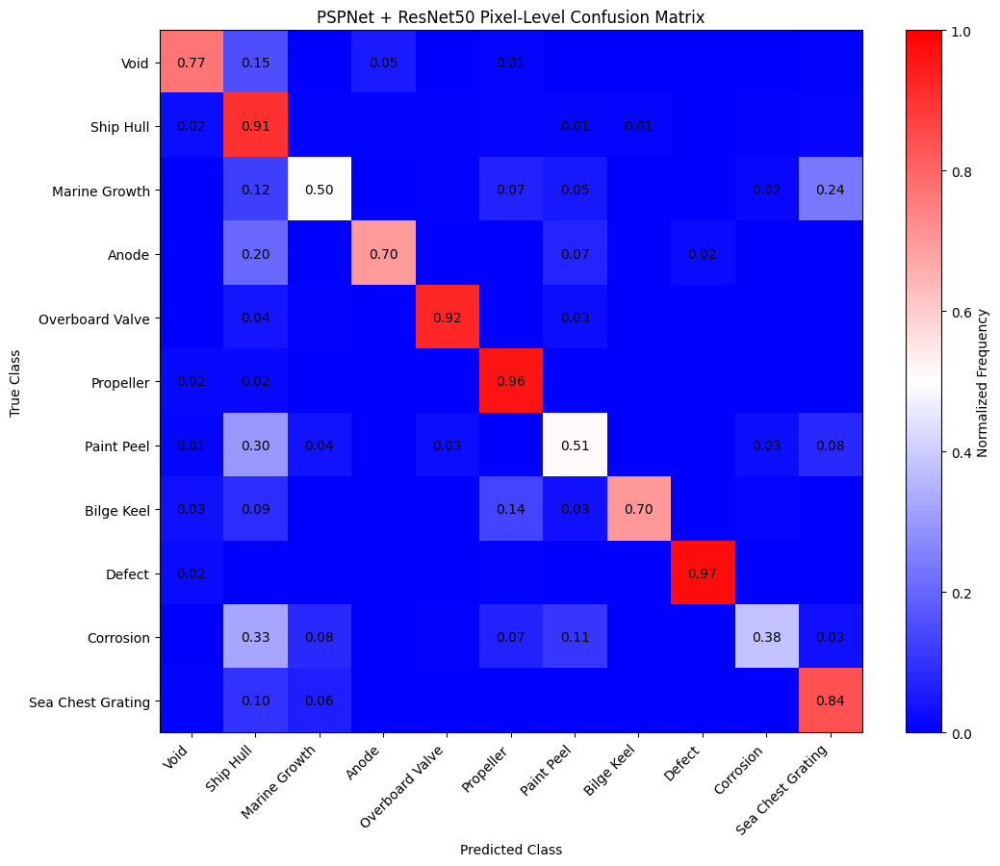

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

all_true = []
all_pred = []

eval_model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)

        x = eval_model.layer0(images)
        x = eval_model.layer1(x)
        x = eval_model.layer2(x)

        x_aux = eval_model.layer3(x)
        x = eval_model.layer4(x_aux)

        x = eval_model.psp(x)
        outputs = eval_model.decoder(x)

        outputs = F.interpolate(
            outputs,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        predictions = torch.argmax(outputs, dim=1)

        all_true.append(masks.numpy().reshape(-1))
        all_pred.append(
            predictions.cpu().numpy().reshape(-1)
        )


all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

cm = confusion_matrix(
    all_true,
    all_pred,
    labels=list(range(11))
)

# Normalize each row
cm_normalized = cm.astype(float) / (
    cm.sum(axis=1, keepdims=True) + 1e-7
)

class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]

plt.figure(figsize=(11, 9))

plt.imshow(
    cm_normalized,
    cmap="bwr",
    vmin=0,
    vmax=1
)

plt.xticks(
    range(11),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(11),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.title(
    "PSPNet + ResNet50 Pixel-Level Confusion Matrix"
)

plt.colorbar(label="Normalized Frequency")

for i in range(11):
    for j in range(11):
        value = cm_normalized[i, j]

        if value > 0.01:
            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                color="black"
            )

plt.tight_layout()
plt.show()

In [ ]:
class_colors = np.array([
    [0, 0, 0],          # Void
    [0, 0, 255],        # Ship Hull
    [0, 128, 0],        # Marine Growth
    [0, 255, 255],      # Anode
    [64, 224, 208],     # Overboard Valve
    [128, 0, 128],      # Propeller
    [255, 0, 0],        # Paint Peel
    [255, 165, 0],      # Bilge Keel
    [255, 192, 203],    # Defect
    [255, 255, 0],      # Corrosion
    [255, 255, 255]     # Sea Chest Grating
], dtype=np.uint8)

class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]

print("Class colors ready!")

Class colors ready!


In [ ]:
# Rebuild the exact PSPNet model used during training

eval_model = PSPNetResNet50(num_classes=11).to(device)

checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_best.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

eval_model.load_state_dict(checkpoint)
eval_model.eval()

print("PSPNet checkpoint loaded successfully!")

PSPNet checkpoint loaded successfully!


In [ ]:
print("Layer 4 output channels:", eval_model.layer4[-1].conv3.out_channels)

print("PSP input channels:",
      eval_model.psp.pool1[1].in_channels)

print("PSP output channels:",
      eval_model.psp.pool1[1].out_channels)

print("PSP conv input channels:",
      eval_model.psp.conv[0].in_channels)

Layer 4 output channels: 2048
PSP input channels: 2048
PSP output channels: 512
PSP conv input channels: 4096


In [ ]:
for name, module in eval_model.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        if module.in_channels == 1024 and module.out_channels == 512:
            print("Found:", name, "|", module.in_channels, "->", module.out_channels)

Found: layer4.0.conv1 | 1024 -> 512


In [ ]:
def correct_forward(self, x):

    input_h, input_w = x.shape[2], x.shape[3]

    x = self.layer0(x)
    x = self.layer1(x)
    x = self.layer2(x)

    x_aux = self.layer3(x)

    # IMPORTANT: layer4 must receive layer3 output
    x = self.layer4(x_aux)

    x = self.psp(x)
    x = self.decoder(x)

    x = torch.nn.functional.interpolate(
        x,
        size=(input_h, input_w),
        mode="bilinear",
        align_corners=False
    )

    aux = self.auxiliary(x_aux)

    aux = torch.nn.functional.interpolate(
        aux,
        size=(input_h, input_w),
        mode="bilinear",
        align_corners=False
    )

    return x, aux


eval_model.forward = correct_forward.__get__(eval_model, PSPNetResNet50)

eval_model.eval()

print("Correct PSPNet forward path applied!")

Correct PSPNet forward path applied!


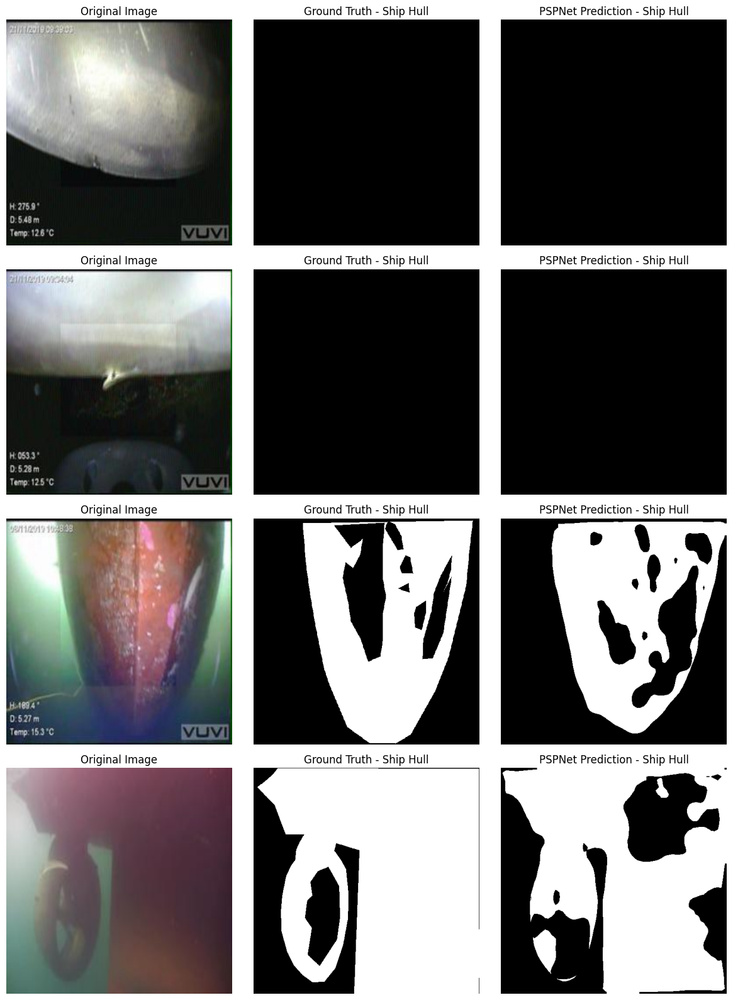

In [ ]:
import matplotlib.pyplot as plt
import torch

eval_model.eval()

num_images = 4

fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))

with torch.no_grad():

    for i in range(num_images):

        image, true_mask = test_dataset[i]

        # Add batch dimension
        image_input = image.unsqueeze(0).to(device)

        # PSPNet prediction
        output, _ = eval_model(image_input)

        prediction = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()
        true_mask = true_mask.numpy()

        # Original image
        original = image.permute(1, 2, 0).numpy()

        # Ship hull = class 1
        true_ship = (true_mask == 1)
        predicted_ship = (prediction == 1)

        # Show results
        axes[i, 0].imshow(original)
        axes[i, 0].set_title("Original Image")

        axes[i, 1].imshow(true_ship, cmap="gray")
        axes[i, 1].set_title("Ground Truth - Ship Hull")

        axes[i, 2].imshow(predicted_ship, cmap="gray")
        axes[i, 2].set_title("PSPNet Prediction - Ship Hull")

        for j in range(3):
            axes[i, j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
eval_model.eval()

with torch.no_grad():

    for i in range(2):

        image, true_mask = test_dataset[i]

        output, _ = eval_model(image.unsqueeze(0).to(device))

        prediction = torch.argmax(output, dim=1).squeeze(0).cpu()

        print("Image", i)
        print("Ground truth classes:", torch.unique(true_mask).tolist())
        print("Predicted classes:", torch.unique(prediction).tolist())
        print("Predicted pixel counts:")

        classes, counts = torch.unique(prediction, return_counts=True)

        for cls, count in zip(classes.tolist(), counts.tolist()):
            print(f"  {class_names[cls]}: {count}")

        print()

Image 0
Ground truth classes: [0, 5, 8]
Predicted classes: [0, 5, 8]
Predicted pixel counts:
  Void: 93296
  Propeller: 167244
  Defect: 1604

Image 1
Ground truth classes: [0, 5, 8]
Predicted classes: [0, 5, 8]
Predicted pixel counts:
  Void: 139766
  Propeller: 117830
  Defect: 4548



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):

    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):

        ce = F.cross_entropy(
            inputs,
            targets,
            weight=self.alpha,
            reduction="none"
        )

        pt = torch.exp(-ce)

        focal = ((1 - pt) ** self.gamma) * ce

        return focal.mean()


class DiceLoss(nn.Module):

    def __init__(self, num_classes=11):
        super().__init__()
        self.num_classes = num_classes

    def forward(self, inputs, targets):

        probs = torch.softmax(inputs, dim=1)

        targets_one_hot = F.one_hot(
            targets,
            num_classes=self.num_classes
        ).permute(0, 3, 1, 2).float()

        smooth = 1e-5

        intersection = (probs * targets_one_hot).sum(dim=(0, 2, 3))
        denominator = probs.sum(dim=(0, 2, 3)) + targets_one_hot.sum(dim=(0, 2, 3))

        dice = (2 * intersection + smooth) / (denominator + smooth)

        return 1 - dice.mean()


print("Focal + Dice losses ready!")

Focal + Dice losses ready!


In [ ]:
# Class weights for rare classes

class_weights = torch.tensor([
    0.5,   # Void
    1.0,   # Ship Hull
    1.5,   # Marine Growth
    3.0,   # Anode
    2.5,   # Overboard Valve
    1.5,   # Propeller
    2.0,   # Paint Peel
    2.0,   # Bilge Keel
    4.0,   # Defect
    3.0,   # Corrosion
    1.5    # Sea Chest Grating
], dtype=torch.float32).to(device)

# Load the best PSPNet checkpoint
checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_best.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

eval_model.load_state_dict(checkpoint)
eval_model.eval()

# Fine-tuning optimizer
optimizer = torch.optim.AdamW(
    eval_model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

print("PSPNet fine-tuning setup ready!")
print("Learning rate:", 1e-5)

PSPNet fine-tuning setup ready!
Learning rate: 1e-05


In [ ]:
from torch.utils.data import DataLoader

train_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/train",
    PROCESSED_DIR + "/gtFine/train"
)

val_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/val",
    PROCESSED_DIR + "/gtFine/val"
)

test_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/test",
    PROCESSED_DIR + "/gtFine/test"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

print("DataLoaders ready!")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

DataLoaders ready!
Train: 1703
Validation: 133
Test: 57


In [ ]:
print("GPU:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU: True
Device: Tesla T4


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print("Loaders reset with num_workers=0")

Loaders reset with num_workers=0


In [ ]:
eval_model.train()

images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

print("Batch loaded:", images.shape)

optimizer.zero_grad()

outputs, aux_outputs = eval_model(images)

print("Forward pass completed!")

main_focal = focal_loss(outputs, masks)
main_dice = dice_loss(outputs, masks)

aux_focal = focal_loss(aux_outputs, masks)
aux_dice = dice_loss(aux_outputs, masks)

loss = (
    0.6 * main_focal +
    0.4 * main_dice +
    0.4 * (0.6 * aux_focal + 0.4 * aux_dice)
)

loss.backward()
optimizer.step()

print("One training batch completed!")
print("Loss:", loss.item())

Batch loaded: torch.Size([4, 3, 512, 512])
Forward pass completed!
One training batch completed!
Loss: 0.6283262968063354


In [ ]:
import torch

best_val_loss = float("inf")
patience = 7
counter = 0

best_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_finetuned_best.pth"

for epoch in range(30):

    # -------------------------
    # Training
    # -------------------------
    eval_model.train()

    train_loss = 0.0

    total_batches = len(train_loader)

    for batch_idx, (images, masks) in enumerate(train_loader):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs, aux_outputs = eval_model(images)

        main_focal = focal_loss(outputs, masks)
        main_dice = dice_loss(outputs, masks)

        aux_focal = focal_loss(aux_outputs, masks)
        aux_dice = dice_loss(aux_outputs, masks)

        main_loss = 0.6 * main_focal + 0.4 * main_dice
        aux_loss = 0.6 * aux_focal + 0.4 * aux_dice

        loss = main_loss + 0.4 * aux_loss

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # Show progress
        if (batch_idx + 1) % 50 == 0:
            print(
                f"Epoch {epoch+1}/30 | "
                f"Batch {batch_idx+1}/{total_batches} | "
                f"Loss: {loss.item():.4f}"
            )

    train_loss /= total_batches

    # -------------------------
    # Validation
    # -------------------------
    eval_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs, aux_outputs = eval_model(images)

            main_focal = focal_loss(outputs, masks)
            main_dice = dice_loss(outputs, masks)

            aux_focal = focal_loss(aux_outputs, masks)
            aux_dice = dice_loss(aux_outputs, masks)

            main_loss = 0.6 * main_focal + 0.4 * main_dice
            aux_loss = 0.6 * aux_focal + 0.4 * aux_dice

            loss = main_loss + 0.4 * aux_loss

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(
        f"Epoch {epoch+1}/30 COMPLETE | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

    # -------------------------
    # Save best model
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        counter = 0

        torch.save(
            eval_model.state_dict(),
            best_path
        )

        print(">>> BEST MODEL SAVED")

    else:

        counter += 1

        print(
            f"No improvement ({counter}/{patience})"
        )

        if counter >= patience:
            print("Early stopping triggered.")
            break

print("Fine-tuning complete!")
print("Best validation loss:", best_val_loss)

Epoch 1/30 | Batch 50/426 | Loss: 0.3878
Epoch 1/30 | Batch 100/426 | Loss: 0.4730
Epoch 1/30 | Batch 150/426 | Loss: 0.4196
Epoch 1/30 | Batch 200/426 | Loss: 0.7700
Epoch 1/30 | Batch 250/426 | Loss: 0.4075
Epoch 1/30 | Batch 300/426 | Loss: 0.4461
Epoch 1/30 | Batch 350/426 | Loss: 0.4419
Epoch 1/30 | Batch 400/426 | Loss: 0.3693
Epoch 1/30 COMPLETE | Train Loss: 0.5110 | Val Loss: 0.7699
>>> BEST MODEL SAVED
Epoch 2/30 | Batch 50/426 | Loss: 0.5471
Epoch 2/30 | Batch 100/426 | Loss: 0.6431
Epoch 2/30 | Batch 150/426 | Loss: 0.4238
Epoch 2/30 | Batch 200/426 | Loss: 0.5632
Epoch 2/30 | Batch 250/426 | Loss: 0.5039
Epoch 2/30 | Batch 300/426 | Loss: 0.5004
Epoch 2/30 | Batch 350/426 | Loss: 0.3891
Epoch 2/30 | Batch 400/426 | Loss: 0.5517
Epoch 2/30 COMPLETE | Train Loss: 0.5027 | Val Loss: 0.7710
No improvement (1/7)
Epoch 3/30 | Batch 50/426 | Loss: 0.4860
Epoch 3/30 | Batch 100/426 | Loss: 0.4972
Epoch 3/30 | Batch 150/426 | Loss: 0.6331
Epoch 3/30 | Batch 200/426 | Loss: 0.5241
E

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50


class PyramidPooling(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.pool1 = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool2 = nn.Sequential(
            nn.AdaptiveAvgPool2d(2),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool3 = nn.Sequential(
            nn.AdaptiveAvgPool2d(3),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool6 = nn.Sequential(
            nn.AdaptiveAvgPool2d(6),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels + 4 * out_channels,
                out_channels,
                1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )

    def forward(self, x):

        h, w = x.shape[2], x.shape[3]

        p1 = F.interpolate(
            self.pool1(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p2 = F.interpolate(
            self.pool2(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p3 = F.interpolate(
            self.pool3(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p6 = F.interpolate(
            self.pool6(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat(
            [x, p1, p2, p3, p6],
            dim=1
        )

        return self.conv(x)


class PSPNetResNet50(nn.Module):

    def __init__(self, num_classes=11):
        super().__init__()

        backbone = resnet50(
            weights=None,
            replace_stride_with_dilation=[False, True, True]
        )

        self.layer0 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool
        )

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.psp = PyramidPooling(
            in_channels=2048,
            out_channels=512
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            nn.Conv2d(256, num_classes, 1)
        )

        self.auxiliary = nn.Sequential(
            nn.Conv2d(1024, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, x):

        input_h, input_w = x.shape[2], x.shape[3]

        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)

        x_aux = self.layer3(x)

        # Correct connection
        x = self.layer4(x_aux)

        x = self.psp(x)
        x = self.decoder(x)

        x = F.interpolate(
            x,
            size=(input_h, input_w),
            mode="bilinear",
            align_corners=False
        )

        aux = self.auxiliary(x_aux)

        aux = F.interpolate(
            aux,
            size=(input_h, input_w),
            mode="bilinear",
            align_corners=False
        )

        return x, aux


print("Correct PSPNet architecture ready!")

Correct PSPNet architecture ready!


In [ ]:
finetuned_model = PSPNetResNet50(num_classes=11).to(device)

checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_finetuned_best.pth"

finetuned_model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

finetuned_model.eval()

print("Fine-tuned PSPNet checkpoint loaded!")

Fine-tuned PSPNet checkpoint loaded!


In [ ]:
images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs, aux_outputs = finetuned_model(images)

print("Input :", images.shape)
print("Output:", outputs.shape)
print("Mask  :", masks.shape)

Input : torch.Size([4, 3, 512, 512])
Output: torch.Size([4, 11, 512, 512])
Mask  : torch.Size([4, 512, 512])


In [ ]:
finetuned_model.eval()

total_correct = 0
total_pixels = 0
total_loss = 0.0

intersection = torch.zeros(11, device=device)
union = torch.zeros(11, device=device)

dice_intersection = torch.zeros(11, device=device)
dice_total = torch.zeros(11, device=device)

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs, aux_outputs = finetuned_model(images)

        # Test loss
        main_focal = focal_loss(outputs, masks)
        main_dice = dice_loss(outputs, masks)

        loss = 0.6 * main_focal + 0.4 * main_dice

        total_loss += loss.item()

        # Predictions
        predictions = torch.argmax(outputs, dim=1)

        # Pixel accuracy
        total_correct += (predictions == masks).sum().item()
        total_pixels += masks.numel()

        # IoU and Dice
        for cls in range(11):

            pred_cls = predictions == cls
            mask_cls = masks == cls

            inter = (pred_cls & mask_cls).sum()
            uni = (pred_cls | mask_cls).sum()

            intersection[cls] += inter
            union[cls] += uni

            dice_intersection[cls] += 2 * inter
            dice_total[cls] += pred_cls.sum() + mask_cls.sum()


test_loss = total_loss / len(test_loader)

pixel_accuracy = (
    total_correct / total_pixels
) * 100

iou = intersection / (union + 1e-8)
dice = dice_intersection / (dice_total + 1e-8)

mean_iou = iou.mean().item() * 100
mean_dice = dice.mean().item() * 100


print("======================================")
print("Fine-tuned PSPNet Test Results")
print("======================================")

print(f"Test Loss      : {test_loss:.4f}")
print(f"Pixel Accuracy : {pixel_accuracy:.2f}%")
print(f"Mean IoU       : {mean_iou:.2f}%")
print(f"Mean Dice      : {mean_dice:.2f}%")

print("\nPer-Class IoU:")

for i, name in enumerate(class_names):
    print(f"{name:20s}: {iou[i].item()*100:.2f}%")

Fine-tuned PSPNet Test Results
Test Loss      : 0.5616
Pixel Accuracy : 83.48%
Mean IoU       : 52.81%
Mean Dice      : 66.47%

Per-Class IoU:
Void                : 71.60%
Ship Hull           : 79.04%
Marine Growth       : 55.01%
Anode               : 62.20%
Overboard Valve     : 55.20%
Propeller           : 76.06%
Paint Peel          : 36.19%
Bilge Keel          : 31.86%
Defect              : 15.53%
Corrosion           : 27.30%
Sea Chest Grating   : 70.97%


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PSPNetResNet50(num_classes=11).to(device)

checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_finetuned_best.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model.load_state_dict(checkpoint)

model.eval()

print("Fine-tuned PSPNet loaded!")
print("Device:", device)

Fine-tuned PSPNet loaded!
Device: cuda


In [ ]:
import torch.nn.functional as F

def tta_predict(model, image):

    image = image.to(device)

    predictions = []

    # Original
    output, _ = model(image)
    output = F.softmax(output, dim=1)
    predictions.append(output)

    # Horizontal flip
    flipped = torch.flip(image, dims=[3])
    output, _ = model(flipped)
    output = F.softmax(output, dim=1)
    output = torch.flip(output, dims=[3])
    predictions.append(output)

    # Average predictions
    final_prediction = torch.stack(predictions).mean(dim=0)

    return final_prediction

In [ ]:
#TTA EVALUATION

import numpy as np

num_classes = 11

confusion_matrix = np.zeros(
    (num_classes, num_classes),
    dtype=np.int64
)

test_loss = 0.0
total_pixels = 0

criterion = torch.nn.CrossEntropyLoss()

with torch.no_grad():

    for images, masks in test_loader:

        predictions = tta_predict(model, images)

        # Final predicted class
        preds = predictions.argmax(dim=1)

        # Loss using averaged probability
        loss = -torch.log(
            predictions.clamp(min=1e-7)
        ).gather(
            1,
            masks.unsqueeze(1).to(device)
        ).mean()

        test_loss += loss.item() * images.size(0)

        masks = masks.to(device)

        total_pixels += masks.numel()

        # Confusion matrix
        y_true = masks.cpu().numpy().flatten()
        y_pred = preds.cpu().numpy().flatten()

        for true_class, pred_class in zip(y_true, y_pred):
            confusion_matrix[true_class, pred_class] += 1


test_loss = test_loss / len(test_loader.dataset)

# IoU for each class
ious = []

for i in range(num_classes):

    tp = confusion_matrix[i, i]
    fp = confusion_matrix[:, i].sum() - tp
    fn = confusion_matrix[i, :].sum() - tp

    denominator = tp + fp + fn

    if denominator == 0:
        iou = float("nan")
    else:
        iou = tp / denominator

    ious.append(iou)


mean_iou = np.nanmean(ious)

# Pixel accuracy
pixel_accuracy = np.trace(confusion_matrix) / confusion_matrix.sum()

# Dice
dice_scores = []

for i in range(num_classes):

    tp = confusion_matrix[i, i]
    fp = confusion_matrix[:, i].sum() - tp
    fn = confusion_matrix[i, :].sum() - tp

    denominator = 2 * tp + fp + fn

    if denominator == 0:
        dice = float("nan")
    else:
        dice = (2 * tp) / denominator

    dice_scores.append(dice)

mean_dice = np.nanmean(dice_scores)


print("TTA Results")
print("-----------------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Pixel Accuracy: {pixel_accuracy * 100:.2f}%")
print(f"Mean IoU: {mean_iou * 100:.2f}%")
print(f"Mean Dice: {mean_dice * 100:.2f}%")

print("\nPer-class IoU:")

class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]

for name, iou in zip(class_names, ious):
    print(f"{name}: {iou * 100:.2f}%")

TTA Results
-----------------------------
Test Loss: 0.5300
Pixel Accuracy: 83.95%
Mean IoU: 56.52%
Mean Dice: 70.50%

Per-class IoU:
Void: 72.52%
Ship Hull: 79.78%
Marine Growth: 55.48%
Anode: 64.46%
Overboard Valve: 53.05%
Propeller: 76.49%
Paint Peel: 36.75%
Bilge Keel: 36.09%
Defect: 53.12%
Corrosion: 23.40%
Sea Chest Grating: 70.62%


In [ ]:
import os
import cv2

train_mask_dir = PROCESSED_DIR + "/gtFine/train"

class_names = {
    6: "Paint Peel",
    7: "Bilge Keel",
    8: "Defect",
    9: "Corrosion"
}

class_counts = {name: 0 for name in class_names.values()}

for mask_name in os.listdir(train_mask_dir):

    mask_path = os.path.join(train_mask_dir, mask_name)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    for class_id, class_name in class_names.items():

        if (mask == class_id).any():
            class_counts[class_name] += 1

print("Rare-class training image counts:")
print("-----------------------------------")

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

NameError: name 'PROCESSED_DIR' is not defined

In [ ]:
from collections import Counter
import os
import cv2

combination_counts = Counter()

for mask_name in os.listdir(train_mask_dir):

    mask_path = os.path.join(train_mask_dir, mask_name)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    present_classes = []

    for class_id, class_name in class_names.items():

        if (mask == class_id).any():
            present_classes.append(class_name)

    if present_classes:
        combination_counts[tuple(present_classes)] += 1


print("Rare-class combinations:")
print("-------------------------")

for combination, count in combination_counts.most_common():
    print(f"{' + '.join(combination)}: {count}")

Rare-class combinations:
-------------------------
Paint Peel: 612
Bilge Keel: 114
Corrosion: 91
Paint Peel + Corrosion: 70
Paint Peel + Bilge Keel: 43
Defect: 36
Paint Peel + Defect: 23
Bilge Keel + Corrosion: 10
Paint Peel + Defect + Corrosion: 5
Paint Peel + Bilge Keel + Corrosion: 5
Paint Peel + Bilge Keel + Defect: 1
Bilge Keel + Defect: 1
Defect + Corrosion: 1


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class_colors = np.array([
    [0, 0, 0],         # Void
    [0, 0, 255],       # Ship Hull
    [0, 128, 0],       # Marine Growth
    [0, 255, 255],     # Anode
    [64, 224, 208],    # Overboard Valve
    [128, 0, 128],     # Propeller
    [255, 0, 0],       # Paint Peel
    [255, 165, 0],     # Bilge Keel
    [255, 192, 203],   # Defect
    [255, 255, 0],     # Corrosion
    [255, 255, 255]    # Sea Chest Grating
], dtype=np.uint8)

class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]

def colorize_mask(mask):
    return class_colors[mask]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

shown = 0

with torch.no_grad():

    for images, masks in test_loader:

        predictions = tta_predict(model, images)
        preds = predictions.argmax(dim=1)

        for i in range(images.size(0)):

            image = images[i].cpu().permute(1, 2, 0).numpy()
            true_mask = masks[i].numpy()
            pred_mask = preds[i].cpu().numpy()

            present_classes = np.unique(true_mask)

            names_present = [
                class_names[c]
                for c in present_classes
            ]

            fig, axes = plt.subplots(1, 3, figsize=(15, 5))

            axes[0].imshow(image)
            axes[0].set_title("Original Image")
            axes[0].axis("off")

            axes[1].imshow(colorize_mask(true_mask))
            axes[1].set_title("Ground Truth")
            axes[1].axis("off")

            axes[2].imshow(colorize_mask(pred_mask))
            axes[2].set_title("TTA Prediction")
            axes[2].axis("off")

            fig.suptitle(
                "Classes in Ground Truth: " + ", ".join(names_present),
                fontsize=12
            )

            plt.tight_layout()
            plt.show()

            shown += 1

            if shown == 5:
                break

        if shown == 5:
            break

NameError: name 'model' is not defined

In [ ]:
from torch.utils.data import WeightedRandomSampler

sample_weights = []

for mask_name in train_dataset.masks:

    mask_path = os.path.join(train_dataset.mask_dir, mask_name)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if (mask == 8).any():          # Defect
        weight = 4.0

    elif (mask == 9).any():        # Corrosion
        weight = 2.0

    elif (mask == 7).any():        # Bilge Keel
        weight = 2.0

    elif (mask == 6).any():        # Paint Peel
        weight = 1.2

    else:
        weight = 1.0

    sample_weights.append(weight)


sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(train_dataset),
    replacement=True
)

print("Weighted sampler ready!")
print("Training samples per epoch:", len(train_dataset))

Weighted sampler ready!
Training samples per epoch: 1703


In [ ]:
train_loader_rare = DataLoader(
    train_dataset,
    batch_size=4,
    sampler=sampler,
    num_workers=0
)

print("Rare-class DataLoader ready!")
print("Batches per epoch:", len(train_loader_rare))

Rare-class DataLoader ready!
Batches per epoch: 426


In [ ]:
model = PSPNetResNet50(num_classes=11).to(device)

checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_finetuned_best.pth"

model.load_state_dict(torch.load(checkpoint_path, map_location=device))

print("Previous best PSPNet checkpoint loaded!")

Previous best PSPNet checkpoint loaded!


In [ ]:
class LovaszSoftmaxLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, logits, labels):

        probs = torch.softmax(logits, dim=1)

        losses = []

        for c in range(probs.shape[1]):

            prob = probs[:, c]
            target = (labels == c).float()

            errors = (target - prob).abs()

            errors = errors.view(-1)
            target = target.view(-1)

            errors_sorted, perm = torch.sort(
                errors,
                descending=True
            )

            target_sorted = target[perm]

            intersection = target_sorted.sum() - target_sorted.float().cumsum(0)

            union = target_sorted.sum() + (1 - target_sorted).cumsum(0)

            jaccard = 1.0 - intersection / union

            if len(jaccard) > 1:
                jaccard[1:] = jaccard[1:] - jaccard[:-1]

            losses.append(
                torch.dot(errors_sorted, jaccard)
            )

        return torch.stack(losses).mean()


lovasz_loss = LovaszSoftmaxLoss().to(device)

print("Lovasz-Softmax loss ready!")

Lovasz-Softmax loss ready!


In [ ]:
model = PSPNetResNet50(num_classes=11).to(device)

checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_finetuned_best.pth"

model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

print("52.81% PSPNet checkpoint loaded!")

NameError: name 'PSPNetResNet50' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50


class PyramidPooling(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.pool1 = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool2 = nn.Sequential(
            nn.AdaptiveAvgPool2d(2),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool3 = nn.Sequential(
            nn.AdaptiveAvgPool2d(3),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool6 = nn.Sequential(
            nn.AdaptiveAvgPool2d(6),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels + 4 * out_channels,
                out_channels,
                1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )

    def forward(self, x):

        h, w = x.shape[2], x.shape[3]

        p1 = F.interpolate(
            self.pool1(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p2 = F.interpolate(
            self.pool2(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p3 = F.interpolate(
            self.pool3(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p6 = F.interpolate(
            self.pool6(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat(
            [x, p1, p2, p3, p6],
            dim=1
        )

        return self.conv(x)


class PSPNetResNet50(nn.Module):

    def __init__(self, num_classes=11):
        super().__init__()

        backbone = resnet50(
            weights=None,
            replace_stride_with_dilation=[False, True, True]
        )

        self.layer0 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool
        )

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.psp = PyramidPooling(
            in_channels=2048,
            out_channels=512
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            nn.Conv2d(256, num_classes, 1)
        )

        self.auxiliary = nn.Sequential(
            nn.Conv2d(1024, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),

            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, x):

        input_h, input_w = x.shape[2], x.shape[3]

        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)

        x_aux = self.layer3(x)

        x = self.layer4(x_aux)

        x = self.psp(x)
        x = self.decoder(x)

        x = F.interpolate(
            x,
            size=(input_h, input_w),
            mode="bilinear",
            align_corners=False
        )

        aux = self.auxiliary(x_aux)

        aux = F.interpolate(
            aux,
            size=(input_h, input_w),
            mode="bilinear",
            align_corners=False
        )

        return x, aux


print("PSPNet architecture ready!")

PSPNet architecture ready!


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
model = PSPNetResNet50(num_classes=11).to(device)

checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_finetuned_best.pth"

model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

print("52.81% PSPNet checkpoint loaded!")

52.81% PSPNet checkpoint loaded!


In [ ]:
class LovaszSoftmaxLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, logits, labels):

        probs = torch.softmax(logits, dim=1)

        losses = []

        for c in range(probs.shape[1]):

            prob = probs[:, c]
            target = (labels == c).float()

            errors = (target - prob).abs()

            errors = errors.view(-1)
            target = target.view(-1)

            errors_sorted, perm = torch.sort(
                errors,
                descending=True
            )

            target_sorted = target[perm]

            intersection = target_sorted.sum() - target_sorted.float().cumsum(0)

            union = target_sorted.sum() + (1 - target_sorted).cumsum(0)

            jaccard = 1.0 - intersection / union

            if len(jaccard) > 1:
                jaccard[1:] = jaccard[1:] - jaccard[:-1]

            losses.append(
                torch.dot(errors_sorted, jaccard)
            )

        return torch.stack(losses).mean()


lovasz_loss = LovaszSoftmaxLoss().to(device)

print("Lovasz-Softmax loss ready!")

Lovasz-Softmax loss ready!


In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

PROCESSED_DIR = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_processed"


class LIACiDataset(Dataset):

    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = os.path.join(
            self.image_dir,
            self.images[idx]
        )

        mask_path = os.path.join(
            self.mask_dir,
            self.masks[idx]
        )

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1) / 255.0

        mask = torch.tensor(
            mask,
            dtype=torch.long
        )

        return image, mask


train_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/train",
    PROCESSED_DIR + "/gtFine/train"
)

val_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/val",
    PROCESSED_DIR + "/gtFine/val"
)

test_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/test",
    PROCESSED_DIR + "/gtFine/test"
)

print("Datasets ready!")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Datasets ready!
Train: 1703
Validation: 133
Test: 57


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print("DataLoaders ready!")
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders ready!
Train batches: 426
Validation batches: 34
Test batches: 15


In [ ]:
class DiceLoss(nn.Module):

    def __init__(self, num_classes=11):
        super().__init__()
        self.num_classes = num_classes

    def forward(self, inputs, targets):

        probs = torch.softmax(inputs, dim=1)

        targets_one_hot = F.one_hot(
            targets,
            num_classes=self.num_classes
        ).permute(0, 3, 1, 2).float()

        smooth = 1e-5

        intersection = (
            probs * targets_one_hot
        ).sum(dim=(0, 2, 3))

        denominator = (
            probs.sum(dim=(0, 2, 3))
            + targets_one_hot.sum(dim=(0, 2, 3))
        )

        dice = (
            2 * intersection + smooth
        ) / (
            denominator + smooth
        )

        return 1 - dice.mean()


dice_loss = DiceLoss(num_classes=11).to(device)

print("Dice loss ready!")

Dice loss ready!


In [ ]:
def lovasz_grad(gt_sorted):

    p = len(gt_sorted)

    gts = gt_sorted.sum()

    intersection = gts - gt_sorted.float().cumsum(0)

    union = gts + (1 - gt_sorted).float().cumsum(0)

    jaccard = 1.0 - intersection / union

    if p > 1:
        jaccard[1:p] = jaccard[1:p] - jaccard[:-1]

    return jaccard


def lovasz_softmax_flat(probas, labels, classes="present"):

    if probas.numel() == 0:
        return probas * 0.

    losses = []

    class_to_sum = range(probas.size(1))

    for c in class_to_sum:

        fg = (labels == c).float()

        if classes == "present" and fg.sum() == 0:
            continue

        if probas.size(1) == 1:
            if len(classes) > 1:
                raise ValueError("Wrong number of classes")
            cls_pred = probas[:, 0]
        else:
            cls_pred = probas[:, c]

        errors = (fg - cls_pred).abs()

        errors_sorted, perm = torch.sort(
            errors,
            descending=True
        )

        fg_sorted = fg[perm]

        losses.append(
            torch.dot(
                errors_sorted,
                lovasz_grad(fg_sorted)
            )
        )

    if not losses:
        return probas.sum() * 0.

    return torch.mean(torch.stack(losses))


def lovasz_softmax(probas, labels, classes="present"):

    losses = []

    for prob, label in zip(probas, labels):

        losses.append(
            lovasz_softmax_flat(
                prob.unsqueeze(0).permute(1, 0, 2, 3).reshape(-1, prob.size(0)),
                label.reshape(-1),
                classes
            )
        )

    return torch.mean(torch.stack(losses))


class LovaszSoftmaxLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, logits, labels):

        probs = torch.softmax(logits, dim=1)

        return lovasz_softmax(
            probs,
            labels,
            classes="present"
        )


lovasz_loss = LovaszSoftmaxLoss().to(device)

print("Fast Lovasz-Softmax loss ready!")

Fast Lovasz-Softmax loss ready!


In [ ]:
import time

model.train()

images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

start = time.time()

outputs, aux_outputs = model(images)

main_lovasz = lovasz_loss(outputs, masks)
main_dice = dice_loss(outputs, masks)

aux_lovasz = lovasz_loss(aux_outputs, masks)
aux_dice = dice_loss(aux_outputs, masks)

main_loss = 0.6 * main_lovasz + 0.4 * main_dice
aux_loss = 0.6 * aux_lovasz + 0.4 * aux_dice

loss = main_loss + 0.4 * aux_loss

loss.backward()

elapsed = time.time() - start

print(f"One batch time: {elapsed:.2f} seconds")
print(f"Loss: {loss.item():.4f}")

One batch time: 0.50 seconds
Loss: 1.1164


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

best_val_loss = float("inf")
patience = 7
patience_counter = 0

save_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_lovasz_dice_best.pth"

for epoch in range(20):

    model.train()
    train_loss = 0

    print(f"\nEpoch {epoch+1}/20")

    for batch_idx, (images, masks) in enumerate(train_loader):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs, aux_outputs = model(images)

        main_lovasz = lovasz_loss(outputs, masks)
        main_dice = dice_loss(outputs, masks)

        aux_lovasz = lovasz_loss(aux_outputs, masks)
        aux_dice = dice_loss(aux_outputs, masks)

        main_loss = 0.6 * main_lovasz + 0.4 * main_dice
        aux_loss = 0.6 * aux_lovasz + 0.4 * aux_dice

        loss = main_loss + 0.4 * aux_loss

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(
                f"  Batch {batch_idx+1}/{len(train_loader)} "
                f"- Loss: {loss.item():.4f}"
            )

    train_loss /= len(train_loader)

    print(f"Training complete - Train Loss: {train_loss:.4f}")
    print("Starting validation...")

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for batch_idx, (images, masks) in enumerate(val_loader):

            images = images.to(device)
            masks = masks.to(device)

            outputs, aux_outputs = model(images)

            main_lovasz = lovasz_loss(outputs, masks)
            main_dice = dice_loss(outputs, masks)

            aux_lovasz = lovasz_loss(aux_outputs, masks)
            aux_dice = dice_loss(aux_outputs, masks)

            main_loss = 0.6 * main_lovasz + 0.4 * main_dice
            aux_loss = 0.6 * aux_lovasz + 0.4 * aux_dice

            loss = main_loss + 0.4 * aux_loss

            val_loss += loss.item()

            if (batch_idx + 1) % 10 == 0:
                print(
                    f"  Validation batch "
                    f"{batch_idx+1}/{len(val_loader)}"
                )

    val_loss /= len(val_loader)

    print(
        f"Epoch {epoch+1}/20 complete - "
        f"Train Loss: {train_loss:.4f} - "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            save_path
        )

        print("BEST MODEL SAVED!")

    else:
        patience_counter += 1
        print(f"No improvement - patience {patience_counter}/7")

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

print("\nLovasz + Dice training complete!")
print("Best validation loss:", best_val_loss)


Epoch 1/20
  Batch 50/426 - Loss: 1.0912
  Batch 100/426 - Loss: 1.1784
  Batch 150/426 - Loss: 1.1500
  Batch 200/426 - Loss: 1.0311
  Batch 250/426 - Loss: 1.0519
  Batch 300/426 - Loss: 1.0165
  Batch 350/426 - Loss: 1.1215
  Batch 400/426 - Loss: 1.0528
Training complete - Train Loss: 1.0831
Starting validation...
  Validation batch 10/34
  Validation batch 20/34
  Validation batch 30/34
Epoch 1/20 complete - Train Loss: 1.0831 - Val Loss: 1.1609
BEST MODEL SAVED!

Epoch 2/20
  Batch 50/426 - Loss: 1.0333
  Batch 100/426 - Loss: 1.0933
  Batch 150/426 - Loss: 1.0782
  Batch 200/426 - Loss: 1.0555
  Batch 250/426 - Loss: 1.0982
  Batch 300/426 - Loss: 1.1008
  Batch 350/426 - Loss: 1.0845
  Batch 400/426 - Loss: 1.0247
Training complete - Train Loss: 1.0786
Starting validation...
  Validation batch 10/34
  Validation batch 20/34
  Validation batch 30/34
Epoch 2/20 complete - Train Loss: 1.0786 - Val Loss: 1.1607
BEST MODEL SAVED!

Epoch 3/20
  Batch 50/426 - Loss: 1.0991
  Batch 10

KeyboardInterrupt: 

In [ ]:
checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_lovasz_dice_best.pth"

model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

model = model.to(device)
model.eval()

print("Best Lovasz + Dice checkpoint loaded!")

Best Lovasz + Dice checkpoint loaded!


In [ ]:
# Load best Lovasz + Dice checkpoint
checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_lovasz_dice_best.pth"

model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

model = model.to(device)
model.eval()

class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]

test_loss = 0
total_pixels = 0
correct_pixels = 0

intersection = torch.zeros(11).to(device)
union = torch.zeros(11).to(device)

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs, _ = model(images)

        # Lovasz + Dice test loss
        loss = lovasz_loss(outputs, masks) + dice_loss(outputs, masks)
        test_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        # Pixel accuracy
        correct_pixels += (predictions == masks).sum().item()
        total_pixels += masks.numel()

        # IoU for each class
        for c in range(11):

            pred_c = predictions == c
            mask_c = masks == c

            intersection[c] += (pred_c & mask_c).sum()
            union[c] += (pred_c | mask_c).sum()

# Final metrics
test_loss /= len(test_loader)

pixel_accuracy = correct_pixels / total_pixels * 100

iou = intersection / (union + 1e-6)

mean_iou = iou.mean().item() * 100

# Dice from IoU
dice = (2 * iou) / (1 + iou)
mean_dice = dice.mean().item() * 100

# Results
print("=" * 50)
print("LOVASZ + DICE — TEST RESULTS")
print("=" * 50)

print(f"Test Loss:       {test_loss:.4f}")
print(f"Pixel Accuracy:  {pixel_accuracy:.2f}%")
print(f"Mean IoU:        {mean_iou:.2f}%")
print(f"Mean Dice:       {mean_dice:.2f}%")

print("\nPer-class IoU:")
print("-" * 50)

for i, name in enumerate(class_names):
    print(f"{name:<20}: {iou[i].item() * 100:.2f}%")

print("=" * 50)

LOVASZ + DICE — TEST RESULTS
Test Loss:       1.5815
Pixel Accuracy:  84.49%
Mean IoU:        53.94%
Mean Dice:       67.75%

Per-class IoU:
--------------------------------------------------
Void                : 76.86%
Ship Hull           : 81.25%
Marine Growth       : 56.02%
Anode               : 54.41%
Overboard Valve     : 49.07%
Propeller           : 76.58%
Paint Peel          : 23.30%
Bilge Keel          : 33.56%
Defect              : 49.36%
Corrosion           : 22.96%
Sea Chest Grating   : 69.98%


In [ ]:
import torch
import torch.nn.functional as F

# Load best Lovasz + Dice checkpoint
checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_lovasz_dice_best.pth"

model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

model = model.to(device)
model.eval()

# Class names
class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]

# TTA prediction
def tta_predict(model, image):

    image = image.to(device)

    predictions = []

    # Original image
    output, _ = model(image)
    output = F.softmax(output, dim=1)
    predictions.append(output)

    # Horizontally flipped image
    flipped = torch.flip(image, dims=[3])

    output, _ = model(flipped)
    output = F.softmax(output, dim=1)

    # Flip prediction back
    output = torch.flip(output, dims=[3])

    predictions.append(output)

    # Average predictions
    final_prediction = torch.stack(predictions).mean(dim=0)

    return final_prediction


# Evaluation
total_correct = 0
total_pixels = 0

intersection = torch.zeros(11, dtype=torch.float64)
union = torch.zeros(11, dtype=torch.float64)

dice_intersection = torch.zeros(11, dtype=torch.float64)
dice_total = torch.zeros(11, dtype=torch.float64)

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        # TTA prediction
        probs = tta_predict(model, images)

        predictions = torch.argmax(probs, dim=1)

        # Pixel accuracy
        total_correct += (predictions == masks).sum().item()
        total_pixels += masks.numel()

        # Per-class IoU and Dice
        for class_id in range(11):

            pred_class = predictions == class_id
            true_class = masks == class_id

            inter = (pred_class & true_class).sum().item()
            union_pixels = (pred_class | true_class).sum().item()

            intersection[class_id] += inter
            union[class_id] += union_pixels

            dice_intersection[class_id] += inter
            dice_total[class_id] += (
                pred_class.sum().item() +
                true_class.sum().item()
            )


# Calculate metrics
pixel_accuracy = (
    total_correct / total_pixels
) * 100

iou = torch.zeros(11)

for i in range(11):

    if union[i] > 0:
        iou[i] = intersection[i] / union[i]

mean_iou = iou.mean().item() * 100

dice_scores = torch.zeros(11)

for i in range(11):

    if dice_total[i] > 0:
        dice_scores[i] = (
            2 * dice_intersection[i] / dice_total[i]
        )

mean_dice = dice_scores.mean().item() * 100


# Results
print("=" * 55)
print("LOVASZ + DICE + TTA — TEST RESULTS")
print("=" * 55)

print(f"Pixel Accuracy: {pixel_accuracy:.2f}%")
print(f"Mean IoU:        {mean_iou:.2f}%")
print(f"Mean Dice:       {mean_dice:.2f}%")

print("\nPer-class IoU:")
print("-" * 55)

for i in range(11):
    print(f"{class_names[i]:<20}: {iou[i].item() * 100:.2f}%")

print("=" * 55)

print("\nComparison with previous best:")
print(f"Previous TTA mIoU:   56.52%")
print(f"Current TTA mIoU:    {mean_iou:.2f}%")
print(f"Improvement:         {mean_iou - 56.52:+.2f} points")

print("\nPixel Accuracy target:")
if pixel_accuracy >= 85:
    print("🔥 85%+ ACHIEVED!")
else:
    print(f"Current: {pixel_accuracy:.2f}% — below 85%")

LOVASZ + DICE + TTA — TEST RESULTS
Pixel Accuracy: 84.75%
Mean IoU:        54.19%
Mean Dice:       67.82%

Per-class IoU:
-------------------------------------------------------
Void                : 77.88%
Ship Hull           : 81.55%
Marine Growth       : 56.32%
Anode               : 55.86%
Overboard Valve     : 49.67%
Propeller           : 76.63%
Paint Peel          : 22.53%
Bilge Keel          : 33.86%
Defect              : 50.74%
Corrosion           : 21.03%
Sea Chest Grating   : 69.98%

Comparison with previous best:
Previous TTA mIoU:   56.52%
Current TTA mIoU:    54.19%
Improvement:         -2.33 points

Pixel Accuracy target:
Current: 84.75% — below 85%


In [ ]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
import cv2
import os

# Load our best Focal + Dice PSPNet
checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_finetuned_best.pth"

model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

model = model.to(device)

print("Best PSPNet checkpoint loaded!")

# Create rare-class sampling weights
sample_weights = []

for mask_name in train_dataset.masks:

    mask_path = os.path.join(
        train_dataset.mask_dir,
        mask_name
    )

    mask = cv2.imread(
        mask_path,
        cv2.IMREAD_GRAYSCALE
    )

    # Give higher probability to images containing rare classes
    if (mask == 8).any():          # Defect
        weight = 4.0

    elif (mask == 9).any():        # Corrosion
        weight = 2.0

    elif (mask == 7).any():        # Bilge Keel
        weight = 2.0

    elif (mask == 6).any():        # Paint Peel
        weight = 1.2

    else:
        weight = 1.0

    sample_weights.append(weight)


sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(train_dataset),
    replacement=True
)

# New training loader
train_loader_rare = DataLoader(
    train_dataset,
    batch_size=4,
    sampler=sampler,
    num_workers=0
)

print("Rare-class sampler ready!")
print("Training samples:", len(train_dataset))
print("Training batches:", len(train_loader_rare))

Best PSPNet checkpoint loaded!
Rare-class sampler ready!
Training samples: 1703
Training batches: 426


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Focal Loss
class FocalLoss(nn.Module):

    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):

        ce_loss = F.cross_entropy(
            inputs,
            targets,
            weight=self.alpha,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)

        focal_loss = (
            (1 - pt) ** self.gamma
        ) * ce_loss

        return focal_loss.mean()


# Dice Loss
class DiceLoss(nn.Module):

    def __init__(self, num_classes=11):
        super().__init__()
        self.num_classes = num_classes

    def forward(self, inputs, targets):

        probs = torch.softmax(inputs, dim=1)

        targets_one_hot = F.one_hot(
            targets,
            num_classes=self.num_classes
        ).permute(0, 3, 1, 2).float()

        smooth = 1e-5

        intersection = (
            probs * targets_one_hot
        ).sum(dim=(0, 2, 3))

        denominator = (
            probs.sum(dim=(0, 2, 3))
            + targets_one_hot.sum(dim=(0, 2, 3))
        )

        dice = (
            2 * intersection + smooth
        ) / (
            denominator + smooth
        )

        return 1 - dice.mean()


# Class weights
class_weights = torch.tensor([
    0.5,   # Void
    1.0,   # Ship Hull
    1.5,   # Marine Growth
    3.0,   # Anode
    2.5,   # Overboard Valve
    1.5,   # Propeller
    2.0,   # Paint Peel
    2.0,   # Bilge Keel
    4.0,   # Defect
    3.0,   # Corrosion
    1.5    # Sea Chest Grating
], dtype=torch.float32).to(device)


focal_loss = FocalLoss(
    alpha=class_weights,
    gamma=2.0
).to(device)

dice_loss = DiceLoss(
    num_classes=11
).to(device)


# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)


# Training settings
num_epochs = 20
patience = 6

best_val_loss = float("inf")
patience_counter = 0

save_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_rare_best.pth"


print("Starting rare-class fine-tuning...")
print("=" * 60)


for epoch in range(num_epochs):

    model.train()

    train_loss = 0.0

    for images, masks in train_loader_rare:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs, aux = model(images)

        main_loss = (
            0.6 * focal_loss(outputs, masks)
            +
            0.4 * dice_loss(outputs, masks)
        )

        aux_loss = (
            0.6 * focal_loss(aux, masks)
            +
            0.4 * dice_loss(aux, masks)
        )

        loss = main_loss + 0.4 * aux_loss

        loss.backward()

        optimizer.step()

        train_loss += loss.item()


    train_loss /= len(train_loader_rare)


    # Validation
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs, aux = model(images)

            main_loss = (
                0.6 * focal_loss(outputs, masks)
                +
                0.4 * dice_loss(outputs, masks)
            )

            aux_loss = (
                0.6 * focal_loss(aux, masks)
                +
                0.4 * dice_loss(aux, masks)
            )

            loss = main_loss + 0.4 * aux_loss

            val_loss += loss.item()


    val_loss /= len(val_loader)


    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"- Train Loss: {train_loss:.4f} "
        f"- Val Loss: {val_loss:.4f}"
    )


    # Save best checkpoint
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            save_path
        )

        print("  ✓ Best model saved!")

    else:

        patience_counter += 1

        print(
            f"  No improvement "
            f"({patience_counter}/{patience})"
        )


    # Early stopping
    if patience_counter >= patience:

        print("\nEarly stopping triggered.")
        break


print("=" * 60)
print("Rare-class fine-tuning complete!")
print("Best validation loss:", best_val_loss)
print("Checkpoint:", save_path)

Starting rare-class fine-tuning...
Epoch 1/20 - Train Loss: 0.4487 - Val Loss: 0.7950
  ✓ Best model saved!
Epoch 2/20 - Train Loss: 0.4452 - Val Loss: 0.7796
  ✓ Best model saved!
Epoch 3/20 - Train Loss: 0.4368 - Val Loss: 0.7853
  No improvement (1/6)
Epoch 4/20 - Train Loss: 0.4289 - Val Loss: 0.8028
  No improvement (2/6)
Epoch 5/20 - Train Loss: 0.4258 - Val Loss: 0.7881
  No improvement (3/6)
Epoch 6/20 - Train Loss: 0.4192 - Val Loss: 0.8047
  No improvement (4/6)
Epoch 7/20 - Train Loss: 0.4202 - Val Loss: 0.7868
  No improvement (5/6)
Epoch 8/20 - Train Loss: 0.4206 - Val Loss: 0.8341
  No improvement (6/6)

Early stopping triggered.
Rare-class fine-tuning complete!
Best validation loss: 0.7796370106584886
Checkpoint: /content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_rare_best.pth


In [ ]:
import torch
import torch.nn.functional as F

# Load best rare-class checkpoint
checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_rare_best.pth"

model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

model = model.to(device)
model.eval()

# Class names
class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]


# TTA prediction
def tta_predict(model, image):

    image = image.to(device)

    predictions = []

    # Original
    output, _ = model(image)
    output = F.softmax(output, dim=1)
    predictions.append(output)

    # Horizontal flip
    flipped = torch.flip(image, dims=[3])

    output, _ = model(flipped)
    output = F.softmax(output, dim=1)

    # Flip prediction back
    output = torch.flip(output, dims=[3])

    predictions.append(output)

    # Average TTA predictions
    final_prediction = torch.stack(
        predictions
    ).mean(dim=0)

    return final_prediction


# Evaluation variables
total_correct = 0
total_pixels = 0

intersection = torch.zeros(
    11,
    dtype=torch.float64
)

union = torch.zeros(
    11,
    dtype=torch.float64
)

dice_intersection = torch.zeros(
    11,
    dtype=torch.float64
)

dice_total = torch.zeros(
    11,
    dtype=torch.float64
)


# Test
with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        # TTA prediction
        probs = tta_predict(
            model,
            images
        )

        predictions = torch.argmax(
            probs,
            dim=1
        )

        # Pixel accuracy
        total_correct += (
            predictions == masks
        ).sum().item()

        total_pixels += masks.numel()


        # Per-class metrics
        for class_id in range(11):

            pred_class = (
                predictions == class_id
            )

            true_class = (
                masks == class_id
            )

            inter = (
                pred_class & true_class
            ).sum().item()

            union_pixels = (
                pred_class | true_class
            ).sum().item()

            intersection[class_id] += inter
            union[class_id] += union_pixels

            dice_intersection[class_id] += inter

            dice_total[class_id] += (
                pred_class.sum().item()
                +
                true_class.sum().item()
            )


# Pixel accuracy
pixel_accuracy = (
    total_correct /
    total_pixels
) * 100


# IoU
iou = torch.zeros(11)

for i in range(11):

    if union[i] > 0:

        iou[i] = (
            intersection[i] /
            union[i]
        )


mean_iou = (
    iou.mean().item()
) * 100


# Dice
dice_scores = torch.zeros(11)

for i in range(11):

    if dice_total[i] > 0:

        dice_scores[i] = (
            2 *
            dice_intersection[i] /
            dice_total[i]
        )


mean_dice = (
    dice_scores.mean().item()
) * 100


# Results
print("=" * 60)
print("RARE-CLASS PSPNET + TTA — TEST RESULTS")
print("=" * 60)

print(
    f"Pixel Accuracy: {pixel_accuracy:.2f}%"
)

print(
    f"Mean IoU:        {mean_iou:.2f}%"
)

print(
    f"Mean Dice:       {mean_dice:.2f}%"
)

print("\nPer-class IoU:")
print("-" * 60)

for i in range(11):

    print(
        f"{class_names[i]:<20}: "
        f"{iou[i].item() * 100:.2f}%"
    )

print("=" * 60)

print("\nComparison with current champion:")
print(
    "Previous best TTA mIoU: 56.52%"
)

print(
    f"Current TTA mIoU:        {mean_iou:.2f}%"
)

print(
    f"Difference:              "
    f"{mean_iou - 56.52:+.2f} points"
)

print("\n60% TARGET:")

if mean_iou >= 60:

    print("🔥🔥🔥 60%+ mIoU ACHIEVED!")

elif mean_iou > 56.52:

    print("🔥 New best! Above 56.52%, but below 60%.")

else:

    print("No improvement over 56.52%.")

print("=" * 60)

RARE-CLASS PSPNET + TTA — TEST RESULTS
Pixel Accuracy: 84.11%
Mean IoU:        54.17%
Mean Dice:       68.19%

Per-class IoU:
------------------------------------------------------------
Void                : 72.49%
Ship Hull           : 79.54%
Marine Growth       : 55.91%
Anode               : 34.76%
Overboard Valve     : 46.12%
Propeller           : 83.04%
Paint Peel          : 37.71%
Bilge Keel          : 38.72%
Defect              : 56.13%
Corrosion           : 21.65%
Sea Chest Grating   : 69.82%

Comparison with current champion:
Previous best TTA mIoU: 56.52%
Current TTA mIoU:        54.17%
Difference:              -2.35 points

60% TARGET:
No improvement over 56.52%.


In [ ]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import os


class LIACiCLAHE(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

        self.clahe = cv2.createCLAHE(
            clipLimit=2.0,
            tileGridSize=(8, 8)
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = os.path.join(
            self.image_dir,
            self.images[idx]
        )

        mask_path = os.path.join(
            self.mask_dir,
            self.masks[idx]
        )

        # Load image
        image = cv2.imread(image_path)

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        # RGB → LAB
        lab = cv2.cvtColor(
            image,
            cv2.COLOR_RGB2LAB
        )

        # CLAHE on brightness channel
        lab[:, :, 0] = self.clahe.apply(
            lab[:, :, 0]
        )

        # LAB → RGB
        image = cv2.cvtColor(
            lab,
            cv2.COLOR_LAB2RGB
        )

        # Load mask unchanged
        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        # Image tensor
        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1) / 255.0

        # Mask tensor
        mask = torch.tensor(
            mask,
            dtype=torch.long
        )

        return image, mask


# CLAHE datasets
train_dataset_clahe = LIACiCLAHE(
    PROCESSED_DIR + "/leftImg8bit/train",
    PROCESSED_DIR + "/gtFine/train"
)

val_dataset_clahe = LIACiCLAHE(
    PROCESSED_DIR + "/leftImg8bit/val",
    PROCESSED_DIR + "/gtFine/val"
)

test_dataset_clahe = LIACiCLAHE(
    PROCESSED_DIR + "/leftImg8bit/test",
    PROCESSED_DIR + "/gtFine/test"
)


# DataLoaders
train_loader_clahe = DataLoader(
    train_dataset_clahe,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader_clahe = DataLoader(
    val_dataset_clahe,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

test_loader_clahe = DataLoader(
    test_dataset_clahe,
    batch_size=4,
    shuffle=False,
    num_workers=0
)


print("CLAHE dataset ready!")
print("Training images:", len(train_dataset_clahe))
print("Validation images:", len(val_dataset_clahe))
print("Test images:", len(test_dataset_clahe))

CLAHE dataset ready!
Training images: 1703
Validation images: 133
Test images: 57


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# Load our current best PSPNet
checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_finetuned_best.pth"

model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

model = model.to(device)


# Focal Loss
class FocalLoss(nn.Module):

    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):

        ce_loss = F.cross_entropy(
            inputs,
            targets,
            weight=self.alpha,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)

        loss = (
            (1 - pt) ** self.gamma
        ) * ce_loss

        return loss.mean()


# Dice Loss
class DiceLoss(nn.Module):

    def __init__(self, num_classes=11):
        super().__init__()
        self.num_classes = num_classes

    def forward(self, inputs, targets):

        probs = torch.softmax(
            inputs,
            dim=1
        )

        targets_one_hot = F.one_hot(
            targets,
            num_classes=self.num_classes
        ).permute(0, 3, 1, 2).float()

        smooth = 1e-5

        intersection = (
            probs * targets_one_hot
        ).sum(dim=(0, 2, 3))

        denominator = (
            probs.sum(dim=(0, 2, 3))
            +
            targets_one_hot.sum(dim=(0, 2, 3))
        )

        dice = (
            2 * intersection + smooth
        ) / (
            denominator + smooth
        )

        return 1 - dice.mean()


# Same weights used by our successful Focal + Dice model
class_weights = torch.tensor([
    0.5,   # Void
    1.0,   # Ship Hull
    1.5,   # Marine Growth
    3.0,   # Anode
    2.5,   # Overboard Valve
    1.5,   # Propeller
    2.0,   # Paint Peel
    2.0,   # Bilge Keel
    4.0,   # Defect
    3.0,   # Corrosion
    1.5    # Sea Chest Grating
], dtype=torch.float32).to(device)


focal_loss = FocalLoss(
    alpha=class_weights,
    gamma=2.0
).to(device)

dice_loss = DiceLoss(
    num_classes=11
).to(device)


# Small learning rate for fine-tuning
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)


num_epochs = 12
patience = 4

best_val_loss = float("inf")
patience_counter = 0

save_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_clahe_best.pth"


print("Starting CLAHE fine-tuning...")
print("=" * 60)


for epoch in range(num_epochs):

    model.train()

    train_loss = 0.0


    # Training
    for images, masks in train_loader_clahe:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs, aux = model(images)

        main_loss = (
            0.6 * focal_loss(outputs, masks)
            +
            0.4 * dice_loss(outputs, masks)
        )

        aux_loss = (
            0.6 * focal_loss(aux, masks)
            +
            0.4 * dice_loss(aux, masks)
        )

        loss = (
            main_loss
            +
            0.4 * aux_loss
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()


    train_loss /= len(train_loader_clahe)


    # Validation
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader_clahe:

            images = images.to(device)
            masks = masks.to(device)

            outputs, aux = model(images)

            main_loss = (
                0.6 * focal_loss(outputs, masks)
                +
                0.4 * dice_loss(outputs, masks)
            )

            aux_loss = (
                0.6 * focal_loss(aux, masks)
                +
                0.4 * dice_loss(aux, masks)
            )

            loss = (
                main_loss
                +
                0.4 * aux_loss
            )

            val_loss += loss.item()


    val_loss /= len(val_loader_clahe)


    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"- Train Loss: {train_loss:.4f} "
        f"- Val Loss: {val_loss:.4f}"
    )


    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            save_path
        )

        print("  ✓ Best model saved!")

    else:

        patience_counter += 1

        print(
            f"  No improvement "
            f"({patience_counter}/{patience})"
        )


    if patience_counter >= patience:

        print("\nEarly stopping triggered.")
        break


print("=" * 60)
print("CLAHE fine-tuning complete!")
print("Best validation loss:", best_val_loss)
print("Checkpoint:", save_path)

Starting CLAHE fine-tuning...
Epoch 1/12 - Train Loss: 0.5112 - Val Loss: 0.8107
  ✓ Best model saved!
Epoch 2/12 - Train Loss: 0.4926 - Val Loss: 0.7824
  ✓ Best model saved!
Epoch 3/12 - Train Loss: 0.4802 - Val Loss: 0.7978
  No improvement (1/4)
Epoch 4/12 - Train Loss: 0.4814 - Val Loss: 0.7828
  No improvement (2/4)
Epoch 5/12 - Train Loss: 0.4721 - Val Loss: 0.7908
  No improvement (3/4)
Epoch 6/12 - Train Loss: 0.4695 - Val Loss: 0.8030
  No improvement (4/4)

Early stopping triggered.
CLAHE fine-tuning complete!
Best validation loss: 0.7823903771007762
Checkpoint: /content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_clahe_best.pth


In [ ]:
# Load CLAHE model
clahe_checkpoint = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_clahe_best.pth"

model.load_state_dict(
    torch.load(clahe_checkpoint, map_location=device)
)

model = model.to(device)
model.eval()

total_correct = 0
total_pixels = 0

intersection = torch.zeros(11, dtype=torch.float64)
union = torch.zeros(11, dtype=torch.float64)
dice_intersection = torch.zeros(11, dtype=torch.float64)
dice_total = torch.zeros(11, dtype=torch.float64)

with torch.no_grad():

    for images, masks in test_loader_clahe:

        images = images.to(device)
        masks = masks.to(device)

        outputs, _ = model(images)

        predictions = torch.argmax(outputs, dim=1)

        total_correct += (predictions == masks).sum().item()
        total_pixels += masks.numel()

        for class_id in range(11):

            pred_class = predictions == class_id
            true_class = masks == class_id

            inter = (pred_class & true_class).sum().item()
            union_pixels = (pred_class | true_class).sum().item()

            intersection[class_id] += inter
            union[class_id] += union_pixels

            dice_intersection[class_id] += inter
            dice_total[class_id] += (
                pred_class.sum().item()
                + true_class.sum().item()
            )

pixel_accuracy = total_correct / total_pixels * 100

iou = torch.zeros(11)

for i in range(11):
    if union[i] > 0:
        iou[i] = intersection[i] / union[i]

mean_iou = iou.mean().item() * 100

dice_scores = torch.zeros(11)

for i in range(11):
    if dice_total[i] > 0:
        dice_scores[i] = (
            2 * dice_intersection[i] / dice_total[i]
        )

mean_dice = dice_scores.mean().item() * 100

class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]

print("=" * 60)
print("PSPNET + RESNET50 + CLAHE — TEST RESULTS")
print("=" * 60)

print(f"Pixel Accuracy: {pixel_accuracy:.2f}%")
print(f"Mean IoU:        {mean_iou:.2f}%")
print(f"Mean Dice:       {mean_dice:.2f}%")

print("\nPer-class IoU:")
print("-" * 60)

for i in range(11):
    print(f"{class_names[i]:<20}: {iou[i].item() * 100:.2f}%")

print("=" * 60)

PSPNET + RESNET50 + CLAHE — TEST RESULTS
Pixel Accuracy: 84.73%
Mean IoU:        54.96%
Mean Dice:       69.29%

Per-class IoU:
------------------------------------------------------------
Void                : 77.15%
Ship Hull           : 81.18%
Marine Growth       : 53.70%
Anode               : 41.59%
Overboard Valve     : 52.75%
Propeller           : 75.19%
Paint Peel          : 37.22%
Bilge Keel          : 40.66%
Defect              : 47.07%
Corrosion           : 27.38%
Sea Chest Grating   : 70.71%


In [ ]:
# Load CLAHE checkpoint
clahe_checkpoint = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_clahe_best.pth"

model.load_state_dict(
    torch.load(clahe_checkpoint, map_location=device)
)

model = model.to(device)
model.eval()


def clahe_tta_predict(model, image):

    image = image.to(device)

    predictions = []

    # Original CLAHE image
    output, _ = model(image)
    output = F.softmax(output, dim=1)
    predictions.append(output)

    # Horizontally flipped CLAHE image
    flipped = torch.flip(image, dims=[3])

    output, _ = model(flipped)
    output = F.softmax(output, dim=1)

    # Flip prediction back
    output = torch.flip(output, dims=[3])
    predictions.append(output)

    # Average predictions
    return torch.stack(predictions).mean(dim=0)


total_correct = 0
total_pixels = 0

intersection = torch.zeros(11, dtype=torch.float64)
union = torch.zeros(11, dtype=torch.float64)

dice_intersection = torch.zeros(11, dtype=torch.float64)
dice_total = torch.zeros(11, dtype=torch.float64)


with torch.no_grad():

    for images, masks in test_loader_clahe:

        images = images.to(device)
        masks = masks.to(device)

        probs = clahe_tta_predict(
            model,
            images
        )

        predictions = torch.argmax(
            probs,
            dim=1
        )

        total_correct += (
            predictions == masks
        ).sum().item()

        total_pixels += masks.numel()

        for class_id in range(11):

            pred_class = predictions == class_id
            true_class = masks == class_id

            inter = (
                pred_class & true_class
            ).sum().item()

            union_pixels = (
                pred_class | true_class
            ).sum().item()

            intersection[class_id] += inter
            union[class_id] += union_pixels

            dice_intersection[class_id] += inter

            dice_total[class_id] += (
                pred_class.sum().item()
                + true_class.sum().item()
            )


pixel_accuracy = (
    total_correct / total_pixels
) * 100


iou = torch.zeros(11)

for i in range(11):

    if union[i] > 0:
        iou[i] = (
            intersection[i] / union[i]
        )


mean_iou = iou.mean().item() * 100


dice_scores = torch.zeros(11)

for i in range(11):

    if dice_total[i] > 0:
        dice_scores[i] = (
            2 * dice_intersection[i]
            / dice_total[i]
        )


mean_dice = dice_scores.mean().item() * 100


class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]


print("=" * 60)
print("PSPNET + RESNET50 + CLAHE + TTA — TEST RESULTS")
print("=" * 60)

print(f"Pixel Accuracy: {pixel_accuracy:.2f}%")
print(f"Mean IoU:        {mean_iou:.2f}%")
print(f"Mean Dice:       {mean_dice:.2f}%")

print("\nPer-class IoU:")
print("-" * 60)

for i in range(11):

    print(
        f"{class_names[i]:<20}: "
        f"{iou[i].item() * 100:.2f}%"
    )

print("=" * 60)

PSPNET + RESNET50 + CLAHE + TTA — TEST RESULTS
Pixel Accuracy: 84.97%
Mean IoU:        55.37%
Mean Dice:       69.42%

Per-class IoU:
------------------------------------------------------------
Void                : 78.82%
Ship Hull           : 81.67%
Marine Growth       : 53.99%
Anode               : 43.06%
Overboard Valve     : 54.26%
Propeller           : 74.98%
Paint Peel          : 37.32%
Bilge Keel          : 40.85%
Defect              : 53.52%
Corrosion           : 21.40%
Sea Chest Grating   : 69.22%


In [ ]:
import torch
import torch.nn.functional as F

# Load final PSPNet champion
checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_finetuned_best.pth"

model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

model = model.to(device)
model.eval()

class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]


def tta_predict(model, image):

    image = image.to(device)

    predictions = []

    # Original
    output, _ = model(image)
    output = F.softmax(output, dim=1)
    predictions.append(output)

    # Horizontal flip
    flipped = torch.flip(image, dims=[3])

    output, _ = model(flipped)
    output = F.softmax(output, dim=1)

    output = torch.flip(output, dims=[3])
    predictions.append(output)

    # Average predictions
    return torch.stack(
        predictions
    ).mean(dim=0)


total_correct = 0
total_pixels = 0

intersection = torch.zeros(
    11,
    dtype=torch.float64
)

union = torch.zeros(
    11,
    dtype=torch.float64
)

dice_intersection = torch.zeros(
    11,
    dtype=torch.float64
)

dice_total = torch.zeros(
    11,
    dtype=torch.float64
)


with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        probs = tta_predict(
            model,
            images
        )

        predictions = torch.argmax(
            probs,
            dim=1
        )

        total_correct += (
            predictions == masks
        ).sum().item()

        total_pixels += masks.numel()

        for class_id in range(11):

            pred_class = predictions == class_id
            true_class = masks == class_id

            inter = (
                pred_class & true_class
            ).sum().item()

            union_pixels = (
                pred_class | true_class
            ).sum().item()

            intersection[class_id] += inter
            union[class_id] += union_pixels

            dice_intersection[class_id] += inter

            dice_total[class_id] += (
                pred_class.sum().item()
                +
                true_class.sum().item()
            )


pixel_accuracy = (
    total_correct / total_pixels
) * 100


iou = torch.zeros(11)

for i in range(11):

    if union[i] > 0:
        iou[i] = (
            intersection[i] / union[i]
        )


mean_iou = iou.mean().item() * 100


dice_scores = torch.zeros(11)

for i in range(11):

    if dice_total[i] > 0:
        dice_scores[i] = (
            2 * dice_intersection[i]
            / dice_total[i]
        )


mean_dice = dice_scores.mean().item() * 100


print("=" * 60)
print("FINAL PSPNET + TTA — TEST RESULTS")
print("=" * 60)

print(f"Pixel Accuracy: {pixel_accuracy:.2f}%")
print(f"Mean IoU:        {mean_iou:.2f}%")
print(f"Mean Dice:       {mean_dice:.2f}%")

print("\nPer-class IoU:")
print("-" * 60)

for i in range(11):

    print(
        f"{class_names[i]:<20}: "
        f"{iou[i].item() * 100:.2f}%"
    )

print("=" * 60)
print("FINAL PSPNET RESULT: 56.52% mIoU")
print("=" * 60)

FINAL PSPNET + TTA — TEST RESULTS
Pixel Accuracy: 83.95%
Mean IoU:        56.52%
Mean Dice:       70.50%

Per-class IoU:
------------------------------------------------------------
Void                : 72.52%
Ship Hull           : 79.78%
Marine Growth       : 55.48%
Anode               : 64.46%
Overboard Valve     : 53.05%
Propeller           : 76.49%
Paint Peel          : 36.75%
Bilge Keel          : 36.09%
Defect              : 53.12%
Corrosion           : 23.40%
Sea Chest Grating   : 70.62%
FINAL PSPNET RESULT: 56.52% mIoU


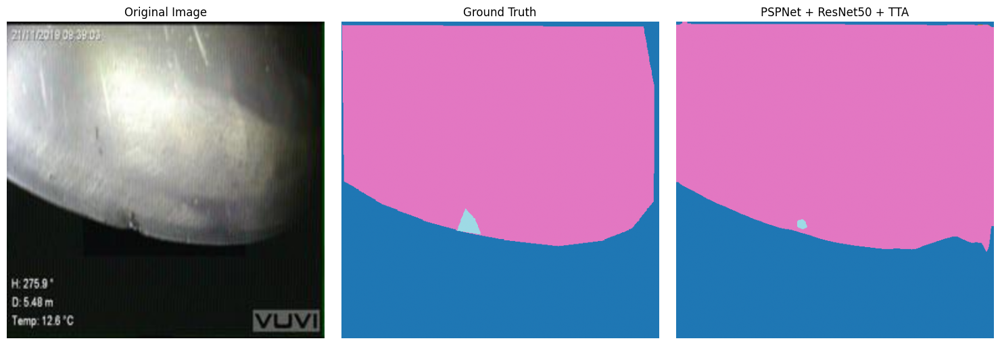

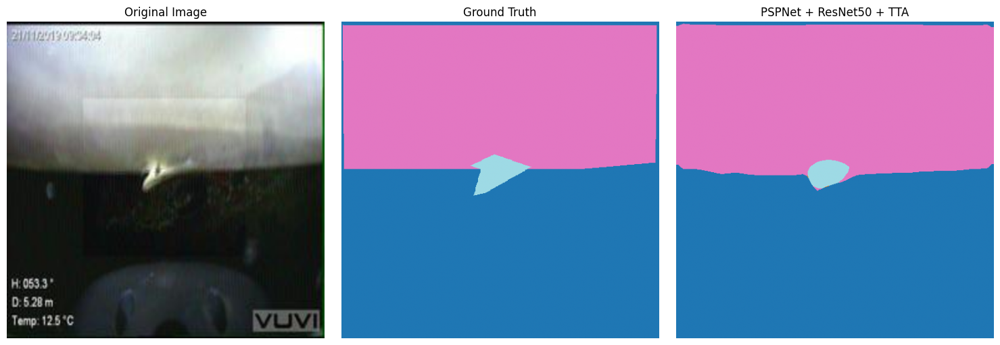

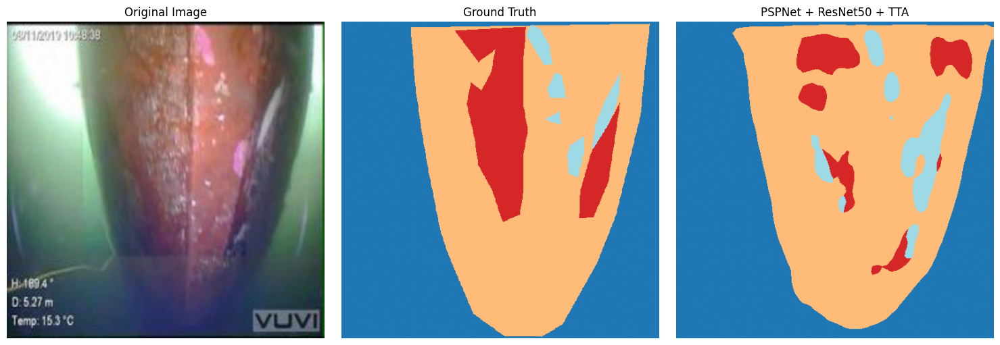

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load champion checkpoint
checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_finetuned_best.pth"

model.load_state_dict(
    torch.load(checkpoint_path, map_location=device)
)

model = model.to(device)
model.eval()

# Get one test batch
images, masks = next(iter(test_loader))

images_gpu = images.to(device)

# TTA prediction
with torch.no_grad():

    # Original
    output1, _ = model(images_gpu)
    prob1 = torch.softmax(output1, dim=1)

    # Horizontal flip
    flipped = torch.flip(images_gpu, dims=[3])

    output2, _ = model(flipped)
    prob2 = torch.softmax(output2, dim=1)

    # Flip prediction back
    prob2 = torch.flip(prob2, dims=[3])

    # Average
    final_prob = (prob1 + prob2) / 2

    predictions = torch.argmax(
        final_prob,
        dim=1
    )

# Visualize first 3 test images
for i in range(min(3, len(images))):

    image = images[i].permute(1, 2, 0).numpy()
    true_mask = masks[i].numpy()
    predicted_mask = predictions[i].cpu().numpy()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap="tab20")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(predicted_mask, cmap="tab20")
    plt.title("PSPNet + ResNet50 + TTA")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.0 MB/s eta 0:00:00


In [ ]:
import segmentation_models_pytorch as smp

# Create U-Net + MobileNetV2
model = smp.Unet(
    encoder_name="mobilenet_v2",
    encoder_weights=None,
    in_channels=3,
    classes=11
)

model = model.to(device)

# Load the improved U-Net checkpoint
unet_checkpoint = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/unet_mobilenetv2_improved_best.pth"

model.load_state_dict(
    torch.load(unet_checkpoint, map_location=device)
)

model.eval()

print("U-Net + MobileNetV2 checkpoint loaded successfully!")

U-Net + MobileNetV2 checkpoint loaded successfully!


In [ ]:
# Load U-Net + MobileNetV2 improved checkpoint

unet_checkpoint = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/unet_mobilenetv2_improved_best.pth"

model.load_state_dict(
    torch.load(unet_checkpoint, map_location=device)
)

model = model.to(device)
model.eval()

print("U-Net + MobileNetV2 checkpoint loaded!")


U-Net + MobileNetV2 checkpoint loaded!


In [ ]:
import torch
import torch.nn.functional as F

model.eval()

total_correct = 0
total_pixels = 0

intersection = torch.zeros(11, dtype=torch.float64)
union = torch.zeros(11, dtype=torch.float64)

dice_intersection = torch.zeros(11, dtype=torch.float64)
dice_total = torch.zeros(11, dtype=torch.float64)


with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        # Original prediction
        output1 = model(images)
        prob1 = F.softmax(output1, dim=1)

        # Horizontal flip prediction
        flipped = torch.flip(images, dims=[3])

        output2 = model(flipped)
        prob2 = F.softmax(output2, dim=1)

        # Flip prediction back
        prob2 = torch.flip(prob2, dims=[3])

        # Average original + flipped predictions
        probs = (prob1 + prob2) / 2

        predictions = torch.argmax(probs, dim=1)

        total_correct += (
            predictions == masks
        ).sum().item()

        total_pixels += masks.numel()

        for class_id in range(11):

            pred_class = predictions == class_id
            true_class = masks == class_id

            inter = (
                pred_class & true_class
            ).sum().item()

            union_pixels = (
                pred_class | true_class
            ).sum().item()

            intersection[class_id] += inter
            union[class_id] += union_pixels

            dice_intersection[class_id] += inter

            dice_total[class_id] += (
                pred_class.sum().item()
                + true_class.sum().item()
            )


pixel_accuracy = (
    total_correct / total_pixels
) * 100


iou = torch.zeros(11)

for i in range(11):

    if union[i] > 0:
        iou[i] = intersection[i] / union[i]


mean_iou = iou.mean().item() * 100


dice_scores = torch.zeros(11)

for i in range(11):

    if dice_total[i] > 0:
        dice_scores[i] = (
            2 * dice_intersection[i]
            / dice_total[i]
        )


mean_dice = dice_scores.mean().item() * 100


class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]


print("=" * 60)
print("U-NET + MOBILENETV2 + TTA — TEST RESULTS")
print("=" * 60)

print(f"Pixel Accuracy: {pixel_accuracy:.2f}%")
print(f"Mean IoU:        {mean_iou:.2f}%")
print(f"Mean Dice:       {mean_dice:.2f}%")

print("\nPer-class IoU:")
print("-" * 60)

for i in range(11):

    print(
        f"{class_names[i]:<20}: "
        f"{iou[i].item() * 100:.2f}%"
    )

print("=" * 60)

U-NET + MOBILENETV2 + TTA — TEST RESULTS
Pixel Accuracy: 82.91%
Mean IoU:        47.19%
Mean Dice:       58.42%

Per-class IoU:
------------------------------------------------------------
Void                : 75.48%
Ship Hull           : 77.98%
Marine Growth       : 50.87%
Anode               : 57.30%
Overboard Valve     : 54.71%
Propeller           : 76.04%
Paint Peel          : 24.38%
Bilge Keel          : 34.35%
Defect              : 0.00%
Corrosion           : 0.17%
Sea Chest Grating   : 67.85%


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class_weights = torch.tensor([
    0.5,   # Void
    1.0,   # Ship Hull
    1.5,   # Marine Growth
    3.0,   # Anode
    2.5,   # Overboard Valve
    1.5,   # Propeller
    2.5,   # Paint Peel
    2.5,   # Bilge Keel
    5.0,   # Defect
    4.0,   # Corrosion
    1.5    # Sea Chest Grating
], dtype=torch.float32).to(device)

print("Rare-class weights ready!")
print(class_weights)

Rare-class weights ready!
tensor([0.5000, 1.0000, 1.5000, 3.0000, 2.5000, 1.5000, 2.5000, 2.5000, 5.0000,
        4.0000, 1.5000], device='cuda:0')


In [ ]:
import segmentation_models_pytorch as smp
import torch

model = smp.Unet(
    encoder_name="mobilenet_v2",
    encoder_weights=None,
    in_channels=3,
    classes=11
).to(device)

checkpoint_path = (
    "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/"
    "LIACi_checkpoints/unet_mobilenetv2_improved_best.pth"
)

model.load_state_dict(torch.load(checkpoint_path, map_location=device))

print("Best U-Net checkpoint loaded!")

Best U-Net checkpoint loaded!


In [ ]:
class FocalLoss(nn.Module):

    def __init__(self, alpha=1.0, gamma=2.0, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight

    def forward(self, inputs, targets):

        ce_loss = F.cross_entropy(
            inputs,
            targets,
            weight=self.weight,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)

        focal_loss = self.alpha * (
            (1 - pt) ** self.gamma
        ) * ce_loss

        return focal_loss.mean()


class WeightedDiceLoss(nn.Module):

    def __init__(self, weights):
        super().__init__()
        self.weights = weights

    def forward(self, inputs, targets):

        probs = F.softmax(inputs, dim=1)

        total_loss = 0.0

        for class_id in range(11):

            pred = probs[:, class_id]
            target = (targets == class_id).float()

            intersection = (pred * target).sum()
            denominator = pred.sum() + target.sum()

            dice = (
                (2 * intersection + 1e-6)
                / (denominator + 1e-6)
            )

            total_loss += self.weights[class_id] * (1 - dice)

        return total_loss / self.weights.sum()


focal_loss = FocalLoss(
    alpha=1.0,
    gamma=2.0,
    weight=class_weights
)

dice_loss = WeightedDiceLoss(class_weights)

print("Rare-class Focal + Dice loss ready!")

Rare-class Focal + Dice loss ready!


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=1e-4
)

num_epochs = 20
patience = 5

best_val_loss = float("inf")
patience_counter = 0

checkpoint_path = (
    "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/"
    "LIACi_checkpoints/unet_mobilenetv2_rare_best.pth"
)

print("Optimizer and training settings ready!")
print("Learning rate:", 1e-5)
print("Epochs:", num_epochs)
print("Early stopping patience:", patience)

Optimizer and training settings ready!
Learning rate: 1e-05
Epochs: 20
Early stopping patience: 5


In [ ]:
for epoch in range(num_epochs):

    model.train()

    train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss_focal = focal_loss(outputs, masks)
        loss_dice = dice_loss(outputs, masks)

        loss = 0.5 * loss_focal + 0.5 * loss_dice

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    # Validation
    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss_focal = focal_loss(outputs, masks)
            loss_dice = dice_loss(outputs, masks)

            loss = 0.5 * loss_focal + 0.5 * loss_dice

            val_loss += loss.item()

    val_loss /= len(val_loader)


    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"- Train Loss: {train_loss:.4f} "
        f"- Val Loss: {val_loss:.4f}"
    )


    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            checkpoint_path
        )

        print("  ✓ Best model saved")

    else:

        patience_counter += 1

        print(
            f"  No improvement "
            f"({patience_counter}/{patience})"
        )

        if patience_counter >= patience:

            print("Early stopping!")
            break


print("\nTraining completed!")
print("Best validation loss:", best_val_loss)
print("Checkpoint:", checkpoint_path)

Epoch 1/20 - Train Loss: 0.6017 - Val Loss: 0.7095
  ✓ Best model saved
Epoch 2/20 - Train Loss: 0.5823 - Val Loss: 0.7094
  ✓ Best model saved
Epoch 3/20 - Train Loss: 0.5702 - Val Loss: 0.7177
  No improvement (1/5)
Epoch 4/20 - Train Loss: 0.5602 - Val Loss: 0.7153
  No improvement (2/5)
Epoch 5/20 - Train Loss: 0.5553 - Val Loss: 0.7094
  ✓ Best model saved
Epoch 6/20 - Train Loss: 0.5515 - Val Loss: 0.7111
  No improvement (1/5)
Epoch 7/20 - Train Loss: 0.5490 - Val Loss: 0.7041
  ✓ Best model saved
Epoch 8/20 - Train Loss: 0.5441 - Val Loss: 0.7096
  No improvement (1/5)
Epoch 9/20 - Train Loss: 0.5343 - Val Loss: 0.7098
  No improvement (2/5)
Epoch 10/20 - Train Loss: 0.5309 - Val Loss: 0.7045
  No improvement (3/5)
Epoch 11/20 - Train Loss: 0.5286 - Val Loss: 0.7181
  No improvement (4/5)
Epoch 12/20 - Train Loss: 0.5140 - Val Loss: 0.7104
  No improvement (5/5)
Early stopping!

Training completed!
Best validation loss: 0.7040638327598572
Checkpoint: /content/drive/MyDrive/LIAC

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q segmentation-models-pytorch

import os
import cv2
import torch
import segmentation_models_pytorch as smp

from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.9 MB/s eta 0:00:00
Device: cuda


In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader

PROCESSED_DIR = (
    "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/"
    "LIACi_processed"
)


class LIACiDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))


    def __len__(self):
        return len(self.images)


    def __getitem__(self, idx):

        image_path = os.path.join(
            self.image_dir,
            self.images[idx]
        )

        mask_path = os.path.join(
            self.mask_dir,
            self.masks[idx]
        )

        image = cv2.imread(image_path)
        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1) / 255.0

        mask = torch.tensor(
            mask,
            dtype=torch.long
        )

        return image, mask


test_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/test",
    PROCESSED_DIR + "/gtFine/test"
)


test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)


print("Test dataset ready!")
print("Test images:", len(test_dataset))
print("Test batches:", len(test_loader))

Test dataset ready!
Test images: 57
Test batches: 15


In [ ]:
model = smp.Unet(
    encoder_name="mobilenet_v2",
    encoder_weights=None,
    in_channels=3,
    classes=11
).to(device)


checkpoint_path = (
    "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/"
    "LIACi_checkpoints/unet_mobilenetv2_rare_best.pth"
)


model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=device
    )
)

model.eval()

print("Rare-class U-Net checkpoint loaded!")

Rare-class U-Net checkpoint loaded!


In [ ]:
model.eval()

total_correct = 0
total_pixels = 0

intersection = torch.zeros(11, dtype=torch.float64)
union = torch.zeros(11, dtype=torch.float64)

dice_intersection = torch.zeros(11, dtype=torch.float64)
dice_total = torch.zeros(11, dtype=torch.float64)


with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        total_correct += (
            predictions == masks
        ).sum().item()

        total_pixels += masks.numel()

        for class_id in range(11):

            pred_class = predictions == class_id
            true_class = masks == class_id

            inter = (
                pred_class & true_class
            ).sum().item()

            union_pixels = (
                pred_class | true_class
            ).sum().item()

            intersection[class_id] += inter
            union[class_id] += union_pixels

            dice_intersection[class_id] += inter

            dice_total[class_id] += (
                pred_class.sum().item()
                + true_class.sum().item()
            )


pixel_accuracy = (
    total_correct / total_pixels
) * 100


iou = torch.zeros(11)

for i in range(11):

    if union[i] > 0:
        iou[i] = intersection[i] / union[i]


mean_iou = iou.mean().item() * 100


dice_scores = torch.zeros(11)

for i in range(11):

    if dice_total[i] > 0:
        dice_scores[i] = (
            2 * dice_intersection[i]
            / dice_total[i]
        )


mean_dice = dice_scores.mean().item() * 100


class_names = [
    "Void",
    "Ship Hull",
    "Marine Growth",
    "Anode",
    "Overboard Valve",
    "Propeller",
    "Paint Peel",
    "Bilge Keel",
    "Defect",
    "Corrosion",
    "Sea Chest Grating"
]


print("=" * 60)
print("U-NET + MOBILENETV2 + RARE CLASS — TEST RESULTS")
print("=" * 60)

print(f"Pixel Accuracy: {pixel_accuracy:.2f}%")
print(f"Mean IoU:        {mean_iou:.2f}%")
print(f"Mean Dice:       {mean_dice:.2f}%")

print("\nPer-class IoU:")
print("-" * 60)

for i in range(11):

    print(
        f"{class_names[i]:<20}: "
        f"{iou[i].item() * 100:.2f}%"
    )

print("=" * 60)

U-NET + MOBILENETV2 + RARE CLASS — TEST RESULTS
Pixel Accuracy: 79.71%
Mean IoU:        45.67%
Mean Dice:       58.37%

Per-class IoU:
------------------------------------------------------------
Void                : 65.08%
Ship Hull           : 74.86%
Marine Growth       : 50.72%
Anode               : 50.24%
Overboard Valve     : 56.41%
Propeller           : 72.41%
Paint Peel          : 27.80%
Bilge Keel          : 23.88%
Defect              : 0.00%
Corrosion           : 14.55%
Sea Chest Grating   : 66.39%


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50


class PyramidPooling(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.pool1 = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool2 = nn.Sequential(
            nn.AdaptiveAvgPool2d(2),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool3 = nn.Sequential(
            nn.AdaptiveAvgPool2d(3),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool6 = nn.Sequential(
            nn.AdaptiveAvgPool2d(6),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels + 4 * out_channels,
                out_channels,
                1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )

    def forward(self, x):

        h, w = x.shape[2], x.shape[3]

        p1 = F.interpolate(
            self.pool1(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p2 = F.interpolate(
            self.pool2(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p3 = F.interpolate(
            self.pool3(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p6 = F.interpolate(
            self.pool6(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat(
            [x, p1, p2, p3, p6],
            dim=1
        )

        return self.conv(x)


class PSPNetResNet50(nn.Module):

    def __init__(self, num_classes=11):

        super().__init__()

        backbone = resnet50(
            weights=None,
            replace_stride_with_dilation=[
                False,
                True,
                True
            ]
        )

        self.layer0 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool
        )

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.psp = PyramidPooling(
            in_channels=2048,
            out_channels=512
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(
                512,
                256,
                3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Dropout2d(0.1),

            nn.Conv2d(
                256,
                256,
                3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Dropout2d(0.1),

            nn.Conv2d(
                256,
                num_classes,
                1
            )
        )

        self.auxiliary = nn.Sequential(
            nn.Conv2d(
                1024,
                256,
                3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Dropout2d(0.1),

            nn.Conv2d(
                256,
                num_classes,
                1
            )
        )

    def forward(self, x):

        input_h, input_w = x.shape[2], x.shape[3]

        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)

        x_aux = self.layer3(x)

        x = self.layer4(x_aux)

        x = self.psp(x)

        x = self.decoder(x)

        x = F.interpolate(
            x,
            size=(input_h, input_w),
            mode="bilinear",
            align_corners=False
        )

        aux = self.auxiliary(x_aux)

        aux = F.interpolate(
            aux,
            size=(input_h, input_w),
            mode="bilinear",
            align_corners=False
        )

        return x, aux


print("PSPNet model class ready!")

PSPNet model class ready!


In [ ]:
import os

base_path = "/content/drive/MyDrive"

for root, dirs, files in os.walk(base_path):
    for file in files:
        if "pspnet" in file.lower() and file.endswith(".pth"):
            print(os.path.join(root, file))


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if "pspnet" in file.lower() and file.endswith(".pth"):
            print(os.path.join(root, file))

In [ ]:
import os

print("Searching for PSPNet checkpoints...\n")

for root, dirs, files in os.walk("/content/drive"):
    for file in files:
        if "psp" in file.lower() and file.endswith(".pth"):
            print(os.path.join(root, file))


Searching for PSPNet checkpoints...



In [ ]:
print("model_pspnet exists:", "model_pspnet" in globals())

if "model_pspnet" in globals():
    print("PSPNet model is still available in memory.")
else:
    print("PSPNet model is NOT available in memory.")

model_pspnet exists: True
PSPNet model is still available in memory.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

print("Drive mounted!")

Mounted at /content/drive
Drive mounted!


In [ ]:
import os

print("MyDrive contents:\n")

for item in os.listdir("/content/drive/MyDrive"):
    print(item)


MyDrive contents:

Classroom
paper (1).docx
infosys certificate - Copy.pdf
thaya Infosys certificate.pdf
Shruthi_dsa_certificate.pdf.pdf
DOC-20250907-WA0010..pdf
DOC-20250907-WA0012..pdf
DOC-20250907-WA0013..pdf
DOC-20250907-WA0016. (1).pdf
DOC-20250907-WA0016..pdf
DOC-20250907-WA0018..pdf
DOC-20250907-WA0019..pdf
DOC-20250907-WA0020..pdf
DOC-20250907-WA0021..pdf
DOC-20250907-WA0022..pdf
DOC-20250907-WA0023..pdf
DOC-20250907-WA0024..pdf
fee receipt sem 4.pdf
raw_event_data.gsheet
Library file data.gsheet
Data Analysis Report – Library Borrowing Dataset.gdoc
Colab Notebooks
Library Data.gsheet
Student_academic_feedback.csv.gsheet
student_emotion_feedback.csv.gsheet
CISCO CERTIFICATE.pdf
Aadhaar card proof_compressed.pdf
ChatGPT Image Jun 18, 2026, 11_15_28 AM.jpeg
Prevention of Sexual harassment training.pdf
Information Security and Data Privacy training .pdf
Prevention of Insider Trading Training .pdf
Enterprise Risk Management 2.0.pdf
Code of Business Ethics and Conduct Training.pdf
E

In [ ]:
import os

base = "/content/drive/MyDrive/LIACI FINAL"

print("LIACI FINAL contents:\n")

for item in os.listdir(base):
    print(item)

LIACI FINAL contents:

PEP_SEG_DATA


In [ ]:
import os

base = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA"

print("PEP_SEG_DATA contents:\n")

for item in os.listdir(base):
    print(item)

PEP_SEG_DATA contents:

LIACi_dataset_pretty
LIACi_checkpoints
LIACi_processed
LIACi_checkpoints_run2
DeepLabV3Plus_Xception_Final
Mamba-Unet Model
MambaSeg Model


In [ ]:
import os

base = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA"

for folder in ["LIACi_checkpoints", "LIACi_checkpoints_run2"]:

    path = os.path.join(base, folder)

    print("\n==============================")
    print(folder)
    print("==============================")

    for file in os.listdir(path):
        print(file)


LIACi_checkpoints
deeplabv3plus_xception_baseline_epoch50.pth
latest.pth
best.pth
unet_mobilenetv2_best.pth
unet_mobilenetv2_improved_best.pth
pspnet_resnet50_best.pth
pspnet_resnet50_finetuned_best.pth
pspnet_resnet50_tta_aware_best.pth
pspnet_resnet50_lovasz_dice_best.pth
pspnet_resnet50_rare_best.pth
pspnet_resnet50_clahe_best.pth
unet_mobilenetv2_rare_best.pth

LIACi_checkpoints_run2
best_epoch_01_miou_0.3235.pth
best_epoch_02_miou_0.3860.pth
best_epoch_03_miou_0.4017.pth
best_epoch_04_miou_0.4302.pth
best_epoch_05_miou_0.4418.pth
best_epoch_06_miou_0.4498.pth
best_epoch_08_miou_0.4664.pth
best_epoch_09_miou_0.4720.pth
best_epoch_11_miou_0.4730.pth
best_epoch_12_miou_0.4996.pth
best_epoch_13_miou_0.5041.pth
best_epoch_14_miou_0.5185.pth
best_epoch_15_miou_0.5276.pth
best_epoch_19_miou_0.5381.pth
best_epoch_22_miou_0.5391.pth
best_epoch_24_miou_0.5405.pth
best_epoch_25_miou_0.5487.pth
best_epoch_32_miou_0.5499.pth
best_epoch_38_miou_0.5508.pth
latest.pth


In [ ]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

checkpoint_path = (
    "/content/drive/MyDrive/LIACI FINAL/"
    "PEP_SEG_DATA/LIACi_checkpoints/"
    "pspnet_resnet50_finetuned_best.pth"
)

model_pspnet = PSPNetResNet50(
    num_classes=11
).to(device)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model_pspnet.load_state_dict(checkpoint)

model_pspnet.eval()

print("PSPNet Focal + Dice checkpoint loaded!")
print("Device:", device)

PSPNet Focal + Dice checkpoint loaded!
Device: cuda


In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset

PROCESSED_DIR = (
    "/content/drive/MyDrive/LIACI FINAL/"
    "PEP_SEG_DATA/LIACi_processed"
)

class LIACiDataset(Dataset):

    def __init__(self, image_dir, mask_dir):
        self.image_dir = image_dir
        self.mask_dir = mask_dir

        self.images = sorted(os.listdir(image_dir))
        self.masks = sorted(os.listdir(mask_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = os.path.join(
            self.image_dir,
            self.images[idx]
        )

        mask_path = os.path.join(
            self.mask_dir,
            self.masks[idx]
        )

        image = cv2.imread(image_path)
        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        mask = cv2.imread(
            mask_path,
            cv2.IMREAD_GRAYSCALE
        )

        image = torch.tensor(
            image,
            dtype=torch.float32
        ).permute(2, 0, 1) / 255.0

        mask = torch.tensor(
            mask,
            dtype=torch.long
        )

        return image, mask


test_dataset = LIACiDataset(
    PROCESSED_DIR + "/leftImg8bit/test",
    PROCESSED_DIR + "/gtFine/test"
)

print("Test dataset ready!")
print("Test images:", len(test_dataset))

Test dataset ready!
Test images: 57


In [ ]:
# Take one test image

image, true_mask = test_dataset[0]

img_tensor = image.unsqueeze(0).to(device)

model_pspnet.eval()

# Original prediction
with torch.no_grad():
    output_original, _ = model_pspnet(img_tensor)

# Horizontally flipped prediction
flipped_input = torch.flip(
    img_tensor,
    dims=[3]
)

with torch.no_grad():
    output_flipped, _ = model_pspnet(flipped_input)

# Flip prediction back
output_flipped = torch.flip(
    output_flipped,
    dims=[3]
)

# TTA: average original + flipped predictions
tta_output = (
    torch.softmax(output_original, dim=1)
    +
    torch.softmax(output_flipped, dim=1)
) / 2

# Final segmentation
tta_prediction = torch.argmax(
    tta_output,
    dim=1
)[0]

print("TTA prediction generated!")
print("Image shape:", img_tensor.shape)
print("Prediction shape:", tta_prediction.shape)
print("Predicted classes:", torch.unique(tta_prediction).tolist())

TTA prediction generated!
Image shape: torch.Size([1, 3, 512, 512])
Prediction shape: torch.Size([512, 512])
Predicted classes: [0, 1, 5, 8]


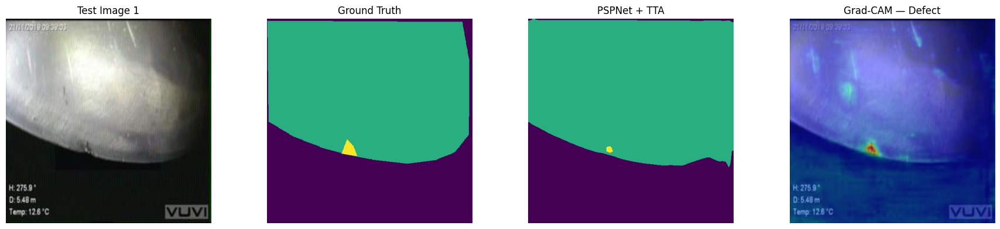

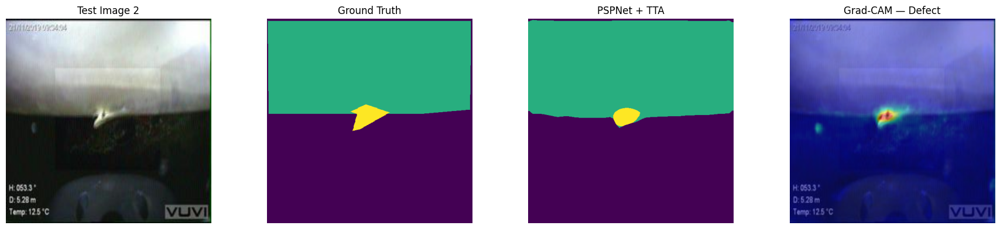

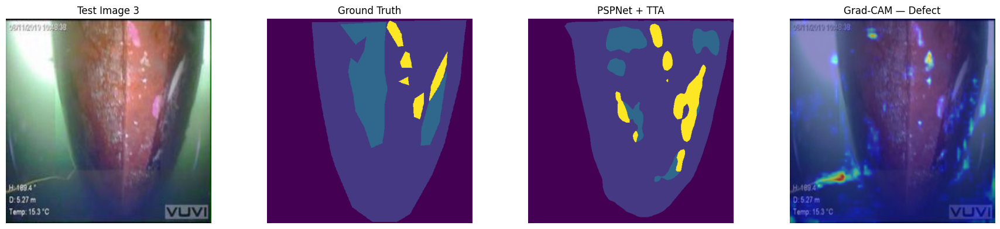

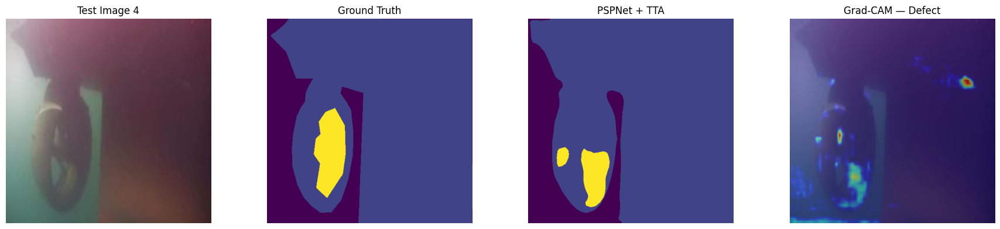

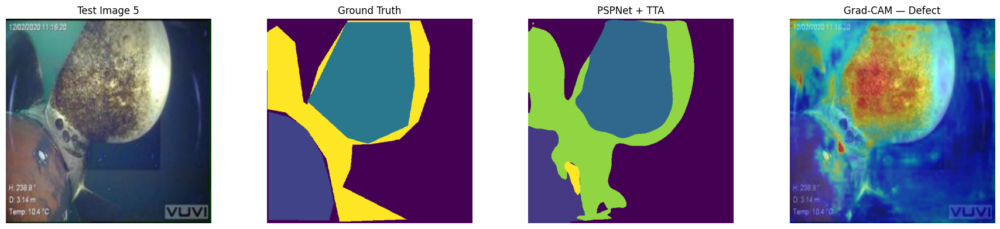

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import torch

model_pspnet.eval()

for idx in range(5):

    # -----------------------------------------
    # Load test image
    # -----------------------------------------

    image, true_mask = test_dataset[idx]

    img_tensor = image.unsqueeze(0).to(device)


    # -----------------------------------------
    # TTA prediction
    # -----------------------------------------

    with torch.no_grad():

        output_original, _ = model_pspnet(
            img_tensor
        )

        flipped_input = torch.flip(
            img_tensor,
            dims=[3]
        )

        output_flipped, _ = model_pspnet(
            flipped_input
        )

        output_flipped = torch.flip(
            output_flipped,
            dims=[3]
        )

        tta_output = (
            torch.softmax(
                output_original,
                dim=1
            )
            +
            torch.softmax(
                output_flipped,
                dim=1
            )
        ) / 2

        tta_prediction = torch.argmax(
            tta_output,
            dim=1
        )[0]


    # -----------------------------------------
    # Grad-CAM for Defect class
    # -----------------------------------------

    heatmap = grad_cam.generate_heatmap(
        img_tensor,
        target_class_idx=8
    )


    # -----------------------------------------
    # Convert to NumPy
    # -----------------------------------------

    image_np = image.permute(
        1, 2, 0
    ).cpu().numpy()

    true_mask_np = true_mask.cpu().numpy()

    prediction_np = tta_prediction.cpu().numpy()


    # -----------------------------------------
    # Grad-CAM overlay
    # -----------------------------------------

    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap),
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    overlay = (
        0.55 * image_np
        +
        0.45 * (heatmap_color / 255.0)
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )


    # -----------------------------------------
    # Display
    # -----------------------------------------

    plt.figure(figsize=(18, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(image_np)
    plt.title(f"Test Image {idx + 1}")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(true_mask_np)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(prediction_np)
    plt.title("PSPNet + TTA")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay)
    plt.title("Grad-CAM — Defect")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [43]:
import torch
import torch.nn.functional as F
import numpy as np

class PSPNetGradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(
            self.save_activation
        )

        self.target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(
        self,
        input_tensor,
        target_class_idx,
        prediction_mask
    ):

        self.model.eval()
        self.model.zero_grad()

        # PSPNet returns main output + auxiliary output
        main_output, _ = self.model(input_tensor)

        # Select pixels predicted as this class
        class_mask = (
            prediction_mask == target_class_idx
        ).float()

        class_mask = class_mask.unsqueeze(0).unsqueeze(0)

        # Match output size
        class_mask = F.interpolate(
            class_mask,
            size=main_output.shape[2:],
            mode="nearest"
        )

        # Focus Grad-CAM only on the predicted
        # pixels belonging to this class
        target_score = (
            main_output[
                0,
                target_class_idx
            ].unsqueeze(0).unsqueeze(0)
            * class_mask
        ).sum()

        target_score.backward()

        # Grad-CAM channel weights
        weights = torch.mean(
            self.gradients,
            dim=(2, 3),
            keepdim=True
        )

        cam = torch.sum(
            weights * self.activations,
            dim=1,
            keepdim=True
        )

        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=input_tensor.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().detach().cpu().numpy()

        # Normalize 0-1
        cam_min = cam.min()
        cam_max = cam.max()

        if cam_max - cam_min > 1e-8:
            cam = (
                cam - cam_min
            ) / (
                cam_max - cam_min
            )
        else:
            cam = np.zeros_like(cam)

        return cam


# -----------------------------------------
# Create corrected Grad-CAM
# -----------------------------------------

grad_cam = PSPNetGradCAM(
    model_pspnet,
    target_layer=model_pspnet.layer4[-1].conv3
)

print("Corrected Grad-CAM ready!")

Corrected Grad-CAM ready!


In [ ]:
import torch
import torch.nn.functional as F
import numpy as np


def generate_multiclass_gradcam(
    model,
    input_tensor,
    prediction,
    grad_cam
):

    # Classes actually predicted in this image
    predicted_classes = torch.unique(
        prediction
    ).cpu().tolist()

    # Remove Void
    predicted_classes = [
        c for c in predicted_classes
        if c != 0
    ]

    heatmaps = {}

    print("Predicted classes:")

    for class_idx in predicted_classes:

        # Check that this class has enough pixels
        class_pixels = (
            prediction == class_idx
        ).sum().item()

        if class_pixels == 0:
            continue

        # Generate class-specific Grad-CAM
        heatmap = grad_cam.generate_heatmap(
            input_tensor,
            target_class_idx=class_idx
        )

        heatmaps[class_idx] = heatmap

        print(
            f"Class {class_idx}: "
            f"{class_pixels} pixels"
        )

    return heatmaps


# Generate multi-class XAI
multiclass_heatmaps = generate_multiclass_gradcam(
    model_pspnet,
    img_tensor,
    tta_prediction,
    grad_cam
)

print("\nMulti-class Grad-CAM generated!")
print(
    "Number of class explanations:",
    len(multiclass_heatmaps)
)

Predicted classes:
Class 1: 22689 pixels
Class 2: 55803 pixels
Class 5: 67267 pixels
Class 6: 1759 pixels

Multi-class Grad-CAM generated!
Number of class explanations: 4


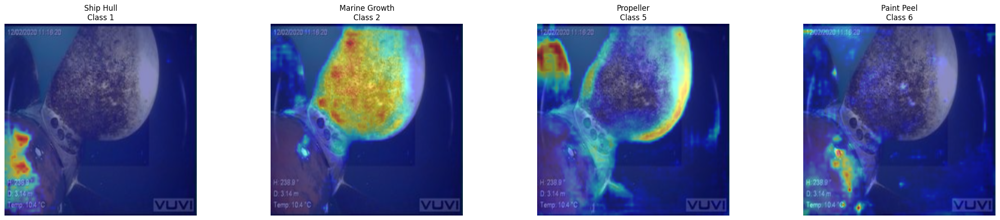

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Class names
class_names = {
    1: "Ship Hull",
    2: "Marine Growth",
    3: "Anode",
    4: "Overboard Valve",
    5: "Propeller",
    6: "Paint Peel",
    7: "Bilge Keel",
    8: "Defect",
    9: "Corrosion",
    10: "Sea Chest Grating"
}

# Original image
image_np = image.permute(
    1, 2, 0
).cpu().numpy()

# Create one figure for all class explanations
num_classes = len(multiclass_heatmaps)

plt.figure(
    figsize=(6 * num_classes, 5)
)

for i, (class_idx, heatmap) in enumerate(
    multiclass_heatmaps.items()
):

    # Convert heatmap to color
    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap),
        cv2.COLORMAP_JET
    )

    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )

    # Overlay on original image
    overlay = (
        0.55 * image_np
        +
        0.45 * (heatmap_color / 255.0)
    )

    overlay = np.clip(
        overlay,
        0,
        1
    )

    plt.subplot(
        1,
        num_classes,
        i + 1
    )

    plt.imshow(overlay)

    plt.title(
        f"{class_names.get(class_idx, 'Unknown')}\n"
        f"Class {class_idx}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

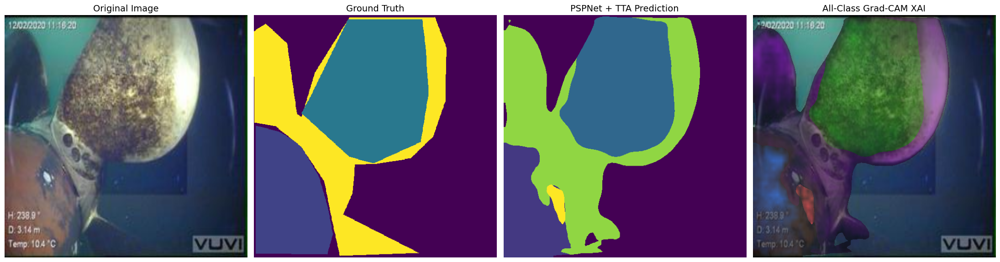


All-class XAI analysis:
Class  1 - Ship Hull            : 22689 predicted pixels
Class  2 - Marine Growth        : 55803 predicted pixels
Class  3 - Anode                : 0 predicted pixels
Class  4 - Overboard Valve      : 0 predicted pixels
Class  5 - Propeller            : 67267 predicted pixels
Class  6 - Paint Peel           : 1759 predicted pixels
Class  7 - Bilge Keel           : 0 predicted pixels
Class  8 - Defect               : 0 predicted pixels
Class  9 - Corrosion            : 0 predicted pixels
Class 10 - Sea Chest Grating    : 0 predicted pixels


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch

# -----------------------------------------
# All LIACi classes
# -----------------------------------------

class_names = {
    0: "Void",
    1: "Ship Hull",
    2: "Marine Growth",
    3: "Anode",
    4: "Overboard Valve",
    5: "Propeller",
    6: "Paint Peel",
    7: "Bilge Keel",
    8: "Defect",
    9: "Corrosion",
    10: "Sea Chest Grating"
}


# -----------------------------------------
# Class colors
# -----------------------------------------
# Each class gets its own color

class_colors = {
    0: (0, 0, 0),
    1: (0, 102, 255),
    2: (0, 180, 0),
    3: (0, 220, 220),
    4: (0, 180, 180),
    5: (150, 0, 200),
    6: (255, 50, 50),
    7: (255, 165, 0),
    8: (255, 105, 180),
    9: (255, 220, 0),
    10: (255, 255, 255)
}


# -----------------------------------------
# Convert data to NumPy
# -----------------------------------------

image_np = image.permute(
    1, 2, 0
).cpu().numpy()

true_mask_np = true_mask.cpu().numpy()

prediction_np = tta_prediction.cpu().numpy()


# -----------------------------------------
# Create integrated XAI image
# -----------------------------------------

integrated_xai = image_np.copy()

# Store information about all classes
class_results = {}


# -----------------------------------------
# Generate Grad-CAM for ALL 11 classes
# -----------------------------------------

for class_idx in range(1, 11):

    # Pixels predicted as this class
    class_region = (
        prediction_np == class_idx
    )

    pixel_count = class_region.sum()

    # Generate Grad-CAM even if the class
    # is not present in the prediction
    heatmap = grad_cam.generate_heatmap(
        img_tensor,
        target_class_idx=class_idx
    )

    # Keep Grad-CAM only inside the
    # predicted region of this class
    masked_heatmap = (
        heatmap * class_region
    )

    class_results[class_idx] = {
        "pixels": int(pixel_count),
        "heatmap": heatmap,
        "masked_heatmap": masked_heatmap
    }


# -----------------------------------------
# Combine ALL class explanations
# -----------------------------------------

for class_idx in range(1, 11):

    class_region = (
        prediction_np == class_idx
    )

    if not np.any(class_region):
        continue

    heatmap = class_results[
        class_idx
    ]["masked_heatmap"]

    # Normalize only within this class
    values = heatmap[class_region]

    if values.max() > values.min():

        values = (
            values - values.min()
        ) / (
            values.max() - values.min()
        )

        heatmap[class_region] = values

    # Class-specific RGB color
    color = np.array(
        class_colors[class_idx],
        dtype=np.float32
    ) / 255.0

    # Blend color according to Grad-CAM intensity
    for channel in range(3):

        integrated_xai[..., channel] = np.where(
            class_region,
            (
                0.45 * integrated_xai[..., channel]
                +
                0.55 * color[channel] * heatmap
            ),
            integrated_xai[..., channel]
        )


integrated_xai = np.clip(
    integrated_xai,
    0,
    1
)


# -----------------------------------------
# Create ONE comparison image
# -----------------------------------------

fig, axes = plt.subplots(
    1,
    4,
    figsize=(22, 6)
)


# Original
axes[0].imshow(image_np)
axes[0].set_title(
    "Original Image",
    fontsize=14
)
axes[0].axis("off")


# Ground Truth
axes[1].imshow(true_mask_np)
axes[1].set_title(
    "Ground Truth",
    fontsize=14
)
axes[1].axis("off")


# PSPNet + TTA
axes[2].imshow(prediction_np)
axes[2].set_title(
    "PSPNet + TTA Prediction",
    fontsize=14
)
axes[2].axis("off")


# Integrated XAI
axes[3].imshow(integrated_xai)
axes[3].set_title(
    "All-Class Grad-CAM XAI",
    fontsize=14
)
axes[3].axis("off")


plt.tight_layout()
plt.show()


# -----------------------------------------
# Print ALL class results
# -----------------------------------------

print("\nAll-class XAI analysis:")

for class_idx in range(1, 11):

    pixel_count = class_results[
        class_idx
    ]["pixels"]

    print(
        f"Class {class_idx:2d} - "
        f"{class_names[class_idx]:20s} : "
        f"{pixel_count} predicted pixels"
    )

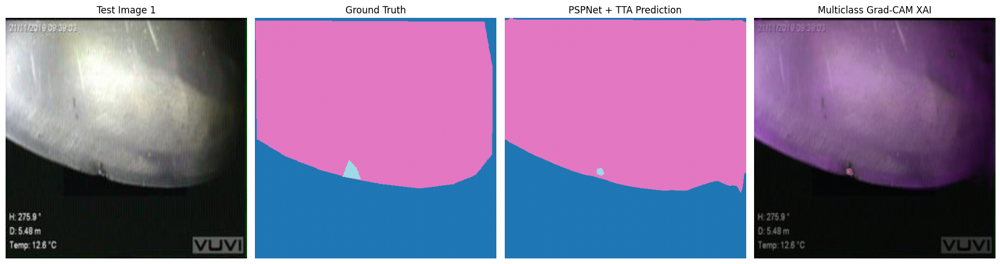


Test Image 1
----------------------------------------
Ship Hull: 10 pixels
Propeller: 170,110 pixels
Defect: 195 pixels


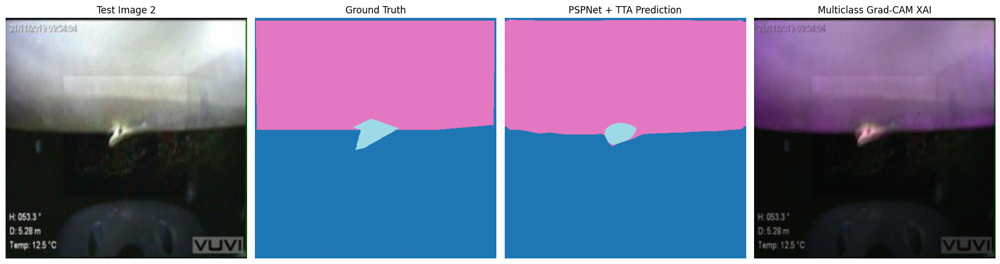


Test Image 2
----------------------------------------
Ship Hull: 9 pixels
Propeller: 120,824 pixels
Defect: 2,242 pixels


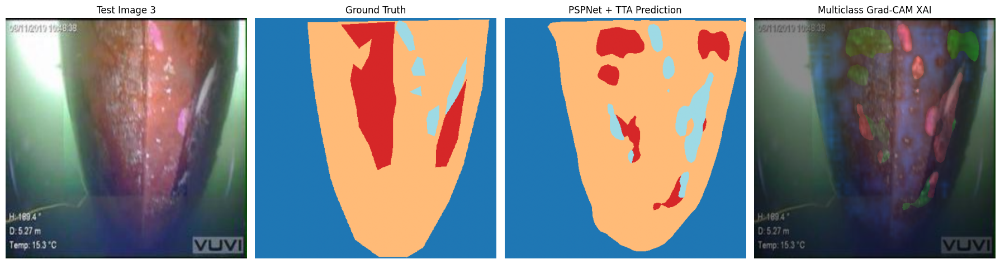


Test Image 3
----------------------------------------
Ship Hull: 121,316 pixels
Marine Growth: 13,533 pixels
Paint Peel: 11,053 pixels


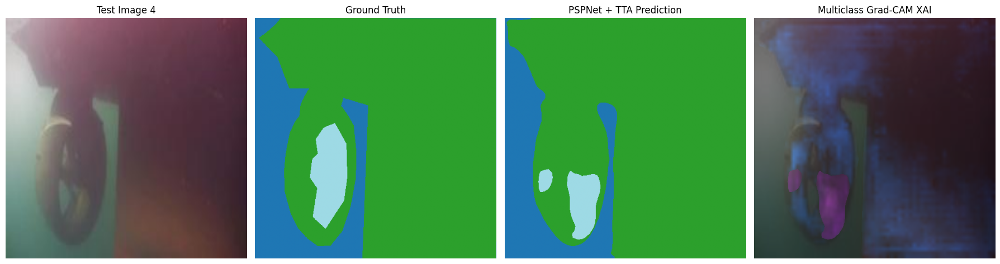


Test Image 4
----------------------------------------
Ship Hull: 209,658 pixels
Propeller: 8,558 pixels


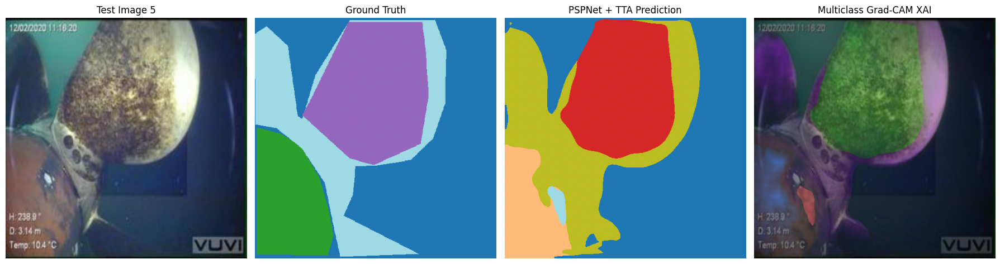


Test Image 5
----------------------------------------
Ship Hull: 22,689 pixels
Marine Growth: 55,803 pixels
Propeller: 67,267 pixels
Paint Peel: 1,759 pixels


In [ ]:
# Generate XAI results for 5 test images

import matplotlib.pyplot as plt
import numpy as np
import torch

model_pspnet.eval()

for idx in range(5):

    image, true_mask = test_dataset[idx]
    img_tensor = image.unsqueeze(0).to(device)

    # ---------- TTA prediction ----------
    with torch.no_grad():
        output_original, _ = model_pspnet(img_tensor)

        flipped_input = torch.flip(img_tensor, dims=[3])
        output_flipped, _ = model_pspnet(flipped_input)
        output_flipped = torch.flip(output_flipped, dims=[3])

        tta_output = (
            torch.softmax(output_original, dim=1)
            + torch.softmax(output_flipped, dim=1)
        ) / 2

        prediction = torch.argmax(tta_output, dim=1)[0]

    # ---------- Generate Grad-CAM for ALL classes ----------
    all_heatmaps = {}

    for class_idx in range(1, 11):

        heatmap = grad_cam.generate_heatmap(
            img_tensor,
            target_class_idx=class_idx
        )

        # Keep Grad-CAM only where this class is predicted
        class_region = (prediction.cpu().numpy() == class_idx)

        heatmap = heatmap * class_region
        all_heatmaps[class_idx] = heatmap

    # ---------- Create combined XAI image ----------
    image_np = image.permute(1, 2, 0).cpu().numpy()
    image_np = np.clip(image_np, 0, 1)

    xai_image = np.zeros_like(image_np)

    for class_idx in range(1, 11):

        heatmap = all_heatmaps[class_idx]

        # Normalize only if class exists
        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        color = np.array(class_colors[class_idx]) / 255.0

        # Add class color weighted by Grad-CAM activation
        for c in range(3):
            xai_image[:, :, c] += heatmap * color[c]

    xai_image = np.clip(xai_image, 0, 1)

    # Blend XAI with original image
    xai_overlay = (
        0.55 * image_np +
        0.45 * xai_image
    )

    # ---------- Display ----------
    plt.figure(figsize=(18, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(image_np)
    plt.title(f"Test Image {idx + 1}")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(true_mask.cpu().numpy(), cmap="tab20")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(prediction.cpu().numpy(), cmap="tab20")
    plt.title("PSPNet + TTA Prediction")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(xai_overlay)
    plt.title("Multiclass Grad-CAM XAI")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    # ---------- Print predicted classes ----------
    print(f"\nTest Image {idx + 1}")
    print("-" * 40)

    for class_idx in range(1, 11):
        pixels = (prediction == class_idx).sum().item()

        if pixels > 0:
            print(
                f"{class_names[class_idx]}: "
                f"{pixels:,} pixels"
            )

In [1]:
import torch

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu130
GPU available: True
GPU: Tesla T4


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

BASE_DIR = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA"

print(os.listdir(BASE_DIR))

['Segmentation in Marine growth.pdf', 'LIACi_dataset_pretty', 'LIACi_checkpoints', 'LIACi_processed', 'LIACi_checkpoints_run2', 'DeepLabV3Plus_Xception_Final', 'Mamba-Unet Model', 'MambaSeg Model']


In [8]:
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.0/268.0 kB 16.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.49.0, but you have google-auth 2.61.0 which is incompatible.


In [9]:
from google import genai

print("Gemini SDK ready!")

Gemini SDK ready!


In [14]:
from google.colab import userdata
from google import genai

api_key = userdata.get("LIACI_API_KEY")

client = genai.Client(api_key=api_key)

print("Gemini connected!")

Gemini connected!


In [16]:
from google import genai
from PIL import Image

image = Image.open(image_path)

response = client.models.generate_content(
    model="gemini-3.5-flash-lite",
    contents=[
        image,
        """
        Analyze this underwater ship image.

        Identify:
        1. The visible ship hull region
        2. Any visible marine growth, corrosion, paint peel, propeller,
           anode, valve, or other ship-hull components
        3. Any visible condition or defect

        Give a short inspection-oriented description.
        Do not assume a defect is present if it is not clearly visible.
        """
    ]
)

print(response.text)

Based on the provided underwater image of the ship hull:

1. **Ship Hull Region:** The visible area shows a section of the lower hull, painted with a reddish-orange anti-fouling or protective coating, positioned partially above the green-tinted waterline.

2. **Components:** A small rectangular sacrificial zinc anode is visible on the lower left portion of the hull surface. 

3. **Condition and Defect:** The hull surface shows some minor paint scuffing, chipping, or small spots of fouling (visible as light-colored marks scattered across the orange paint), but no major structural defects, severe corrosion, or heavy marine growth are clearly visible in this frame.


Image used: /content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_dataset_pretty/image_thumbs/image_0001.jpg
Image size: (256, 144)


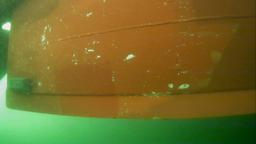

In [17]:
print("Image used:", image_path)
print("Image size:", image.size)

display(image)

In [19]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50


class PyramidPooling(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.pool1 = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool2 = nn.Sequential(
            nn.AdaptiveAvgPool2d(2),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool3 = nn.Sequential(
            nn.AdaptiveAvgPool2d(3),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.pool6 = nn.Sequential(
            nn.AdaptiveAvgPool2d(6),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels + 4 * out_channels,
                out_channels,
                1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1)
        )

    def forward(self, x):

        h, w = x.shape[2], x.shape[3]

        p1 = F.interpolate(
            self.pool1(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p2 = F.interpolate(
            self.pool2(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p3 = F.interpolate(
            self.pool3(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        p6 = F.interpolate(
            self.pool6(x),
            size=(h, w),
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat([x, p1, p2, p3, p6], dim=1)

        return self.conv(x)


class PSPNetResNet50(nn.Module):

    def __init__(self, num_classes=11):

        super().__init__()

        backbone = resnet50(
            weights=None,
            replace_stride_with_dilation=[False, True, True]
        )

        self.layer0 = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool
        )

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.psp = PyramidPooling(
            in_channels=2048,
            out_channels=512
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(512, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Dropout2d(0.1),

            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Dropout2d(0.1),

            nn.Conv2d(256, num_classes, 1)
        )

        self.auxiliary = nn.Sequential(
            nn.Conv2d(1024, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.Dropout2d(0.1),

            nn.Conv2d(256, num_classes, 1)
        )

    def forward(self, x):

        input_h, input_w = x.shape[2], x.shape[3]

        x = self.layer0(x)
        x = self.layer1(x)
        x = self.layer2(x)

        x_aux = self.layer3(x)

        x = self.layer4(x_aux)

        x = self.psp(x)

        x = self.decoder(x)

        x = F.interpolate(
            x,
            size=(input_h, input_w),
            mode="bilinear",
            align_corners=False
        )

        aux = self.auxiliary(x_aux)

        aux = F.interpolate(
            aux,
            size=(input_h, input_w),
            mode="bilinear",
            align_corners=False
        )

        return x, aux


print("PSPNet architecture ready!")

PSPNet architecture ready!


In [24]:
import torch

checkpoint_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_checkpoints/pspnet_resnet50_finetuned_best.pth"

model_pspnet = PSPNetResNet50(num_classes=11).to(device)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model_pspnet.load_state_dict(checkpoint)
model_pspnet.eval()

print("PSPNet loaded!")
print("Device:", device)

PSPNet loaded!
Device: cuda


In [25]:
import torch
import numpy as np

# Convert the current image to a tensor
img_array = np.array(image)

img_tensor = torch.tensor(
    img_array,
    dtype=torch.float32
).permute(2, 0, 1) / 255.0

img_tensor = img_tensor.unsqueeze(0).to(device)

# PSPNet prediction
model_pspnet.eval()

with torch.no_grad():
    output_original, _ = model_pspnet(img_tensor)

# Horizontal flip for TTA
flipped_input = torch.flip(img_tensor, dims=[3])

with torch.no_grad():
    output_flipped, _ = model_pspnet(flipped_input)

output_flipped = torch.flip(output_flipped, dims=[3])

# Average the two predictions
tta_output = (
    torch.softmax(output_original, dim=1)
    + torch.softmax(output_flipped, dim=1)
) / 2

prediction = torch.argmax(tta_output, dim=1)[0]

print("Prediction completed!")
print("Image:", image_path)
print("Predicted classes:", torch.unique(prediction).cpu().tolist())

Prediction completed!
Image: /content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_dataset_pretty/image_thumbs/image_0001.jpg
Predicted classes: [0, 1, 7]


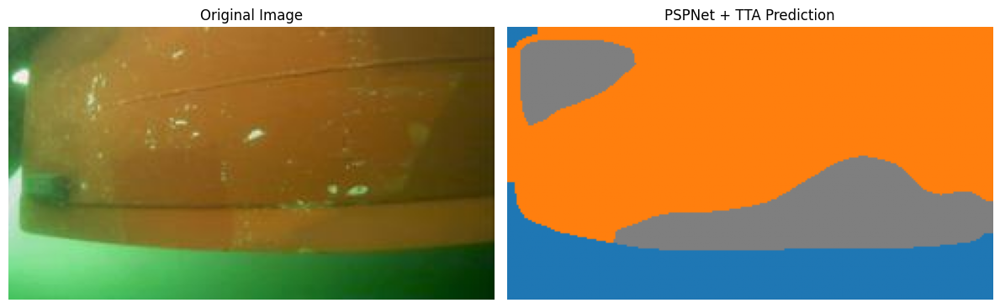

In [26]:
import matplotlib.pyplot as plt

prediction_np = prediction.cpu().numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(prediction_np, cmap="tab10", vmin=0, vmax=10)
plt.title("PSPNet + TTA Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
import torch
import torch.nn.functional as F


class PSPNetGradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, target_class_idx):

        self.model.eval()
        self.model.zero_grad()

        output, _ = self.model(input_tensor)

        target_score = output[0, target_class_idx].sum()

        target_score.backward()

        weights = torch.mean(
            self.gradients,
            dim=(2, 3),
            keepdim=True
        )

        cam = torch.sum(
            weights * self.activations,
            dim=1,
            keepdim=True
        )

        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=input_tensor.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().detach().cpu().numpy()

        cam = (
            cam - cam.min()
        ) / (
            cam.max() - cam.min() + 1e-8
        )

        return cam


grad_cam = PSPNetGradCAM(
    model_pspnet,
    target_layer=model_pspnet.psp.conv
)

print("Grad-CAM ready!")

Grad-CAM ready!


In [29]:
class_names = {
    0: "Void",
    1: "Ship Hull",
    2: "Marine Growth",
    3: "Anode",
    4: "Overboard Valve",
    5: "Propeller",
    6: "Paint Peel",
    7: "Bilge Keel",
    8: "Defect",
    9: "Corrosion",
    10: "Sea Chest Grating"
}

print("Class names ready!")

Class names ready!


In [30]:
# Generate Grad-CAM for all 11 classes automatically

all_heatmaps = {}

for class_idx in range(1, 11):

    heatmap = grad_cam.generate_heatmap(
        img_tensor,
        target_class_idx=class_idx
    )

    all_heatmaps[class_idx] = heatmap

    print(
        f"{class_idx} - {class_names[class_idx]} Grad-CAM generated"
    )

print("\nAll 10 semantic classes explained!")

1 - Ship Hull Grad-CAM generated
2 - Marine Growth Grad-CAM generated
3 - Anode Grad-CAM generated
4 - Overboard Valve Grad-CAM generated
5 - Propeller Grad-CAM generated
6 - Paint Peel Grad-CAM generated
7 - Bilge Keel Grad-CAM generated
8 - Defect Grad-CAM generated
9 - Corrosion Grad-CAM generated
10 - Sea Chest Grating Grad-CAM generated

All 10 semantic classes explained!


In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Colors for the 10 semantic classes
class_colors = {
    1: (255, 0, 0),        # Ship Hull
    2: (0, 255, 0),        # Marine Growth
    3: (0, 255, 255),      # Anode
    4: (64, 224, 208),     # Overboard Valve
    5: (128, 0, 128),      # Propeller
    6: (255, 0, 255),      # Paint Peel
    7: (255, 165, 0),      # Bilge Keel
    8: (255, 192, 203),    # Defect
    9: (255, 255, 0),      # Corrosion
    10: (255, 255, 255)    # Sea Chest Grating
}

image_np = np.array(image).astype(np.float32)

# Start with the original image
integrated_xai = image_np.copy()

for class_idx in range(1, 11):

    # Pixels predicted as this class
    class_mask = prediction.cpu().numpy() == class_idx

    # Current class Grad-CAM
    heatmap = all_heatmaps[class_idx]

    # Only use CAM inside the predicted region
    masked_heatmap = heatmap * class_mask

    # Class colour
    color = np.array(class_colors[class_idx], dtype=np.float32)

    # Blend only where this class is predicted
    alpha = 0.55 * masked_heatmap[..., None]

    integrated_xai = (
        integrated_xai * (1 - alpha)
        + color * alpha
    )

integrated_xai = np.clip(
    integrated_xai,
    0,
    255
).astype(np.uint8)

print("Integrated all-class XAI generated!")

Integrated all-class XAI generated!


In [33]:
# Automatic integrated Grad-CAM for predicted classes only

prediction_np = prediction.cpu().numpy()

# Find classes actually predicted by PSPNet
predicted_classes = np.unique(prediction_np)
predicted_classes = [
    int(c) for c in predicted_classes
    if c != 0
]

print("Predicted classes:")

for class_idx in predicted_classes:
    pixel_count = np.sum(prediction_np == class_idx)
    print(
        f"{class_idx} - {class_names[class_idx]} "
        f"({pixel_count} pixels)"
    )

# Generate Grad-CAM only for predicted classes
predicted_heatmaps = {}

for class_idx in predicted_classes:

    heatmap = grad_cam.generate_heatmap(
        img_tensor,
        target_class_idx=class_idx
    )

    predicted_heatmaps[class_idx] = heatmap

# Class colours
class_colors = {
    1: (255, 0, 0),
    2: (0, 255, 0),
    3: (0, 255, 255),
    4: (64, 224, 208),
    5: (128, 0, 128),
    6: (255, 0, 255),
    7: (255, 165, 0),
    8: (255, 192, 203),
    9: (255, 255, 0),
    10: (255, 255, 255)
}

image_np = np.array(image).astype(np.float32)

# Start with original image
integrated_xai = image_np.copy()

# Add explanations only for classes actually predicted
for class_idx in predicted_classes:

    class_mask = prediction_np == class_idx

    heatmap = predicted_heatmaps[class_idx]

    # Keep CAM only inside the predicted class region
    masked_heatmap = heatmap * class_mask

    color = np.array(
        class_colors[class_idx],
        dtype=np.float32
    )

    alpha = 0.55 * masked_heatmap[..., None]

    integrated_xai = (
        integrated_xai * (1 - alpha)
        + color * alpha
    )

integrated_xai = np.clip(
    integrated_xai,
    0,
    255
).astype(np.uint8)

print("\nIntegrated XAI generated!")
print("Classes explained:", [class_names[c] for c in predicted_classes])

Predicted classes:
1 - Ship Hull (21513 pixels)
7 - Bilge Keel (7601 pixels)

Integrated XAI generated!
Classes explained: ['Ship Hull', 'Bilge Keel']


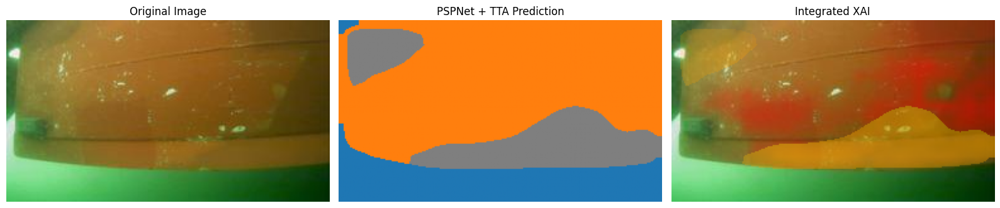

In [34]:
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(prediction_np, cmap="tab10", vmin=0, vmax=10)
plt.title("PSPNet + TTA Prediction")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(integrated_xai)
plt.title("Integrated XAI")
plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
import gradio as gr

with gr.Blocks(title="Underwater Ship Hull Inspection") as demo:

    gr.Markdown(
        """
        # 🚢 Underwater Ship Hull Inspection
        ### Semantic Segmentation & AI-Assisted Inspection
        """
    )

    gr.Markdown(
        "Upload an underwater ship-hull image or select an image from the LIACi dataset."
    )

    with gr.Row():

        with gr.Column():
            image_input = gr.Image(
                type="pil",
                label="Input Image"
            )

            predict_button = gr.Button(
                "🔍 Analyze Image",
                variant="primary"
            )

        with gr.Column():
            segmentation_output = gr.Image(
                type="numpy",
                label="Segmentation Result",
                interactive=False
            )

            xai_output = gr.Image(
                type="numpy",
                label="XAI / Grad-CAM",
                interactive=False
            )

    gr.Markdown("## 📋 Inspection Report")

    report_output = gr.Markdown(
        "The inspection report will appear here after analysis."
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bbfb5820ccd69d0e60.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [47]:
import torch
import torch.nn.functional as F
import numpy as np

class PSPNetGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, target_class_idx, prediction_mask):
        self.model.eval()
        self.model.zero_grad()

        main_output, _ = self.model(input_tensor)

        class_mask = (prediction_mask == target_class_idx).float()

        class_mask = class_mask.unsqueeze(0).unsqueeze(0)

        class_mask = F.interpolate(
            class_mask,
            size=main_output.shape[2:],
            mode="nearest"
        )

        target_score = (
            main_output[0, target_class_idx]
            .unsqueeze(0)
            .unsqueeze(0)
            * class_mask
        ).sum()

        target_score.backward()

        weights = torch.mean(
            self.gradients,
            dim=(2, 3),
            keepdim=True
        )

        cam = torch.sum(
            weights * self.activations,
            dim=1,
            keepdim=True
        )

        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=input_tensor.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().detach().cpu().numpy()

        cam_min = cam.min()
        cam_max = cam.max()

        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = np.zeros_like(cam)

        return cam


grad_cam = PSPNetGradCAM(
    model_pspnet,
    target_layer=model_pspnet.psp.conv
)

print("Original Grad-CAM restored!")

Original Grad-CAM restored!


In [48]:
import gradio as gr
import numpy as np
import torch

def analyze_image(image):
    if image is None:
        return None, None, "Please upload an image."

    image = image.convert("RGB")
    image_resized = image.resize((512, 512))
    image_np = np.array(image_resized)

    img_tensor = torch.tensor(
        image_np,
        dtype=torch.float32
    ).permute(2, 0, 1) / 255.0

    img_tensor = img_tensor.unsqueeze(0).to(device)

    # PSPNet prediction
    with torch.no_grad():
        output, _ = model_pspnet(img_tensor)
        prediction = torch.argmax(output, dim=1)[0]

    prediction_np = prediction.cpu().numpy()

    # Class colors
    class_colors = {
        0: (0, 0, 0),
        1: (0, 0, 255),
        2: (0, 128, 0),
        3: (0, 255, 255),
        4: (64, 224, 208),
        5: (128, 0, 128),
        6: (255, 0, 0),
        7: (255, 165, 0),
        8: (255, 192, 203),
        9: (255, 255, 0),
        10: (255, 255, 255)
    }

    # Create segmentation image
    segmentation = np.zeros(
        (512, 512, 3),
        dtype=np.uint8
    )

    for class_id, color in class_colors.items():
        segmentation[prediction_np == class_id] = color

    # Find predicted classes
    predicted_classes = np.unique(prediction_np)

    predicted_classes = [
        int(class_id)
        for class_id in predicted_classes
        if class_id != 0
    ]

    print(
        "Predicted classes:",
        [class_names[class_id] for class_id in predicted_classes]
    )

    # XAI image
    xai_image = image_np.copy().astype(np.float32)

    for class_id in predicted_classes:

        heatmap = grad_cam.generate_heatmap(
            img_tensor,
            target_class_idx=class_id,
            prediction_mask=prediction
        )

        class_mask = prediction_np == class_id

        heatmap = heatmap * class_mask

        if heatmap.max() > 0:
            heatmap = heatmap / heatmap.max()

        color = np.array(
            class_colors[class_id],
            dtype=np.float32
        )

        alpha = 0.65 * heatmap[..., None]

        xai_image = (
            xai_image * (1 - alpha)
            + color * alpha
        )

    xai_image = np.clip(
        xai_image,
        0,
        255
    ).astype(np.uint8)

    # Gemini VLM
    prompt = """
You are an AI assistant for underwater ship hull inspection.

Analyze the provided underwater ship image carefully.

Identify:
1. The visible ship hull region.
2. Visible ship components such as anodes, propellers,
   bilge keels, valves or sea chest gratings.
3. Visible surface conditions such as marine growth,
   paint peeling, corrosion or other defects.
4. Any clearly visible inspection concerns.

Give a concise inspection-oriented report.

Important:
- Describe only what is visually supported by the image.
- If something is unclear or not visible, say so.
- Do not invent defects.
"""

    try:
        response = client.models.generate_content(
            model="gemini-3.5-flash-lite",
            contents=[prompt, image]
        )

        report = response.text

    except Exception as e:
        report = f"Gemini VLM error: {str(e)}"

    return segmentation, xai_image, report


with gr.Blocks(
    title="Underwater Ship Hull Inspection"
) as demo:

    gr.Markdown(
        """
        # 🚢 Underwater Ship Hull Inspection
        ### Semantic Segmentation & AI-Assisted Inspection
        """
    )

    gr.Markdown(
        "Upload an underwater ship-hull image or select an image from the LIACi dataset."
    )

    with gr.Row():

        with gr.Column():

            image_input = gr.Image(
                type="pil",
                label="Input Image"
            )

            predict_button = gr.Button(
                "🔍 Analyze Image",
                variant="primary"
            )

        with gr.Column():

            segmentation_output = gr.Image(
                type="numpy",
                label="Segmentation Result",
                interactive=False
            )

            xai_output = gr.Image(
                type="numpy",
                label="XAI / Grad-CAM",
                interactive=False
            )

    gr.Markdown("## 📋 Inspection Report")

    report_output = gr.Markdown(
        "The inspection report will appear here after analysis."
    )

    predict_button.click(
        fn=analyze_image,
        inputs=image_input,
        outputs=[
            segmentation_output,
            xai_output,
            report_output
        ]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1a3d1f12af07d6d2ff.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [49]:
import torch
import torch.nn.functional as F
import numpy as np


class MultiClassLayerCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.target_layer.register_forward_hook(
            self.save_activation
        )

        self.target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(
        self,
        input_tensor,
        target_class_idx,
        prediction_mask
    ):

        self.model.eval()
        self.model.zero_grad()

        # PSPNet returns main output + auxiliary output
        main_output, _ = self.model(input_tensor)

        # Pixels predicted as this class
        class_mask = (
            prediction_mask == target_class_idx
        ).float()

        class_mask = class_mask.unsqueeze(0).unsqueeze(0)

        # Match output resolution
        class_mask = F.interpolate(
            class_mask,
            size=main_output.shape[2:],
            mode="nearest"
        )

        # Only explain pixels belonging to this class
        target_score = (
            main_output[
                0,
                target_class_idx
            ].unsqueeze(0).unsqueeze(0)
            * class_mask
        ).sum()

        target_score.backward()

        # Layer-CAM
        positive_gradients = F.relu(
            self.gradients
        )

        weighted_activations = (
            positive_gradients *
            self.activations
        )

        cam = torch.sum(
            weighted_activations,
            dim=1,
            keepdim=True
        )

        cam = F.relu(cam)

        # Resize CAM to input image size
        cam = F.interpolate(
            cam,
            size=input_tensor.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().detach().cpu().numpy()

        # Normalize
        cam_min = cam.min()
        cam_max = cam.max()

        if cam_max - cam_min > 1e-8:
            cam = (
                cam - cam_min
            ) / (
                cam_max - cam_min
            )
        else:
            cam = np.zeros_like(cam)

        return cam


# Use PSPNet Pyramid Pooling output
layer_cam = MultiClassLayerCAM(
    model_pspnet,
    target_layer=model_pspnet.psp.conv
)

print("Multi-Class Layer-CAM ready!")

Multi-Class Layer-CAM ready!


Predicted classes:
- Ship Hull
- Anode
- Overboard Valve
- Propeller
- Paint Peel
- Bilge Keel


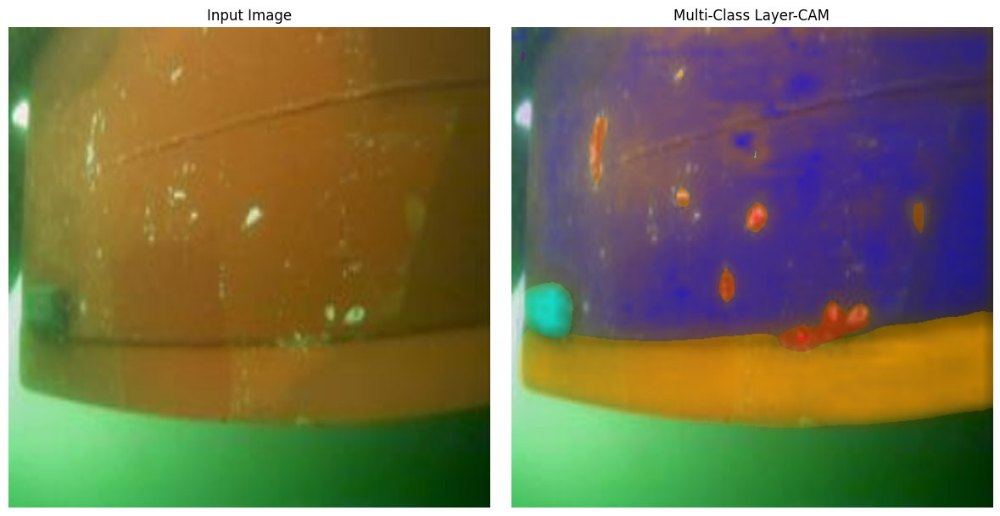

In [50]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

image_path = "/content/drive/MyDrive/LIACI FINAL/PEP_SEG_DATA/LIACi_dataset_pretty/image_thumbs/image_0001.jpg"

# Load image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize for PSPNet
image_resized = cv2.resize(image, (512, 512))

# Convert to tensor
img_tensor = (
    torch.from_numpy(image_resized)
    .permute(2, 0, 1)
    .float()
    / 255.0
)

img_tensor = img_tensor.unsqueeze(0).to(device)

# Get PSPNet prediction
with torch.no_grad():
    output, _ = model_pspnet(img_tensor)
    prediction = torch.argmax(output, dim=1)[0]

prediction_np = prediction.cpu().numpy()

# Find every predicted class except background
predicted_classes = np.unique(prediction_np)
predicted_classes = [
    int(c) for c in predicted_classes
    if c != 0
]

print("Predicted classes:")
for class_id in predicted_classes:
    print("-", class_names[class_id])

# Original image for overlay
xai_image = image_resized.copy().astype(np.float32)

# Generate Layer-CAM for every predicted class
for class_id in predicted_classes:

    heatmap = layer_cam.generate_heatmap(
        img_tensor,
        target_class_idx=class_id,
        prediction_mask=prediction
    )

    class_mask = prediction_np == class_id

    # Keep CAM only inside this predicted class
    heatmap = heatmap * class_mask

    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    # Use the original class color
    color = np.array(
        {
            1: (0, 0, 255),        # Ship Hull
            2: (0, 128, 0),        # Marine Growth
            3: (0, 255, 255),      # Anode
            4: (64, 224, 208),     # Overboard Valve
            5: (128, 0, 128),      # Propeller
            6: (255, 0, 0),        # Paint Peel
            7: (255, 165, 0),      # Bilge Keel
            8: (255, 192, 203),    # Defect
            9: (255, 255, 0),      # Corrosion
            10: (255, 255, 255)    # Sea Chest Grating
        }[class_id],
        dtype=np.float32
    )

    alpha = 0.7 * heatmap[..., None]

    xai_image = (
        xai_image * (1 - alpha)
        + color * alpha
    )

xai_image = np.clip(
    xai_image,
    0,
    255
).astype(np.uint8)

# Display
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_resized)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(xai_image)
plt.title("Multi-Class Layer-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()

In [51]:
import gradio as gr
import numpy as np
import torch
import cv2


# ============================================================
# CLASS COLORS
# ============================================================

class_colors = {
    0: (0, 0, 0),          # Void
    1: (0, 0, 255),        # Ship Hull
    2: (0, 128, 0),        # Marine Growth
    3: (0, 255, 255),      # Anode
    4: (64, 224, 208),     # Overboard Valve
    5: (128, 0, 128),      # Propeller
    6: (255, 0, 0),        # Paint Peel
    7: (255, 165, 0),      # Bilge Keel
    8: (255, 192, 203),    # Defect
    9: (255, 255, 0),      # Corrosion
    10: (255, 255, 255)    # Sea Chest Grating
}


# ============================================================
# MULTI-CLASS LAYER-CAM
# ============================================================

class MultiClassLayerCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.target_layer.register_forward_hook(
            self.save_activation
        )

        self.target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(self, module, input, output):

        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):

        self.gradients = grad_output[0]

    def generate_heatmap(
        self,
        input_tensor,
        target_class_idx,
        prediction_mask
    ):

        self.model.eval()
        self.model.zero_grad()

        # PSPNet returns:
        # main output, auxiliary output

        main_output, _ = self.model(input_tensor)

        # Select pixels predicted as this class

        class_mask = (
            prediction_mask == target_class_idx
        ).float()

        class_mask = (
            class_mask
            .unsqueeze(0)
            .unsqueeze(0)
        )

        # Resize mask to model output size

        class_mask = F.interpolate(
            class_mask,
            size=main_output.shape[2:],
            mode="nearest"
        )

        # Target score only for this class

        target_score = (
            main_output[
                0,
                target_class_idx
            ]
            .unsqueeze(0)
            .unsqueeze(0)
            * class_mask
        ).sum()

        target_score.backward()

        # Layer-CAM

        positive_gradients = F.relu(
            self.gradients
        )

        weighted_activations = (
            positive_gradients *
            self.activations
        )

        cam = torch.sum(
            weighted_activations,
            dim=1,
            keepdim=True
        )

        cam = F.relu(cam)

        # Resize to input image

        cam = F.interpolate(
            cam,
            size=input_tensor.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        cam = (
            cam
            .squeeze()
            .detach()
            .cpu()
            .numpy()
        )

        # Normalize

        cam_min = cam.min()
        cam_max = cam.max()

        if cam_max - cam_min > 1e-8:

            cam = (
                cam - cam_min
            ) / (
                cam_max - cam_min
            )

        else:

            cam = np.zeros_like(cam)

        return cam


# Create Layer-CAM object

layer_cam = MultiClassLayerCAM(
    model_pspnet,
    target_layer=model_pspnet.psp.conv
)


# ============================================================
# MAIN ANALYSIS FUNCTION
# ============================================================

def analyze_image(image):

    if image is None:

        return (
            None,
            None,
            "Please upload an image."
        )


    # --------------------------------------------------------
    # Prepare image
    # --------------------------------------------------------

    image = image.convert("RGB")

    image_resized = image.resize(
        (512, 512)
    )

    image_np = np.array(
        image_resized
    )


    # --------------------------------------------------------
    # Convert to tensor
    # --------------------------------------------------------

    img_tensor = torch.tensor(
        image_np,
        dtype=torch.float32
    ).permute(2, 0, 1) / 255.0

    img_tensor = (
        img_tensor
        .unsqueeze(0)
        .to(device)
    )


    # --------------------------------------------------------
    # PSPNet prediction
    # --------------------------------------------------------

    with torch.no_grad():

        output, _ = model_pspnet(
            img_tensor
        )

        prediction = torch.argmax(
            output,
            dim=1
        )[0]


    prediction_np = (
        prediction
        .cpu()
        .numpy()
    )


    # ========================================================
    # SEGMENTATION OUTPUT
    # ========================================================

    segmentation = np.zeros(
        (512, 512, 3),
        dtype=np.uint8
    )

    for class_id, color in class_colors.items():

        segmentation[
            prediction_np == class_id
        ] = color


    # Find all predicted classes

    predicted_classes = np.unique(
        prediction_np
    )

    predicted_classes = [
        int(class_id)
        for class_id in predicted_classes
        if class_id != 0
    ]


    print(
        "Predicted classes:",
        [
            class_names[class_id]
            for class_id in predicted_classes
        ]
    )


    # ========================================================
    # MULTI-CLASS LAYER-CAM XAI
    # ========================================================

    xai_image = (
        image_np
        .copy()
        .astype(np.float32)
    )


    for class_id in predicted_classes:

        # Generate class-specific Layer-CAM

        heatmap = layer_cam.generate_heatmap(
            img_tensor,
            target_class_idx=class_id,
            prediction_mask=prediction
        )


        # Keep explanation only inside
        # the predicted class region

        class_mask = (
            prediction_np == class_id
        )

        heatmap = (
            heatmap *
            class_mask
        )


        # Normalize class heatmap

        if heatmap.max() > 0:

            heatmap = (
                heatmap /
                heatmap.max()
            )


        # Class color

        color = np.array(
            class_colors[class_id],
            dtype=np.float32
        )


        # Overlay

        alpha = (
            0.7 *
            heatmap[..., None]
        )

        xai_image = (
            xai_image *
            (1 - alpha)
            +
            color *
            alpha
        )


    xai_image = np.clip(
        xai_image,
        0,
        255
    ).astype(np.uint8)


    # ========================================================
    # GEMINI VLM INSPECTION REPORT
    # ========================================================

    prompt = """
You are an AI assistant for underwater ship hull inspection.

Analyze the provided underwater ship image carefully.

Identify:

1. The visible ship hull region.
2. Visible ship components such as anodes, propellers,
   bilge keels, valves or sea chest gratings.
3. Visible surface conditions such as marine growth,
   paint peeling, corrosion or other defects.
4. Any clearly visible inspection concerns.

Give a concise inspection-oriented report.

Important:
- Describe only what is visually supported by the image.
- If something is unclear or not visible, say so.
- Do not invent defects.
- Do not assume that a possible defect is present unless
  it is visually supported by the image.
"""


    try:

        response = client.models.generate_content(
            model="gemini-3.5-flash-lite",
            contents=[
                prompt,
                image
            ]
        )

        report = response.text


    except Exception as e:

        report = (
            f"Gemini VLM error: {str(e)}"
        )


    # ========================================================
    # RETURN RESULTS
    # ========================================================

    return (
        segmentation,
        xai_image,
        report
    )


# ============================================================
# GRADIO UI
# ============================================================

with gr.Blocks(
    title="Underwater Ship Hull Inspection"
) as demo:

    gr.Markdown(
        """
        # 🚢 Underwater Ship Hull Inspection
        ### Semantic Segmentation & AI-Assisted Inspection
        """
    )

    gr.Markdown(
        """
        Upload an underwater ship-hull image to obtain
        segmentation, explainable AI visualization,
        and an AI-assisted inspection report.
        """
    )


    with gr.Row():

        # ----------------------------------------------------
        # INPUT
        # ----------------------------------------------------

        with gr.Column():

            image_input = gr.Image(
                type="pil",
                label="Input Image"
            )

            predict_button = gr.Button(
                "🔍 Analyze Image",
                variant="primary"
            )


        # ----------------------------------------------------
        # OUTPUTS
        # ----------------------------------------------------

        with gr.Column():

            segmentation_output = gr.Image(
                type="numpy",
                label="Segmentation Result",
                interactive=False
            )

            xai_output = gr.Image(
                type="numpy",
                label="XAI - Multi-Class Layer-CAM",
                interactive=False
            )


    # --------------------------------------------------------
    # INSPECTION REPORT
    # --------------------------------------------------------

    gr.Markdown(
        "## 📋 AI-Assisted Inspection Report"
    )

    report_output = gr.Markdown(
        "The inspection report will appear here after analysis."
    )


    # --------------------------------------------------------
    # BUTTON ACTION
    # --------------------------------------------------------

    predict_button.click(
        fn=analyze_image,
        inputs=image_input,
        outputs=[
            segmentation_output,
            xai_output,
            report_output
        ]
    )


# ============================================================
# LAUNCH
# ============================================================

demo.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://602fd9e54e9df0ce17.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
